In [35]:
import scanpy as sc


In [36]:
import scanpy as sc

# Load your .h5ad dataset
adata = sc.read("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase.h5ad")

# Display the basic information about the dataset
print(adata)

# Show the shape of the dataset (number of cells and genes)
print(f"Shape of the dataset: {adata.shape}")

# Check the names of available attributes in the data (e.g., raw data, metadata)
print("Available data attributes:")
print(adata.obs)  # Cell metadata
print(adata.var)  # Gene metadata
print(adata.X)    # Expression matrix

# Optionally, show the first few rows of cell metadata
print("First few rows of cell metadata:")
print(adata.obs.head())

AnnData object with n_obs × n_vars = 1038163 × 978
    obs: 'dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit'
Shape of the dataset: (1038163, 978)
Available data attributes:
                             dataset_name  \
cid                                         
REP.A001_A375_24H_X1_B22:A03     GSE70138   
REP.A001_A375_24H_X1_B22:A04     GSE70138   
REP.A001_A375_24H_X1_B22:A05     GSE70138   
REP.A001_A375_24H_X1_B22:A06     GSE70138   
REP.A001_A375_24H_X1_B22:A07     GSE70138   
...                                   ...   
PCLB003_PC3_24H_X3_B13:P20       GSE92742   
PCLB003_PC3_24H_X3_B13:P21       GSE92742   
PCLB003_PC3_24H_X3_B13:P22       GSE92742   
PCLB003_PC3_24H_X3_B13:P23       GSE92742   
PCLB003_PC3_24H_X3_B13:P24       GSE92742   

                                                                   sig_id  \
cid                            

In [37]:
# Extract unique values for cell_id, pert_dose, and pert_dose_unit
unique_cell_ids = adata.obs['cell_id'].unique()
unique_pert_doses = adata.obs['pert_dose'].unique()
unique_pert_dose_units = adata.obs['pert_dose_unit'].unique()

# Display the unique values
print("Unique cell IDs:", unique_cell_ids)
print("Unique pert_dose values:", unique_pert_doses)
print("Unique pert_dose_unit values:", unique_pert_dose_units)

Unique cell IDs: ['A375', 'HA1E', 'HELA', 'HT29', 'MCF7', ..., 'H1299', 'HEK293T', 'HL60', 'RKO', 'U266']
Length: 82
Categories (82, object): ['A375', 'A549', 'A673', 'AGS', ..., 'U937', 'VCAP', 'WSUDLCL2', 'YAPC']
Unique pert_dose values: [-6.660e+02  1.000e+01  3.330e+00  1.110e+00  3.700e-01  1.200e-01
  4.000e-02  2.000e+01  2.000e+00  6.700e-01  2.200e-01  7.000e-02
  2.000e-02  1.000e-02  1.005e+01  3.350e+00  1.120e+00  1.120e+01
  3.730e+00  1.240e+00  4.100e-01  1.400e-01  5.000e-02  9.580e+00
  3.190e+00  1.060e+00  3.500e-01  1.155e+01  3.850e+00  1.280e+00
  4.300e-01  1.007e+01  3.360e+00  1.000e+00  3.300e-01  1.100e-01
  6.790e+00  2.260e+00  7.500e-01  8.000e-02  3.000e-02  2.500e-01
  1.072e+01  3.570e+00  1.190e+00  4.000e-01  1.300e-01  4.520e+00
  1.510e+00  5.000e-01  1.700e-01  6.000e-02  4.800e+00  1.600e+00
  5.300e-01  1.800e-01  4.170e+00  1.390e+00  4.600e-01  1.500e-01
  8.110e+00  2.700e+00  9.000e-01  3.000e-01  1.000e-01  5.770e+00
  1.920e+00  6.400e-01 

In [38]:
# Count the number of unique values in each of the specified columns
num_unique_cell_ids = adata.obs['cell_id'].nunique()
num_unique_pert_doses = adata.obs['pert_dose'].nunique()
num_unique_pert_dose_units = adata.obs['pert_dose_unit'].nunique()

# Display the number of unique values
print(f"Number of unique cell_ids: {num_unique_cell_ids}")
print(f"Number of unique pert_dose values: {num_unique_pert_doses}")
print(f"Number of unique pert_dose_unit values: {num_unique_pert_dose_units}")

Number of unique cell_ids: 82
Number of unique pert_dose values: 95
Number of unique pert_dose_unit values: 3


In [39]:
import scanpy as sc

# Assuming your AnnData object is called 'adata'
# Check the unique values in pert_type
print(adata.obs['pert_type'].unique())

# Count the number of cells for each value
pert_counts = adata.obs['pert_type'].value_counts()
print(pert_counts)

# Specifically check for 'trt_cp' and 'ctrl_vehicle'
trt_cp_count = (adata.obs['pert_type'] == 'trt_cp').sum()
ctrl_vehicle_count = (adata.obs['pert_type'] == 'ctrl_vehicle').sum()

print(f"Number of trt_cp cells: {trt_cp_count}")
print(f"Number of ctrl_vehicle cells: {ctrl_vehicle_count}")

['ctl_vehicle', 'trt_cp']
Categories (2, object): ['ctl_vehicle', 'trt_cp']
pert_type
trt_cp         964902
ctl_vehicle     73261
Name: count, dtype: int64
Number of trt_cp cells: 964902
Number of ctrl_vehicle cells: 0


In [40]:
# Count the number of unique values for pert_iname and pert_id
num_unique_pert_iname = adata.obs['pert_iname'].nunique()
num_unique_pert_id = adata.obs['pert_id'].nunique()

# Display the number of unique values
print(f"Number of unique pert_iname values: {num_unique_pert_iname}")
print(f"Number of unique pert_id values: {num_unique_pert_id}")

Number of unique pert_iname values: 17936
Number of unique pert_id values: 18660


In [41]:
import sqlite3

In [42]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db")

moa_df = pd.read_sql_query("""
SELECT
    molecule_dictionary.chembl_id,
    molecule_dictionary.pref_name,
    drug_mechanism.mechanism_of_action,
    drug_mechanism.action_type
FROM drug_mechanism
JOIN molecule_dictionary
ON drug_mechanism.molregno = molecule_dictionary.molregno
""", conn)

print(moa_df.head())
# Display the columns of the ChEMBL MoA dataset
print("Columns in ChEMBL MoA dataset:")
print(moa_df.columns)

# Display the first few rows of the ChEMBL MoA dataset (head)
print("\nFirst few rows (Head) of ChEMBL MoA dataset:")
print(moa_df.head())

# Display the last few rows of the ChEMBL MoA dataset (tail)
print("\nLast few rows (Tail) of ChEMBL MoA dataset:")
print(moa_df.tail())

       chembl_id             pref_name               mechanism_of_action  \
0       CHEMBL19         METHAZOLAMIDE  Carbonic anhydrase VII inhibitor   
1  CHEMBL1201117         METHOCARBAMOL    Carbonic anhydrase I inhibitor   
2  CHEMBL1200814  ACETAZOLAMIDE SODIUM    Carbonic anhydrase I inhibitor   
3       CHEMBL17      DICHLORPHENAMIDE    Carbonic anhydrase I inhibitor   
4       CHEMBL20         ACETAZOLAMIDE    Carbonic anhydrase I inhibitor   

  action_type  
0   INHIBITOR  
1   INHIBITOR  
2   INHIBITOR  
3   INHIBITOR  
4   INHIBITOR  


Columns in ChEMBL MoA dataset:
Index(['chembl_id', 'pref_name', 'mechanism_of_action', 'action_type'], dtype='object')

First few rows (Head) of ChEMBL MoA dataset:
       chembl_id             pref_name               mechanism_of_action  \
0       CHEMBL19         METHAZOLAMIDE  Carbonic anhydrase VII inhibitor   
1  CHEMBL1201117         METHOCARBAMOL    Carbonic anhydrase I inhibitor   
2  CHEMBL1200814  ACETAZOLAMIDE SODIUM    Carbonic anhydrase I inhibitor   
3       CHEMBL17      DICHLORPHENAMIDE    Carbonic anhydrase I inhibitor   
4       CHEMBL20         ACETAZOLAMIDE    Carbonic anhydrase I inhibitor   

  action_type  
0   INHIBITOR  
1   INHIBITOR  
2   INHIBITOR  
3   INHIBITOR  
4   INHIBITOR  

Last few rows (Tail) of ChEMBL MoA dataset:
          chembl_id            pref_name  \
7563    CHEMBL43048       MIDOMAFETAMINE   
7564       CHEMBL81           RALOXIFENE   
7565  CHEMBL2108151  NACOLOMAB TAFENATOX   
7566  CHEMBL5095049   PACRITINIB CITRATE   
7567  CHEMBL5095

In [43]:
# Lowercase and strip spaces for matching
moa_df['drug_clean'] = moa_df['pref_name'].str.lower().str.strip()
adata.obs['drug_clean'] = adata.obs['pert_iname'].str.lower().str.strip()

# Check unique drugs
print("Unique drugs in LINCS:", len(adata.obs['drug_clean'].unique()))
print("Unique drugs in ChEMBL MoA:", len(moa_df['drug_clean'].unique()))

Unique drugs in LINCS: 17936
Unique drugs in ChEMBL MoA: 5961


In [44]:
# LINCS cleaned drug names
lincs_drugs = set(adata.obs['drug_clean'].unique())

# ChEMBL cleaned drug names
chembl_drugs = set(moa_df['drug_clean'].unique())

In [45]:
# Drugs in LINCS that exist in ChEMBL
matched_drugs = lincs_drugs & chembl_drugs
print("Number of matching drugs:", len(matched_drugs))

# Drugs in LINCS missing in ChEMBL
missing_in_chembl = lincs_drugs - chembl_drugs
print("Number of drugs in LINCS missing in ChEMBL:", len(missing_in_chembl))

# Sample of missing drugs
print("Some LINCS drugs not found in ChEMBL:")
print(list(missing_in_chembl)[:20])

Number of matching drugs: 969
Number of drugs in LINCS missing in ChEMBL: 16967
Some LINCS drugs not found in ChEMBL:
['brd-k85438393', 'brd-k65258912', 'brd-k54285697', 'brd-k78518750', 'brd-k16778485', 'nvp-tae226', 'brd-k15525634', 'brd-k29514489', 'pinocembrin', 'givinostat', 'ioxaglic-acid', 'brd-k60004464', 'brd-k69498175', 'brd-k19331234', 'triptolide', 'brd-k57309821', 'brd-k43225681', 'brd-k61657561', 'brd-k08105592', 'brd-k09300252']


In [46]:
import sqlite3
import pandas as pd

# Connect to ChEMBL SQLite
conn = sqlite3.connect("/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db")

# Load ChEMBL structures
chembl_structures = pd.read_sql_query("""
SELECT
    molregno,
    canonical_smiles,
    standard_inchi_key
FROM molecule_structures
""", conn)

print("Number of structures in ChEMBL:", len(chembl_structures))
print(chembl_structures.head())

DatabaseError: Execution failed on sql '
SELECT
    molregno,
    canonical_smiles,
    standard_inchi_key
FROM molecule_structures
': no such table: molecule_structures

In [ ]:
import sqlite3
import pandas as pd

# Connect to ChEMBL SQLite
conn = sqlite3.connect("/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db")

# Load ChEMBL canonical names with MoA
chembl_moa = pd.read_sql_query("""
SELECT
    dm.molregno,
    md.pref_name,
    dm.mechanism_of_action,
    dm.action_type
FROM drug_mechanism dm
JOIN molecule_dictionary md
ON dm.molregno = md.molregno
""", conn)

# Clean names
chembl_moa['drug_clean'] = chembl_moa['pref_name'].str.lower().str.strip()
chembl_moa = chembl_moa[['drug_clean', 'mechanism_of_action', 'action_type', 'molregno']]

print("ChEMBL MoA dataset preview:")
print(chembl_moa.head())

ChEMBL MoA dataset preview:
             drug_clean               mechanism_of_action action_type  \
0         methazolamide  Carbonic anhydrase VII inhibitor   INHIBITOR   
1         methocarbamol    Carbonic anhydrase I inhibitor   INHIBITOR   
2  acetazolamide sodium    Carbonic anhydrase I inhibitor   INHIBITOR   
3      dichlorphenamide    Carbonic anhydrase I inhibitor   INHIBITOR   
4         acetazolamide    Carbonic anhydrase I inhibitor   INHIBITOR   

   molregno  
0      1124  
1    675068  
2    674765  
3      1085  
4      1125  


In [ ]:
# LINCS cleaned drug names
lincs_drugs = set(adata.obs['drug_clean'].unique())

# ChEMBL cleaned drug names
chembl_drugs = set(chembl_moa['drug_clean'].unique())

In [ ]:
# Drugs that exist in both LINCS and ChEMBL
matched_drugs = lincs_drugs & chembl_drugs
print("Number of unique LINCS drugs that match ChEMBL:", len(matched_drugs))

# Drugs in LINCS not found in ChEMBL
missing_in_chembl = lincs_drugs - chembl_drugs
print("Number of unique  LINCS drugs missing in ChEMBL:", len(missing_in_chembl))

# Sample missing drugs
print("Some LINCS drugs not found in ChEMBL:")
print(list(missing_in_chembl)[:20])

Number of unique LINCS drugs that match ChEMBL: 969
Number of unique  LINCS drugs missing in ChEMBL: 16967
Some LINCS drugs not found in ChEMBL:
['brd-k71859938', 'sa-1457945', 'brd-k57552506', 'brd-a52933579', 'brd-k07967886', 'brd-k81441552', 'brd-k21600166', 'mgcd-265', 'brd-k59755197', 'brd-k88597074', 'brd-k83426111', 'nicotinyl-alcohol-tartrate', 'bupropion', 'brd-k67786373', 'brd-k28096758', 'citiolone', 'brd-k73722380', 'procarbazine', 'brd-k80932888', 'brd-k19593593']


In [ ]:
moa_df = moa_df[["pref_name", "action_type"]]

In [ ]:
moa_df = moa_df.rename(columns={"action_type": "MoA"})

In [ ]:
moa_df["pref_name"] = moa_df["pref_name"].str.lower().str.strip()
adata.obs["pert_iname"] = adata.obs["pert_iname"].str.lower().str.strip()

In [ ]:
# Find the common drug names between both datasets
common_drugs = adata.obs["pert_iname"].isin(moa_df["pref_name"])

print(f"Number of matching drugs: {common_drugs.sum()}")

Number of matching drugs: 208183


In [ ]:
# Check if the drug names match
matching = adata.obs["pert_iname"].isin(moa_df["pref_name"])

# Correct mismatch calculation (number of unmatched rows)
unmatched_count = len(adata.obs) - matching.sum()

print(f"Number of matched drug names: {matching.sum()}")
print(f"Number of unmatched drug names: {unmatched_count}")

Number of matched drug names: 208183
Number of unmatched drug names: 829980


In [ ]:
# Check the first few rows and columns of the `adata.obs` (your dataset)
print(adata.obs[["pert_iname"]].head())

# Check the first few rows of `moa_df` (ChEMBL dataset)
print(moa_df[["pref_name", "MoA"]].head())

                                  pert_iname
cid                                         
REP.A001_A375_24H_X1_B22:A03            dmso
REP.A001_A375_24H_X1_B22:A04            dmso
REP.A001_A375_24H_X1_B22:A05            dmso
REP.A001_A375_24H_X1_B22:A06            dmso
REP.A001_A375_24H_X1_B22:A07  aminoguanidine
              pref_name        MoA
0         methazolamide  INHIBITOR
1         methocarbamol  INHIBITOR
2  acetazolamide sodium  INHIBITOR
3      dichlorphenamide  INHIBITOR
4         acetazolamide  INHIBITOR


In [ ]:
# Check if the drugs from trt_cp match those in ChEMBL
matching_trt_cp = trt_cp_adata["pert_iname"].isin(moa_df["pref_name"])

# Display the number of matched and unmatched treatment drugs
print(f"Number of matched drugs in trt_cp: {matching_trt_cp.sum()}")
print(f"Number of unmatched drugs in trt_cp: {len(matching_trt_cp) - matching_trt_cp.sum()}")

Number of matched drugs in trt_cp: 208183
Number of unmatched drugs in trt_cp: 756719


In [ ]:
# Find the matched drugs in 'trt_cp'
matched_trt_cp = trt_cp_adata[matching_trt_cp]

# Get unique matched drug names
unique_matched_drugs = matched_trt_cp["pert_iname"].unique()

# Count the number of unique matched drugs
num_unique_matched = len(unique_matched_drugs)

# Print the results
print(f"Number of unique matched drugs: {num_unique_matched}")
print(f"Number of unique unmatched drugs: {num_unique_unmatched}")

Number of unique matched drugs: 969
Number of unique unmatched drugs: 16966


In [ ]:
print(moa_df.columns.tolist())

['pref_name', 'MoA']


In [ ]:
# Keep only the columns we need
moa_df = moa_df[["pref_name", "MoA"]]
moa_df = moa_df.rename(columns={"action_type": "MoA"})

# Normalize drug names for matching
moa_df["pref_name"] = moa_df["pref_name"].str.lower().str.strip()
adata.obs["pert_iname"] = adata.obs["pert_iname"].str.lower().str.strip()

In [ ]:
# Create a dictionary for MoA lookup
moa_dict = dict(zip(moa_df["pref_name"], moa_df["MoA"]))

# Function to assign MoA
def assign_moa(row):
    if row["pert_type"] == "ctrl_vehicle":
        return "control"  # mark all controls as "control"
    elif row["pert_iname"] in moa_dict:
        return moa_dict[row["pert_iname"]]  # matched MoA
    else:
        return "unclear"  # unmatched treatment

# Apply function
adata.obs["MoA"] = adata.obs.apply(assign_moa, axis=1)

In [ ]:
# Count how many of each category
print(adata.obs["MoA"].value_counts().head(20))

# Check a few controls
print(adata.obs[adata.obs["pert_type"]=="ctl_vehicle"].head())

MoA
unclear                          829980
INHIBITOR                        137491
AGONIST                           22358
ANTAGONIST                        20639
BLOCKER                            8691
MODULATOR                          2831
POSITIVE ALLOSTERIC MODULATOR      2100
OPENER                             1336
DEGRADER                           1320
PARTIAL AGONIST                     756
ACTIVATOR                           630
POSITIVE MODULATOR                  497
INVERSE AGONIST                     355
CHELATING AGENT                     324
STABILISER                          246
ALLOSTERIC ANTAGONIST               220
RELEASING AGENT                     207
DISRUPTING AGENT                    187
NEGATIVE MODULATOR                  126
NEGATIVE ALLOSTERIC MODULATOR       125
Name: count, dtype: int64
                             dataset_name                 sig_id pert_id  \
cid                                                                        
REP.A001_A375_24H_

In [ ]:
import sqlite3
import pandas as pd

# Connect to ChEMBL SQLite database
conn = sqlite3.connect("/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db")

# Query the MoA information
moa_df = pd.read_sql_query("""
SELECT
    molecule_dictionary.chembl_id,
    molecule_dictionary.pref_name,
    drug_mechanism.mechanism_of_action,
    drug_mechanism.action_type
FROM drug_mechanism
JOIN molecule_dictionary
ON drug_mechanism.molregno = molecule_dictionary.molregno
""", conn)

# Inspect the columns and first few rows
print("Columns in ChEMBL MoA dataset:")
print(moa_df.columns)
print("\nFirst 5 rows:")
print(moa_df.head())

Columns in ChEMBL MoA dataset:
Index(['chembl_id', 'pref_name', 'mechanism_of_action', 'action_type'], dtype='object')

First 5 rows:
       chembl_id             pref_name               mechanism_of_action  \
0       CHEMBL19         METHAZOLAMIDE  Carbonic anhydrase VII inhibitor   
1  CHEMBL1201117         METHOCARBAMOL    Carbonic anhydrase I inhibitor   
2  CHEMBL1200814  ACETAZOLAMIDE SODIUM    Carbonic anhydrase I inhibitor   
3       CHEMBL17      DICHLORPHENAMIDE    Carbonic anhydrase I inhibitor   
4       CHEMBL20         ACETAZOLAMIDE    Carbonic anhydrase I inhibitor   

  action_type  
0   INHIBITOR  
1   INHIBITOR  
2   INHIBITOR  
3   INHIBITOR  
4   INHIBITOR  


In [ ]:
import scanpy as sc

# Load .h5ad file
adata = sc.read("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase.h5ad")

# Inspect basic info
print(adata)
print(f"Shape of dataset: {adata.shape}")
print("First few rows of cell metadata:")
print(adata.obs.head())

AnnData object with n_obs × n_vars = 1038163 × 978
    obs: 'dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit'
Shape of dataset: (1038163, 978)
First few rows of cell metadata:
                             dataset_name                 sig_id  \
cid                                                                
REP.A001_A375_24H_X1_B22:A03     GSE70138  REP.A001_A375_24H:A03   
REP.A001_A375_24H_X1_B22:A04     GSE70138  REP.A001_A375_24H:A04   
REP.A001_A375_24H_X1_B22:A05     GSE70138  REP.A001_A375_24H:A05   
REP.A001_A375_24H_X1_B22:A06     GSE70138  REP.A001_A375_24H:A06   
REP.A001_A375_24H_X1_B22:A07     GSE70138  REP.A001_A375_24H:A07   

                                    pert_id      pert_iname    pert_type  \
cid                                                                        
REP.A001_A375_24H_X1_B22:A03           DMSO            DMSO  ct

In [ ]:
# Group by drug name, combine MoAs, ignoring missing values
moa_df = moa_df.groupby("pref_name")["MoA"].apply(
    lambda x: ";".join(sorted(set([str(i) for i in x if pd.notna(i)])))
).reset_index()

In [ ]:
# Create a fast lookup dict
moa_dict = dict(zip(moa_df["pref_name"], moa_df["MoA"]))

In [ ]:
# Map MoA to your dataset
adata.obs["MoA"] = adata.obs["pert_iname"].map(moa_dict)

# Label controls
adata.obs.loc[adata.obs["pert_type"] == "ctl_vehicle", "MoA"] = "control"

# Label unmatched treatment drugs
adata.obs["MoA"].fillna("unclear", inplace=True)

In [ ]:
# Distribution of MoA after merge
moa_counts = adata.obs["MoA"].value_counts()
print(moa_counts.head(20))  # top 20 most frequent

MoA
unclear                                  787311
INHIBITOR                                107724
control                                   73261
AGONIST                                   21550
ANTAGONIST                                18257
BLOCKER                                    7301
                                           7187
MODULATOR                                  2706
POSITIVE ALLOSTERIC MODULATOR              2100
OPENER                                     1336
ANTAGONIST;DEGRADER                        1320
ANTAGONIST;INHIBITOR                       1293
AGONIST;ANTAGONIST                          873
ANTAGONIST;BLOCKER                          861
PARTIAL AGONIST                             756
ACTIVATOR                                   432
POSITIVE MODULATOR                          372
CHELATING AGENT                             324
ANTAGONIST;PARTIAL AGONIST                  303
BLOCKER;POSITIVE ALLOSTERIC MODULATOR       263
Name: count, dtype: int64


In [ ]:
# Replace empty strings with "unclear"
adata.obs["MoA"] = adata.obs["MoA"].replace("", "unclear")

# Verify the counts again
print(adata.obs["MoA"].value_counts().head(20))

MoA
unclear                                  794498
INHIBITOR                                107724
control                                   73261
AGONIST                                   21550
ANTAGONIST                                18257
BLOCKER                                    7301
MODULATOR                                  2706
POSITIVE ALLOSTERIC MODULATOR              2100
OPENER                                     1336
ANTAGONIST;DEGRADER                        1320
ANTAGONIST;INHIBITOR                       1293
AGONIST;ANTAGONIST                          873
ANTAGONIST;BLOCKER                          861
PARTIAL AGONIST                             756
ACTIVATOR                                   432
POSITIVE MODULATOR                          372
CHELATING AGENT                             324
ANTAGONIST;PARTIAL AGONIST                  303
BLOCKER;POSITIVE ALLOSTERIC MODULATOR       263
STABILISER                                  246
Name: count, dtype: int64


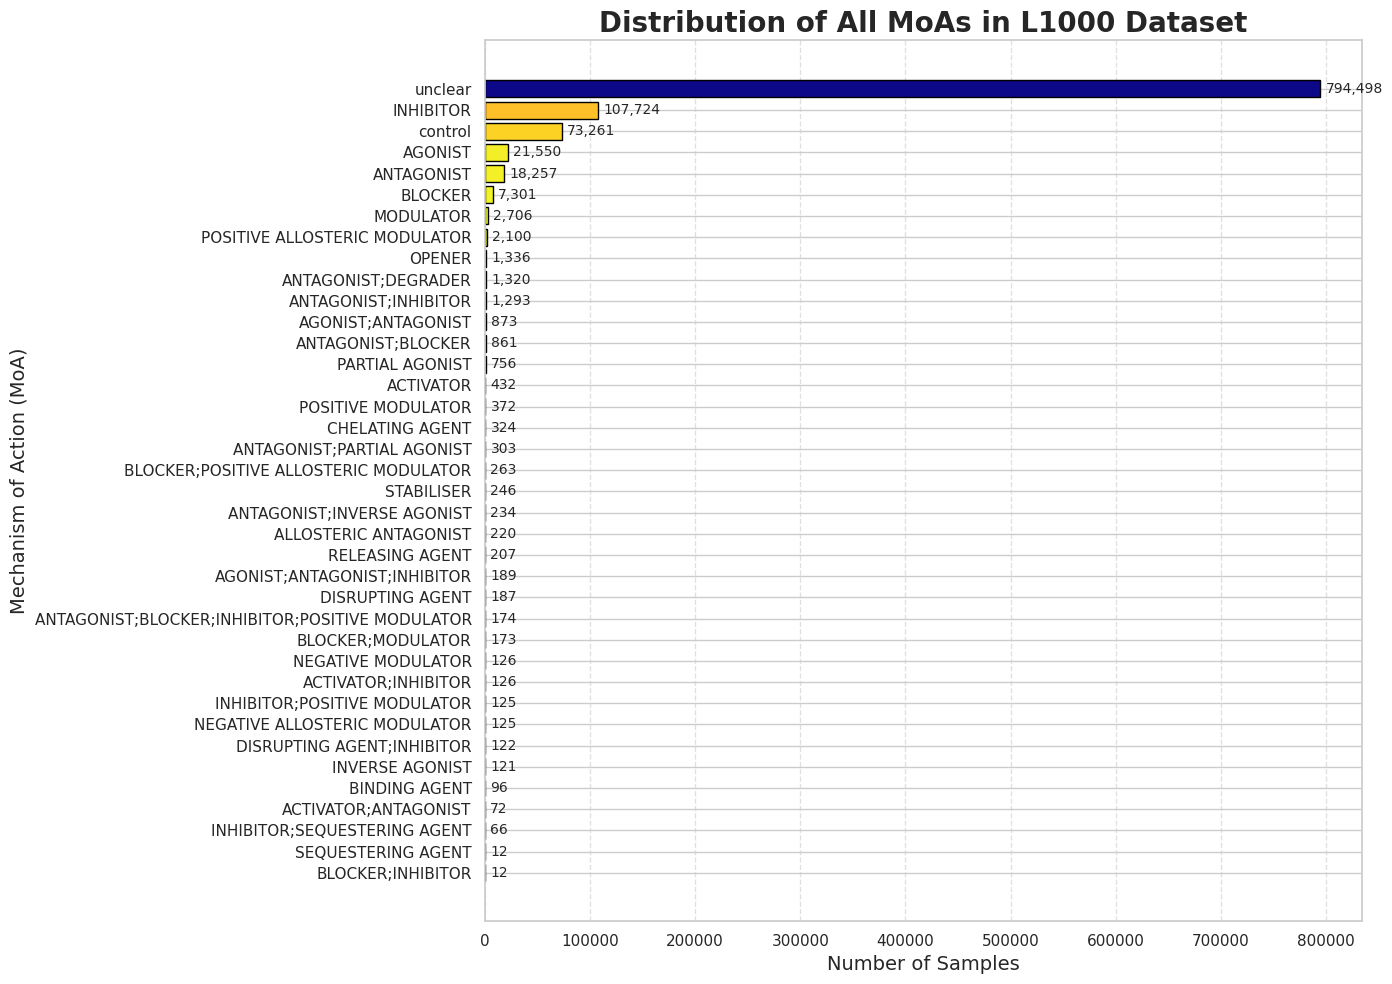

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert your MoA counts dict to DataFrame
df = pd.DataFrame(list(moa_counts.items()), columns=["MoA", "count"])
df = df.sort_values("count")  # smallest at bottom, largest at top

# Plot
plt.figure(figsize=(14,10))
colors = plt.cm.plasma_r(df['count'] / df['count'].max())  # color scaled to counts

bars = plt.barh(df["MoA"], df["count"], color=colors, edgecolor='black')

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5000, bar.get_y() + bar.get_height()/2, f"{int(width):,}", va='center', fontsize=10)

# Updated title
plt.title("Distribution of All MoAs in L1000 Dataset", fontsize=20, fontweight='bold')
plt.xlabel("Number of Samples", fontsize=14)
plt.ylabel("Mechanism of Action (MoA)", fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save high-quality figure
plt.savefig("MoA_distribution_L1000_top20.png", dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
unclear_moa = adata.obs[adata.obs["MoA"] == "unclear"]

In [ ]:
unclear_counts = unclear_moa["pert_type"].value_counts()
print("pert_type counts for unclear MoA samples:")
print(unclear_counts)

pert_type counts for unclear MoA samples:
pert_type
trt_cp         794498
ctl_vehicle         0
Name: count, dtype: int64


In [ ]:
# Ensure all columns are strings
adata.obs["MoA_str"] = adata.obs["MoA"].astype(str)
adata.obs["cell_id_str"] = adata.obs["cell_id"].astype(str)
adata.obs["pert_dose_str"] = adata.obs["pert_dose"].astype(str)

# Create stratification column
adata.obs["stratify_group"] = (
    adata.obs["MoA_str"] + "_" +
    adata.obs["cell_id_str"] + "_" +
    adata.obs["pert_dose_str"]
)

# Quick check
print(adata.obs[["MoA", "cell_id", "pert_dose", "stratify_group"]].head(10))

                                  MoA cell_id  pert_dose       stratify_group
cid                                                                          
REP.A001_A375_24H_X1_B22:A03  control    A375    -666.00  control_A375_-666.0
REP.A001_A375_24H_X1_B22:A04  control    A375    -666.00  control_A375_-666.0
REP.A001_A375_24H_X1_B22:A05  control    A375    -666.00  control_A375_-666.0
REP.A001_A375_24H_X1_B22:A06  control    A375    -666.00  control_A375_-666.0
REP.A001_A375_24H_X1_B22:A07  unclear    A375      10.00    unclear_A375_10.0
REP.A001_A375_24H_X1_B22:A08  unclear    A375       3.33    unclear_A375_3.33
REP.A001_A375_24H_X1_B22:A09  unclear    A375       1.11    unclear_A375_1.11
REP.A001_A375_24H_X1_B22:A10  unclear    A375       0.37    unclear_A375_0.37
REP.A001_A375_24H_X1_B22:A11  unclear    A375       0.12    unclear_A375_0.12
REP.A001_A375_24H_X1_B22:A12  unclear    A375       0.04    unclear_A375_0.04


In [ ]:
# Filter for control samples
control_samples = adata.obs[adata.obs["MoA"] == "control"]

# Further filter by dose unit "%"
control_percent = control_samples[control_samples["pert_dose_unit"] == "%"]

# Show stratification groups
print("Unique stratify groups for control samples with dose unit '%':")
print(control_percent["stratify_group"].unique())



Unique stratify groups for control samples with dose unit '%':
['control_A375_0.1' 'control_A549_0.1' 'control_HA1E_0.1'
 'control_HCC515_0.1' 'control_HEPG2_0.1' 'control_HT29_0.1'
 'control_MCF7_0.1' 'control_PC3_0.1' 'control_VCAP_0.1'
 'control_A673_0.1' 'control_AGS_0.1' 'control_CL34_0.1'
 'control_CORL23_0.1' 'control_COV644_0.1' 'control_DV90_0.1'
 'control_EFO27_0.1' 'control_HCC15_0.1' 'control_HCT116_0.1'
 'control_HEC108_0.1' 'control_HT115_0.1' 'control_JHUEM2_0.1'
 'control_LOVO_0.1' 'control_MDST8_0.1' 'control_NCIH1694_0.1'
 'control_NCIH1836_0.1' 'control_NCIH2073_0.1' 'control_NCIH508_0.1'
 'control_NCIH596_0.1' 'control_NOMO1_0.1' 'control_OV7_0.1'
 'control_PL21_0.1' 'control_RMGI_0.1' 'control_RMUGS_0.1'
 'control_SKLU1_0.1' 'control_SKM1_0.1' 'control_SKMEL1_0.1'
 'control_SKMEL28_0.1' 'control_SNGM_0.1' 'control_SNU1040_0.1'
 'control_SNUC4_0.1' 'control_SNUC5_0.1' 'control_SW480_0.1'
 'control_SW620_0.1' 'control_SW948_0.1' 'control_T3M10_0.1'
 'control_THP1_0.1

In [ ]:
# Define the path for the updated dataset
output_file = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_MoA_strat.h5ad"

# Save the AnnData object
adata.write(output_file)

print(f"Dataset saved successfully to: {output_file}")

Dataset saved successfully to: /sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_MoA_strat.h5ad


In [ ]:
import scanpy as sc

# Load the saved dataset
adata_loaded = sc.read("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_MoA_strat.h5ad")

# Check basic info
print(adata_loaded)

# Check the first few rows of obs (cell metadata)
print(adata_loaded.obs.head())

# Check unique values for MoA
print("\nUnique MoA values:")
print(adata_loaded.obs["MoA"].value_counts())

# Check unique values for stratify_group
print("\nExample stratify groups:")
print(adata_loaded.obs["stratify_group"].unique()[:10])

AnnData object with n_obs × n_vars = 1038163 × 978
    obs: 'dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'MoA', 'pert_dose_str', 'MoA_str', 'cell_id_str', 'stratify_group'
                             dataset_name                 sig_id  \
cid                                                                
REP.A001_A375_24H_X1_B22:A03     GSE70138  REP.A001_A375_24H:A03   
REP.A001_A375_24H_X1_B22:A04     GSE70138  REP.A001_A375_24H:A04   
REP.A001_A375_24H_X1_B22:A05     GSE70138  REP.A001_A375_24H:A05   
REP.A001_A375_24H_X1_B22:A06     GSE70138  REP.A001_A375_24H:A06   
REP.A001_A375_24H_X1_B22:A07     GSE70138  REP.A001_A375_24H:A07   

                                    pert_id      pert_iname    pert_type  \
cid                                                                        
REP.A001_A375_24H_X1_B22:A03           DMSO            DMSO  

In [ ]:
# Drop helper columns
adata.obs = adata.obs.drop(columns=["MoA_str", "cell_id_str", "pert_dose_str"])

# Confirm
print(adata.obs.columns)

Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit', 'MoA', 'stratify_group'],
      dtype='object')


In [ ]:
output_file_clean = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_cleaned.h5ad"
adata.write(output_file_clean)

print(f"Cleaned dataset saved successfully to: {output_file_clean}")

Cleaned dataset saved successfully to: /sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_cleaned.h5ad


In [ ]:
import scanpy as sc

# Load the saved dataset
adata_loaded = sc.read("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_cleaned.h5ad")

# Check basic info
print(adata_loaded)

# Check the first few rows of obs (cell metadata)
print(adata_loaded.obs.head())

# Check unique values for MoA
print("\nUnique MoA values:")
print(adata_loaded.obs["MoA"].value_counts())

# Check unique values for stratify_group
print("\nExample stratify groups:")
print(adata_loaded.obs["stratify_group"].unique()[:10])

AnnData object with n_obs × n_vars = 1038163 × 978
    obs: 'dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'MoA', 'stratify_group'
                             dataset_name                 sig_id  \
cid                                                                
REP.A001_A375_24H_X1_B22:A03     GSE70138  REP.A001_A375_24H:A03   
REP.A001_A375_24H_X1_B22:A04     GSE70138  REP.A001_A375_24H:A04   
REP.A001_A375_24H_X1_B22:A05     GSE70138  REP.A001_A375_24H:A05   
REP.A001_A375_24H_X1_B22:A06     GSE70138  REP.A001_A375_24H:A06   
REP.A001_A375_24H_X1_B22:A07     GSE70138  REP.A001_A375_24H:A07   

                                    pert_id      pert_iname    pert_type  \
cid                                                                        
REP.A001_A375_24H_X1_B22:A03           DMSO            DMSO  ctl_vehicle   
REP.A001_A375_24H_X1_B22:A04

In [ ]:
# Identify rows where MoA is empty or NaN
missing_moa = adata.obs[adata.obs["MoA"].isna() | (adata.obs["MoA"] == "")]

# How many rows are missing
print(f"Number of cells with missing MoA: {missing_moa.shape[0]}")

# Optionally, look at the first few
print(missing_moa.head())

Number of cells with missing MoA: 0
Empty DataFrame
Columns: [dataset_name, sig_id, pert_id, pert_iname, pert_type, cell_id, pert_idose, pert_itime, condition, canonical_smiles, valid_smiles, pert_dose, pert_dose_unit, MoA, stratify_group]
Index: []


In [ ]:
# Count all MoA types in your dataset
moa_counts = adata.obs["MoA"].value_counts(dropna=False)  # counts all, including NaN if any

# Convert to a DataFrame for clarity
moa_counts_df = moa_counts.reset_index()
moa_counts_df.columns = ["MoA", "count"]

# Sort descending by count
moa_counts_df = moa_counts_df.sort_values(by="count", ascending=False)

# Display
print(moa_counts_df)

# Optional: save a CSV for reference
moa_counts_df.to_csv("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/MoA_counts_summary.csv", index=False)

                                                MoA   count
0                                           unclear  794498
1                                         INHIBITOR  107724
2                                           control   73261
3                                           AGONIST   21550
4                                        ANTAGONIST   18257
5                                           BLOCKER    7301
6                                         MODULATOR    2706
7                     POSITIVE ALLOSTERIC MODULATOR    2100
8                                            OPENER    1336
9                               ANTAGONIST;DEGRADER    1320
10                             ANTAGONIST;INHIBITOR    1293
11                               AGONIST;ANTAGONIST     873
12                               ANTAGONIST;BLOCKER     861
13                                  PARTIAL AGONIST     756
14                                        ACTIVATOR     432
15                               POSITIV

In [ ]:
# Sum all counts
total_cells = moa_df["count"].sum()
print(f"Total number of cells across all MoAs: {total_cells}")

Total number of cells across all MoAs: 1038163


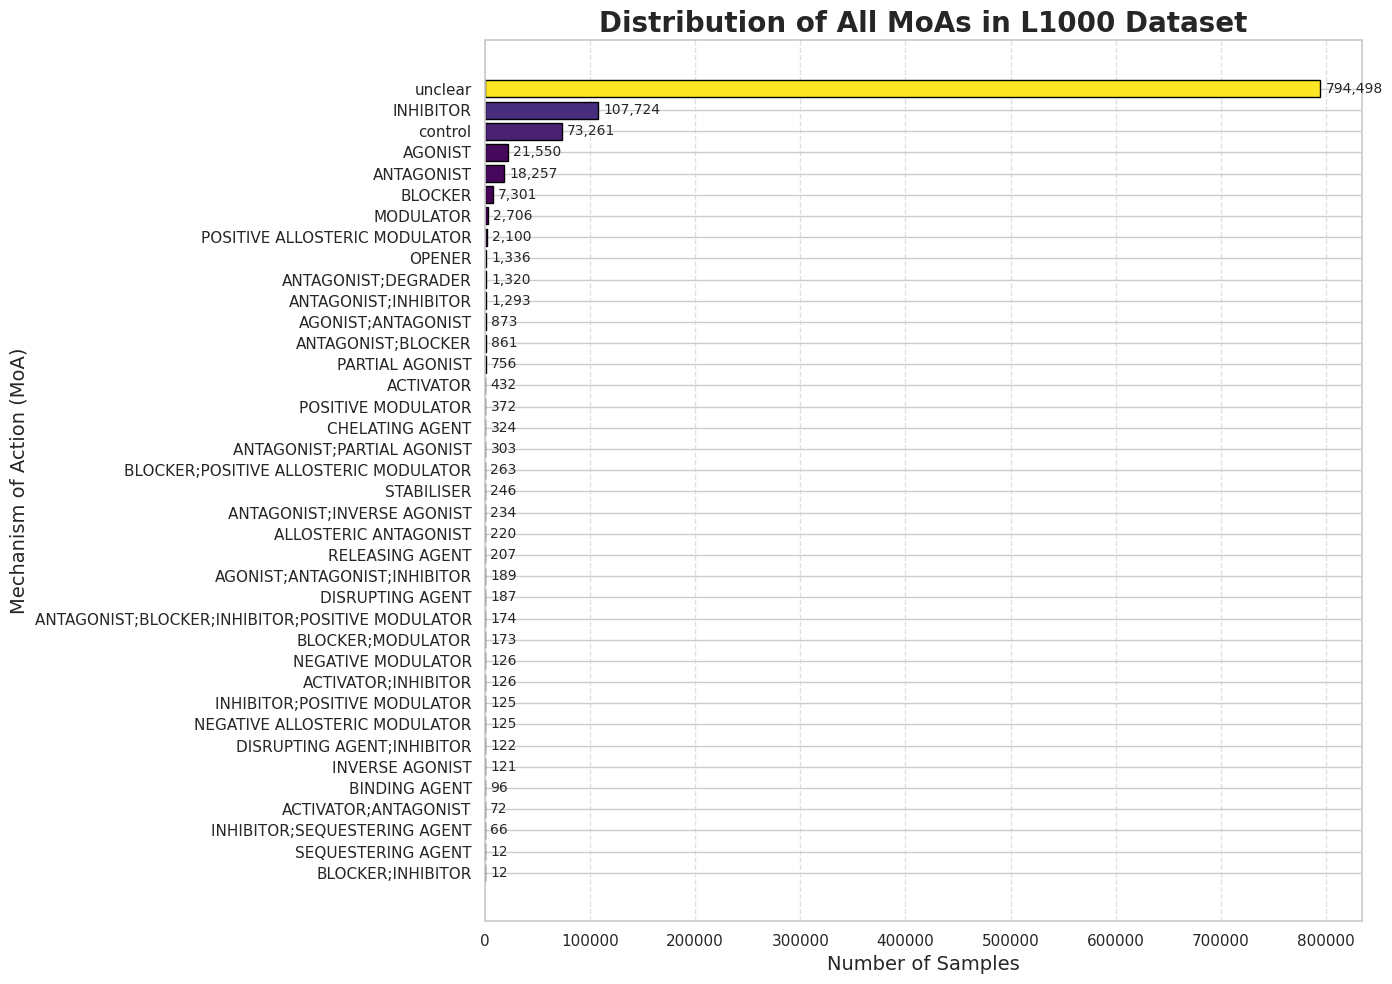

In [ ]:
import matplotlib.pyplot as plt

# Count all MoAs
moa_counts = adata.obs["MoA"].value_counts(dropna=False)

# Convert to DataFrame
moa_df = moa_counts.reset_index()
moa_df.columns = ["MoA", "count"]
moa_df = moa_df.sort_values(by="count")  # smallest at bottom for horizontal bar plot

# Plot
plt.figure(figsize=(14,10))
colors = plt.cm.viridis(moa_df['count'] / moa_df['count'].max())  # color scale by count

bars = plt.barh(moa_df["MoA"], moa_df["count"], color=colors, edgecolor='black')

# Add labels at the end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5000, bar.get_y() + bar.get_height()/2, f"{int(width):,}", va='center', fontsize=10)

# Titles and labels
plt.title("Distribution of All MoAs in L1000 Dataset", fontsize=20, fontweight='bold')
plt.xlabel("Number of Samples", fontsize=14)
plt.ylabel("Mechanism of Action (MoA)", fontsize=14)

# Grid and layout
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save high-quality figure
plt.savefig("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/MoA_distribution_all_L1000.png", dpi=400, bbox_inches='tight')

plt.show()

In [ ]:
# Count missing (NaN) values
missing_count = adata.obs["pert_iname"].isna().sum()

# Count empty strings
empty_str_count = (adata.obs["pert_iname"] == "").sum()

# Total "empty" pert_iname
total_empty = missing_count + empty_str_count

print(f"Number of NaN pert_iname: {missing_count}")
print(f"Number of empty string pert_iname: {empty_str_count}")
print(f"Total empty or missing pert_iname: {total_empty}")

Number of NaN pert_iname: 0
Number of empty string pert_iname: 0
Total empty or missing pert_iname: 0


In [ ]:
import anndata
import pandas as pd

# Path to your merged file
file_path = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_cleaned.h5ad"

# Load the .h5ad file
adata = anndata.read_h5ad(file_path)

# Check available columns
print(adata.obs.columns)

Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit', 'MoA', 'stratify_group'],
      dtype='object')


In [ ]:
moa_df = adata.obs[~adata.obs["MoA"].isin(["unclear", "control"])].copy()

NameError: name 'adata' is not defined

In [ ]:
# List all unique MoAs
print(sorted(moa_df["MoA"].unique()))

['ACTIVATOR', 'ACTIVATOR;ANTAGONIST', 'ACTIVATOR;INHIBITOR', 'AGONIST', 'AGONIST;ANTAGONIST', 'AGONIST;ANTAGONIST;INHIBITOR', 'ALLOSTERIC ANTAGONIST', 'ANTAGONIST', 'ANTAGONIST;BLOCKER', 'ANTAGONIST;BLOCKER;INHIBITOR;POSITIVE MODULATOR', 'ANTAGONIST;DEGRADER', 'ANTAGONIST;INHIBITOR', 'ANTAGONIST;INVERSE AGONIST', 'ANTAGONIST;PARTIAL AGONIST', 'BINDING AGENT', 'BLOCKER', 'BLOCKER;INHIBITOR', 'BLOCKER;MODULATOR', 'BLOCKER;POSITIVE ALLOSTERIC MODULATOR', 'CHELATING AGENT', 'DISRUPTING AGENT', 'DISRUPTING AGENT;INHIBITOR', 'INHIBITOR', 'INHIBITOR;POSITIVE MODULATOR', 'INHIBITOR;SEQUESTERING AGENT', 'INVERSE AGONIST', 'MODULATOR', 'NEGATIVE ALLOSTERIC MODULATOR', 'NEGATIVE MODULATOR', 'OPENER', 'PARTIAL AGONIST', 'POSITIVE ALLOSTERIC MODULATOR', 'POSITIVE MODULATOR', 'RELEASING AGENT', 'SEQUESTERING AGENT', 'STABILISER']


In [ ]:
import sqlite3
import pandas as pd

# Connect to ChEMBL database
chembl_db = "/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db"
conn = sqlite3.connect(chembl_db)

# Example: list tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

                         name
0                 action_type
1                  assay_type
2            chembl_id_lookup
3     confidence_score_lookup
4             curation_lookup
..                        ...
69   pesticide_classification
70  predicted_binding_domains
71               warning_refs
72    pesticide_class_mapping
73               sqlite_stat1

[74 rows x 1 columns]


In [ ]:
import sqlite3
import pandas as pd

# Connect to ChEMBL database
chembl_db = "/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db"
conn = sqlite3.connect(chembl_db)

# Extract canonical names from molecule_dictionary
molecules = pd.read_sql("SELECT molregno, pref_name, chembl_id FROM molecule_dictionary", conn)

# Extract MoA from mechanism_of_action
moa = pd.read_sql("SELECT molregno, mechanism_of_action FROM mechanism_of_action", conn)

# Merge molecules with their MoA
chembl_df = pd.merge(molecules, moa, on="molregno")

# Clean names for merging
chembl_df["drug_clean"] = chembl_df["pref_name"].str.lower().str.strip()
chembl_df["MoA_chembl"] = chembl_df["mechanism_of_action"]

chembl_df = chembl_df[["drug_clean", "MoA_chembl", "chembl_id"]]
print(chembl_df.head())

DatabaseError: Execution failed on sql 'SELECT molregno, mechanism_of_action FROM mechanism_of_action': no such table: mechanism_of_action

In [ ]:
import sqlite3
import pandas as pd

# Connect to ChEMBL
conn = sqlite3.connect("/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db")

# Example: list tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

                         name
0                 action_type
1                  assay_type
2            chembl_id_lookup
3     confidence_score_lookup
4             curation_lookup
..                        ...
69   pesticide_classification
70  predicted_binding_domains
71               warning_refs
72    pesticide_class_mapping
73               sqlite_stat1

[74 rows x 1 columns]


In [ ]:
import sqlite3
import pandas as pd

# Connect to ChEMBL
conn = sqlite3.connect("/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db")

# Get all table names
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

# Print all tables
for t in tables['name']:
    print(t)

action_type
assay_type
chembl_id_lookup
confidence_score_lookup
curation_lookup
chembl_release
source
relationship_type
target_type
variant_sequences
bioassay_ontology
data_validity_lookup
activity_smid
activity_stds_lookup
assay_classification
atc_classification
bio_component_sequences
component_sequences
protein_classification
domains
go_classification
structural_alert_sets
products
organism_class
patent_use_codes
usan_stems
version
cell_dictionary
docs
target_dictionary
tissue_dictionary
molecule_dictionary
activity_supp
component_class
component_domains
component_go
component_synonyms
structural_alerts
defined_daily_dose
product_patents
protein_class_synonyms
assays
compound_records
binding_sites
biotherapeutics
compound_properties
compound_structural_alerts
compound_structures
molecule_atc_classification
molecule_hierarchy
molecule_synonyms
target_components
target_relations
activities
assay_class_map
assay_parameters
biotherapeutic_components
drug_indication
drug_mechanism
drug_w

In [ ]:
pd.set_option('display.max_rows', None)  # Show all rows
print(tables)
pd.reset_option('display.max_rows')      # Reset option back to default

                           name
0                   action_type
1                    assay_type
2              chembl_id_lookup
3       confidence_score_lookup
4               curation_lookup
5                chembl_release
6                        source
7             relationship_type
8                   target_type
9             variant_sequences
10            bioassay_ontology
11         data_validity_lookup
12                activity_smid
13         activity_stds_lookup
14         assay_classification
15           atc_classification
16      bio_component_sequences
17          component_sequences
18       protein_classification
19                      domains
20            go_classification
21        structural_alert_sets
22                     products
23               organism_class
24             patent_use_codes
25                   usan_stems
26                      version
27              cell_dictionary
28                         docs
29            target_dictionary
30      

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db")

# Check column names
columns = pd.read_sql("PRAGMA table_info(chembl_id_lookup);", conn)
print(columns)

   cid         name         type  notnull dflt_value  pk
0    0    chembl_id  VARCHAR(20)        1       None   1
1    1  entity_type  VARCHAR(50)        1       None   0
2    2    entity_id       BIGINT        1       None   0
3    3       status  VARCHAR(10)        1       None   0
4    4  last_active      INTEGER        0       None   0


In [ ]:
columns = pd.read_sql("PRAGMA table_info(molecule_dictionary);", conn)
print(columns)

    cid                  name           type  notnull dflt_value  pk
0     0              molregno         BIGINT        1       None   1
1     1             pref_name   VARCHAR(255)        0       None   0
2     2             chembl_id    VARCHAR(20)        1       None   0
3     3             max_phase  NUMERIC(2, 1)        0       None   0
4     4      therapeutic_flag       SMALLINT        1       None   0
5     5      dosed_ingredient       SMALLINT        1       None   0
6     6        structure_type    VARCHAR(10)        1       None   0
7     7         molecule_type    VARCHAR(30)        0       None   0
8     8        first_approval        INTEGER        0       None   0
9     9                  oral       SMALLINT        1       None   0
10   10            parenteral       SMALLINT        1       None   0
11   11               topical       SMALLINT        1       None   0
12   12     black_box_warning       SMALLINT        1       None   0
13   13       natural_product     

In [ ]:
# Read some samples of pref_name
pref_name_sample = pd.read_sql("SELECT pref_name FROM molecule_dictionary LIMIT 20;", conn)

# Show the sample
print(pref_name_sample)

   pref_name
0       None
1       None
2       None
3       None
4       None
5       None
6       None
7       None
8       None
9       None
10      None
11      None
12      None
13      None
14      None
15      None
16      None
17      None
18      None
19      None


In [ ]:
columns = pd.read_sql("PRAGMA table_info(chembl_id_lookup);", conn)
print(columns)

   cid         name         type  notnull dflt_value  pk
0    0    chembl_id  VARCHAR(20)        1       None   1
1    1  entity_type  VARCHAR(50)        1       None   0
2    2    entity_id       BIGINT        1       None   0
3    3       status  VARCHAR(10)        1       None   0
4    4  last_active      INTEGER        0       None   0


In [ ]:
sample = pd.read_sql("SELECT * FROM chembl_id_lookup LIMIT 20;", conn)
print(sample)

        chembl_id entity_type  entity_id    status  last_active
0         CHEMBL1    COMPOUND     517180    ACTIVE         36.0
1        CHEMBL10    COMPOUND        250    ACTIVE         36.0
2       CHEMBL100    COMPOUND      12356    ACTIVE         36.0
3      CHEMBL1000    COMPOUND     111185    ACTIVE         36.0
4     CHEMBL10000    COMPOUND       7079    ACTIVE         36.0
5    CHEMBL100000    COMPOUND     166734  INACTIVE          NaN
6   CHEMBL1000000       ASSAY     551205    ACTIVE         36.0
7   CHEMBL1000001       ASSAY     551206    ACTIVE         36.0
8   CHEMBL1000002       ASSAY     551207    ACTIVE         36.0
9   CHEMBL1000003       ASSAY     551208    ACTIVE         36.0
10  CHEMBL1000004       ASSAY     551209    ACTIVE         36.0
11  CHEMBL1000005       ASSAY     551210    ACTIVE         36.0
12  CHEMBL1000006       ASSAY     551211    ACTIVE         36.0
13  CHEMBL1000007       ASSAY     551212    ACTIVE         36.0
14  CHEMBL1000008       ASSAY     551213

In [ ]:
import scanpy as sc

adata = sc.read_h5ad("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase.h5ad")

# View columns in .obs
print(adata.obs.columns)

# Example: show unique perturbation names
lincs_drugs = adata.obs[['condition', 'pert_iname']].drop_duplicates()
print(lincs_drugs.head())

Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit'],
      dtype='object')
                                   condition      pert_iname
cid                                                         
REP.A001_A375_24H_X1_B22:A03            DMSO            DMSO
REP.A001_A375_24H_X1_B22:A07  aminoguanidine  aminoguanidine
REP.A001_A375_24H_X1_B22:A13      pritelivir      pritelivir
REP.A001_A375_24H_X1_B22:A19      batimastat      batimastat
REP.A001_A375_24H_X1_B22:B07           CX516          CX-516


In [ ]:
import sqlite3
import pandas as pd

# Connect to ChEMBL SQLite
conn = sqlite3.connect("/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db")

# Query all drugs with their MoA
moa_df = pd.read_sql_query("""
SELECT
    molecule_dictionary.chembl_id,
    molecule_dictionary.pref_name,
    drug_mechanism.mechanism_of_action,
    drug_mechanism.action_type
FROM drug_mechanism
JOIN molecule_dictionary
ON drug_mechanism.molregno = molecule_dictionary.molregno
""", conn)

# Show the first rows
print(moa_df.head())

       chembl_id             pref_name               mechanism_of_action  \
0       CHEMBL19         METHAZOLAMIDE  Carbonic anhydrase VII inhibitor   
1  CHEMBL1201117         METHOCARBAMOL    Carbonic anhydrase I inhibitor   
2  CHEMBL1200814  ACETAZOLAMIDE SODIUM    Carbonic anhydrase I inhibitor   
3       CHEMBL17      DICHLORPHENAMIDE    Carbonic anhydrase I inhibitor   
4       CHEMBL20         ACETAZOLAMIDE    Carbonic anhydrase I inhibitor   

  action_type  
0   INHIBITOR  
1   INHIBITOR  
2   INHIBITOR  
3   INHIBITOR  
4   INHIBITOR  


In [ ]:
type (moa_df)

pandas.core.frame.DataFrame

In [ ]:
import numpy as np
moa_df.shape

(7568, 5)

In [ ]:
chembl_drugs = moa_df['chembl_id'].unique()

In [ ]:
chembl_drugs

array(['CHEMBL19', 'CHEMBL1201117', 'CHEMBL1200814', ..., 'CHEMBL1628227',
       'CHEMBL934', 'CHEMBL81'], shape=(5961,), dtype=object)

In [ ]:
# Unique LINCS drug names (conditions)
lincs_drugs = adata.obs['condition'].unique()

In [ ]:
lincs_drugs

['DMSO', 'aminoguanidine', 'pritelivir', 'batimastat', 'CX516', ..., 'BRDK22321414', 'BRDK21001652', 'PF543', 'AVA', 'BRDK64106162']
Length: 17931
Categories (17931, object): ['1benzylimidazole', '1methylisoquinoline', '1monopalmitin', '1phenylbiguanide', ..., 'zosuquidar', 'zoxazolamine', 'zprolylprolinal', 'zuclopenthixol']

In [ ]:
# Unique ChEMBL drug names
chembl_drugs = moa_df['pref_name'].unique()

In [ ]:
chembl_drugs

array(['METHAZOLAMIDE', 'METHOCARBAMOL', 'ACETAZOLAMIDE SODIUM', ...,
       'DOXEPIN', 'METYRAPONE', 'RALOXIFENE'], shape=(5961,), dtype=object)

In [ ]:
def normalize_name(name):
    if pd.isna(name):
        return ""
    return name.replace("-", "").replace(" ", "").upper()

lincs_drugs_norm = [normalize_name(x) for x in lincs_drugs]
chembl_drugs_norm = [normalize_name(x) for x in chembl_drugs]

In [ ]:
unique_lincs_drugs = list(set(lincs_drugs_norm))
print(len(unique_lincs_drugs))


17931


In [ ]:
unique_chembl_drugs = list(set(chembl_drugs_norm))
print(len(unique_chembl_drugs))

5960


In [ ]:
# Convert to sets for fast comparison
lincs_set = set(lincs_drugs_norm)
chembl_set = set(chembl_drugs_norm)

# ChEMBL drugs that exist in LINCS
chembl_in_lincs = chembl_set.intersection(lincs_set)

# ChEMBL drugs that are NOT in LINCS
chembl_not_in_lincs = chembl_set.difference(lincs_set)

print(f"ChEMBL drugs present in LINCS: {len(chembl_in_lincs)}")
print(f"ChEMBL drugs NOT in LINCS: {len(chembl_not_in_lincs)}")

ChEMBL drugs present in LINCS: 1046
ChEMBL drugs NOT in LINCS: 4914


In [ ]:
import pandas as pd

# Example normalize function
def normalize_name(name):
    if pd.isna(name):
        return ""
    return name.replace("-", "").replace(" ", "").upper()

# Suppose `lincs_drugs` is your list of unique LINCS conditions
lincs_drugs_norm = [normalize_name(x) for x in lincs_drugs]

# Suppose `chembl_drugs` is your list of ChEMBL pref_names
chembl_drugs_norm = [normalize_name(x) for x in chembl_drugs]

# Convert ChEMBL list to a set for fast lookups
chembl_set = set(chembl_drugs_norm)

In [ ]:
# Exact matches
exact_matches = [drug for drug in lincs_drugs_norm if drug in chembl_set]

# Non-matches
non_matches = [drug for drug in lincs_drugs_norm if drug not in chembl_set]

print(f"Number of exact matches: {len(exact_matches)}")
print(f"Number of non-matches: {len(non_matches)}")

Number of exact matches: 1046
Number of non-matches: 16885


In [ ]:
from rapidfuzz import process

# Function to match with a threshold
def match_lincs_to_chembl(lincs_name, chembl_choices, threshold=80):
    result = process.extractOne(lincs_name, chembl_choices)
    if result is None:
        return None
    match_name, score, _ = result
    return match_name if score >= threshold else None

# Build mapping for non-matches
mapping = {}
for drug in non_matches:
    matched = match_lincs_to_chembl(drug, list(chembl_set), threshold=80)
    if matched and matched != drug:  # only keep mapping if there is a difference
        mapping[drug] = matched

print(f"Number of fuzzy matches found: {len(mapping)}")

Number of fuzzy matches found: 868


In [ ]:
from rapidfuzz import fuzz

# Prepare a list to store matches with their scores
fuzzy_matches_list = []

for lincs_name, chembl_name in mapping.items():
    score = fuzz.ratio(lincs_name, chembl_name)  # similarity score (0-100)
    fuzzy_matches_list.append({
        "lincs_name": lincs_name,
        "chembl_name": chembl_name,
        "similarity_score": score
    })

# Convert to DataFrame for easy viewing
fuzzy_matches_df = pd.DataFrame(fuzzy_matches_list)

# Show top 20 matches (or more if you like)
print(fuzzy_matches_df.sort_values(by="similarity_score", ascending=False).head(20))

                        lincs_name                  chembl_name  \
516     DEOXYCORTICOSTERONEACETATE  DESOXYCORTICOSTERONEACETATE   
415            CANDESARTANCILEXTIL         CANDESARTANCILEXETIL   
197                GUANABENACETATE             GUANABENZACETATE   
13   17HYDROXYPROGESTERONECAPROATE  HYDROXYPROGESTERONECAPROATE   
243                  ETACRYNICACID               ETHACRYNICACID   
555                   NORETYNODREL                NORETHYNODREL   
335                   TIABENDAZOLE                THIABENDAZOLE   
713                   DEBRISOQUINE                  DEBRISOQUIN   
183                    INDOMETACIN                 INDOMETHACIN   
625                   CYCLOSERINED                  CYCLOSERINE   
353                     TIOGUANINE                  THIOGUANINE   
618                     EPOTHILONE                  EPOTHILONED   
605                     PENICILLIN                  PENICILLINV   
292                     IDOXURIDIN                  IDOXURIDIN

In [ ]:
from rapidfuzz import process

# List of LINCS drug names
lincs_conditions = adata.obs['condition'].unique().tolist()

# Function to match ChEMBL drug to closest LINCS condition
def match_condition(pref_name, choices, threshold=80):
    result = process.extractOne(pref_name, choices)
    if result is None:
        return None
    match_name, score, _ = result
    return match_name if score >= threshold else None

# Apply to ChEMBL dataframe
moa_df['matched_condition'] = moa_df['pref_name'].apply(lambda x: match_condition(x, lincs_conditions))

In [ ]:
# Show first 20 rows with the matching
print(moa_df[['pref_name', 'mechanism_of_action', 'action_type', 'matched_condition']].head(20))

# Optionally, show all ChEMBL drugs that DID NOT match any LINCS condition
unmatched = moa_df[moa_df['matched_condition'].isna()]
print(f"Number of ChEMBL drugs not matched to LINCS: {len(unmatched)}")
print(unmatched[['pref_name', 'mechanism_of_action', 'action_type']].head(20))

                     pref_name  \
0                METHAZOLAMIDE   
1                METHOCARBAMOL   
2         ACETAZOLAMIDE SODIUM   
3             DICHLORPHENAMIDE   
4                ACETAZOLAMIDE   
5                METHAZOLAMIDE   
6                   ATOVAQUONE   
7       TRIDIHEXETHYL CHLORIDE   
8         TOLTERODINE TARTRATE   
9        PROPANTHELINE BROMIDE   
10        OXYPHENONIUM BROMIDE   
11         MEPENZOLATE BROMIDE   
12   HEXOCYCLIUM METHYLSULFATE   
13    DIPHEMANIL METHYLSULFATE   
14   DICYCLOMINE HYDROCHLORIDE   
15        BETHANECHOL CHLORIDE   
16  ANISOTROPINE METHYLBROMIDE   
17            ATROPINE SULFATE   
18                    ATROPINE   
19                 TROPICAMIDE   

                                mechanism_of_action action_type  \
0                  Carbonic anhydrase VII inhibitor   INHIBITOR   
1                    Carbonic anhydrase I inhibitor   INHIBITOR   
2                    Carbonic anhydrase I inhibitor   INHIBITOR   
3                

In [ ]:
moa_df[moa_df['pref_name'].str.contains("CX")][['pref_name', 'matched_condition']]

,pref_name,matched_condition
2809,CX1739,None
3205,CCX354,None


In [ ]:
from rapidfuzz import process

# Normalize names
def normalize_name(name):
    if pd.isna(name):
        return ""
    return name.replace("-", "").replace(" ", "").upper()

# Prepare LINCS conditions
lincs_conditions_norm = [normalize_name(x) for x in adata.obs['condition'].unique()]

# Normalize ChEMBL pref_name
moa_df['pref_name_norm'] = moa_df['pref_name'].apply(normalize_name)

# Fuzzy match with normalized names
def match_condition_norm(pref_name_norm, choices, threshold=80):
    result = process.extractOne(pref_name_norm, choices)
    if result is None:
        return None
    match_name, score, _ = result
    return match_name if score >= threshold else None

moa_df['matched_condition'] = moa_df['pref_name_norm'].apply(lambda x: match_condition_norm(x, lincs_conditions_norm))

# Check matches
matched = moa_df[moa_df['matched_condition'].notna()]
unmatched = moa_df[moa_df['matched_condition'].isna()]

print(f"Total ChEMBL drugs matched to LINCS: {len(matched)}")
print(f"Total ChEMBL drugs NOT matched: {len(unmatched)}")
print(unmatched[['pref_name', 'mechanism_of_action', 'action_type']].head(10))

Total ChEMBL drugs matched to LINCS: 3315
Total ChEMBL drugs NOT matched: 4253
                     pref_name  \
12   HEXOCYCLIUM METHYLSULFATE   
16  ANISOTROPINE METHYLBROMIDE   
23       METHACHOLINE CHLORIDE   
24          TIOTROPIUM BROMIDE   
25       FESOTERODINE FUMARATE   
38      GLYCOPYRRONIUM BROMIDE   
39         ISOPROPAMIDE IODIDE   
40           TROSPIUM CHLORIDE   
42           PEGAPTANIB SODIUM   
43                 RANIBIZUMAB   

                                mechanism_of_action action_type  
12  Muscarinic acetylcholine receptor M3 antagonist  ANTAGONIST  
16  Muscarinic acetylcholine receptor M3 antagonist  ANTAGONIST  
23     Muscarinic acetylcholine receptor M3 agonist     AGONIST  
24  Muscarinic acetylcholine receptor M3 antagonist  ANTAGONIST  
25  Muscarinic acetylcholine receptor M3 antagonist  ANTAGONIST  
38  Muscarinic acetylcholine receptor M3 antagonist  ANTAGONIST  
39  Muscarinic acetylcholine receptor M3 antagonist  ANTAGONIST  
40  Muscarinic ace

In [ ]:
# Get unique drug names from your LINCS dataset
unique_drugs = adata.obs[['condition', 'pert_iname']].drop_duplicates()

# How many unique drugs?
print(f"Number of unique LINCS drugs: {len(unique_drugs)}")

# Preview first 20 unique drugs
print(unique_drugs.head(20))

# Optional: list all unique drug names
all_unique_drug_names = unique_drugs['condition'].tolist()
print(all_unique_drug_names[:50])  # first 50 names

Number of unique LINCS drugs: 17936
                                      condition         pert_iname
cid                                                               
REP.A001_A375_24H_X1_B22:A03               DMSO               DMSO
REP.A001_A375_24H_X1_B22:A07     aminoguanidine     aminoguanidine
REP.A001_A375_24H_X1_B22:A13         pritelivir         pritelivir
REP.A001_A375_24H_X1_B22:A19         batimastat         batimastat
REP.A001_A375_24H_X1_B22:B07              CX516             CX-516
REP.A001_A375_24H_X1_B22:B13  aminoglutethimide  aminoglutethimide
REP.A001_A375_24H_X1_B22:B19          oxaprozin          oxaprozin
REP.A001_A375_24H_X1_B22:C01      physostigmine      physostigmine
REP.A001_A375_24H_X1_B22:C07        blonanserin        blonanserin
REP.A001_A375_24H_X1_B22:C13          zaldaride          zaldaride
REP.A001_A375_24H_X1_B22:C19         bortezomib         bortezomib
REP.A001_A375_24H_X1_B22:D01          josamycin          josamycin
REP.A001_A375_24H_X1_B22:D

In [ ]:
# Show first 20 matches
matched_df = moa_df[moa_df['matched_condition'].notna()]
print(matched_df[['pref_name', 'matched_condition']].head(20))

                    pref_name     matched_condition
0               METHAZOLAMIDE         METHAZOLAMIDE
1               METHOCARBAMOL         METHOCARBAMOL
2        ACETAZOLAMIDE SODIUM         ACETAZOLAMIDE
3            DICHLORPHENAMIDE        CHLORPHENAMINE
4               ACETAZOLAMIDE         ACETAZOLAMIDE
5               METHAZOLAMIDE         METHAZOLAMIDE
6                  ATOVAQUONE            ATOVAQUONE
7      TRIDIHEXETHYL CHLORIDE         TRIDIHEXETHYL
8        TOLTERODINE TARTRATE           TOLTERODINE
9       PROPANTHELINE BROMIDE         PROPANTHELINE
10       OXYPHENONIUM BROMIDE          OXYPHENONIUM
11        MEPENZOLATE BROMIDE           MEPENZOLATE
13   DIPHEMANIL METHYLSULFATE            DIPHEMANIL
14  DICYCLOMINE HYDROCHLORIDE      BCIHYDROCHLORIDE
15       BETHANECHOL CHLORIDE           BETHANECHOL
17           ATROPINE SULFATE              ATROPINE
18                   ATROPINE              ATROPINE
19                TROPICAMIDE           TROPICAMIDE
20      SOLI

In [ ]:
from rapidfuzz import fuzz

# Compute similarity ratio between ChEMBL pref_name and matched LINCS condition
moa_df['similarity_score'] = moa_df.apply(
    lambda row: fuzz.ratio(str(row['pref_name']), str(row['matched_condition'])) if pd.notna(row['matched_condition']) else 0,
    axis=1
)

# Inspect low-score matches (<90)
suspicious_matches = moa_df[moa_df['similarity_score'] < 90]
print(suspicious_matches[['pref_name', 'matched_condition', 'similarity_score']].head(20))

                       pref_name matched_condition  similarity_score
2           ACETAZOLAMIDE SODIUM     ACETAZOLAMIDE         78.787879
3               DICHLORPHENAMIDE    CHLORPHENAMINE         86.666667
7         TRIDIHEXETHYL CHLORIDE     TRIDIHEXETHYL         74.285714
8           TOLTERODINE TARTRATE       TOLTERODINE         70.967742
9          PROPANTHELINE BROMIDE     PROPANTHELINE         76.470588
10          OXYPHENONIUM BROMIDE      OXYPHENONIUM         75.000000
11           MEPENZOLATE BROMIDE       MEPENZOLATE         73.333333
12     HEXOCYCLIUM METHYLSULFATE              None          0.000000
13      DIPHEMANIL METHYLSULFATE        DIPHEMANIL         58.823529
14     DICYCLOMINE HYDROCHLORIDE  BCIHYDROCHLORIDE         73.170732
15          BETHANECHOL CHLORIDE       BETHANECHOL         70.967742
16    ANISOTROPINE METHYLBROMIDE              None          0.000000
17              ATROPINE SULFATE          ATROPINE         66.666667
21      DARIFENACIN HYDROBROMIDE  

In [ ]:
molecule_synonyms = pd.read_sql("SELECT molregno, synonyms, syn_type FROM molecule_synonyms;", conn)

In [ ]:
mol_df = pd.read_sql("SELECT molregno, pref_name, chembl_id FROM molecule_dictionary;", conn)
merged_syn = molecule_synonyms.merge(mol_df, on="molregno", how="left")

In [ ]:
from rapidfuzz import process

lincs_conditions = [normalize_drug(x) for x in adata.obs['condition'].unique()]
merged_syn['syn_norm'] = merged_syn['synonyms'].apply(normalize_drug)

# Match
merged_syn['matched_condition'] = merged_syn['syn_norm'].apply(lambda x: process.extractOne(x, lincs_conditions, score_cutoff=90))

NameError: name 'normalize_drug' is not defined

In [ ]:
# Number of unique drugs in ChEMBL MoA dataset
num_unique_chembl_drugs = moa_df['pref_name'].nunique()
print(f"Number of unique drugs in ChEMBL: {num_unique_chembl_drugs}")

Number of unique drugs in ChEMBL: 5961


In [ ]:
num_unique_chembl_drugs_norm = moa_df['pref_name_norm'].nunique()

print(f"Number of unique drugs in ChEMBL after normalization: {num_unique_chembl_drugs_norm}")

Number of unique drugs in ChEMBL after normalization: 5960


In [ ]:
# Step 1: Keep both original and normalized names
moa_df['pref_name_norm'] = moa_df['pref_name'].apply(normalize_name)

# Step 2: Find duplicates after normalization
duplicates_norm = moa_df[moa_df.duplicated(subset=['pref_name_norm'], keep=False)]

# Step 3: Display the original names that were merged
duplicates_grouped = duplicates_norm.groupby('pref_name_norm')['pref_name'].unique().reset_index()

print(duplicates_grouped)

           pref_name_norm               pref_name
0                   2X121                [2X-121]
1                  4SC203               [4SC-203]
2              ABAMETAPIR            [ABAMETAPIR]
3               ABATACEPT             [ABATACEPT]
4                ABBV3373             [ABBV-3373]
...                   ...                     ...
1039  ZIPRASIDONEMESYLATE  [ZIPRASIDONE MESYLATE]
1040         ZOLIFLODACIN          [ZOLIFLODACIN]
1041      ZOLIMOMABARITOX      [ZOLIMOMAB ARITOX]
1042         ZOLMITRIPTAN          [ZOLMITRIPTAN]
1043         ZOTIRACICLIB          [ZOTIRACICLIB]

[1044 rows x 2 columns]


In [ ]:
# Step 1: Add normalized names
moa_df['pref_name_norm'] = moa_df['pref_name'].apply(normalize_name)

# Step 2: Count how many times each normalized name appears
norm_counts = moa_df['pref_name_norm'].value_counts()

# Step 3: Find the normalized name that appears more than once but came from different original names
merged_norms = norm_counts[norm_counts > 1].index.tolist()

# Step 4: For each merged normalized name, show the original names
for norm_name in merged_norms:
    original_names = moa_df[moa_df['pref_name_norm'] == norm_name]['pref_name'].unique()
    print(f"Normalized name: {norm_name}")
    print("Original names:", original_names)

Normalized name: REGORAFENIB
Original names: ['REGORAFENIB']
Normalized name: JNJ26483327
Original names: ['JNJ-26483327']
Normalized name: SUNITINIB
Original names: ['SUNITINIB']
Normalized name: PAZOPANIBHYDROCHLORIDE
Original names: ['PAZOPANIB HYDROCHLORIDE']
Normalized name: RG1530
Original names: ['RG-1530']
Normalized name: ENMD2076
Original names: ['ENMD-2076']
Normalized name: CTS1027
Original names: ['CTS-1027']
Normalized name: HALOTHANE
Original names: ['HALOTHANE']
Normalized name: SEVOFLURANE
Original names: ['SEVOFLURANE']
Normalized name: ENFLURANE
Original names: ['ENFLURANE']
Normalized name: DESFLURANE
Original names: ['DESFLURANE']
Normalized name: TEDATIOXETINE
Original names: ['TEDATIOXETINE']
Normalized name: SORAFENIBTOSYLATE
Original names: ['SORAFENIB TOSYLATE']
Normalized name: VANDETANIB
Original names: ['VANDETANIB']
Normalized name: ISOFLURANE
Original names: ['ISOFLURANE']
Normalized name: TG100801
Original names: ['TG100-801']
Normalized name: UCN01
Orig

In [ ]:
# Step 1: Add normalized names
moa_df['pref_name_norm'] = moa_df['pref_name'].apply(normalize_name)

# Step 2: Count how many times each normalized name appears
norm_counts = moa_df['pref_name_norm'].value_counts()

# Step 3: Find the normalized name that appears more than once
merged_norm = norm_counts[norm_counts > 1].index[0]  # The first (and only) one

# Step 4: Show the original names that were merged
original_names = moa_df[moa_df['pref_name_norm'] == merged_norm]['pref_name'].unique()

print(f"Normalized name: {merged_norm}")
print("Original names that got merged:", original_names)

Normalized name: REGORAFENIB
Original names that got merged: ['REGORAFENIB']


In [ ]:
# Step 1: Look at all occurrences of REGORAFENIB
regorafenib_rows = moa_df[moa_df['pref_name_norm'] == 'REGORAFENIB']

# Step 2: Show the original strings with their lengths
for name in regorafenib_rows['pref_name'].unique():
    print(f"'{name}' has length {len(name)}")

'REGORAFENIB' has length 11


#second_try

In [1]:
import scanpy as sc

# Load your .h5ad dataset
adata = sc.read("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase.h5ad")

# Display the basic information about the dataset
print(adata)

# Show the shape of the dataset (number of cells and genes)
print(f"Shape of the dataset: {adata.shape}")

# Check the names of available attributes in the data (e.g., raw data, metadata)
print("Available data attributes:")
print(adata.obs)  # Cell metadata
print(adata.var)  # Gene metadata
print(adata.X)    # Expression matrix

# Optionally, show the first few rows of cell metadata
print("First few rows of cell metadata:")
print(adata.obs.head())

AnnData object with n_obs × n_vars = 1038163 × 978
    obs: 'dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit'
Shape of the dataset: (1038163, 978)
Available data attributes:
                             dataset_name  \
cid                                         
REP.A001_A375_24H_X1_B22:A03     GSE70138   
REP.A001_A375_24H_X1_B22:A04     GSE70138   
REP.A001_A375_24H_X1_B22:A05     GSE70138   
REP.A001_A375_24H_X1_B22:A06     GSE70138   
REP.A001_A375_24H_X1_B22:A07     GSE70138   
...                                   ...   
PCLB003_PC3_24H_X3_B13:P20       GSE92742   
PCLB003_PC3_24H_X3_B13:P21       GSE92742   
PCLB003_PC3_24H_X3_B13:P22       GSE92742   
PCLB003_PC3_24H_X3_B13:P23       GSE92742   
PCLB003_PC3_24H_X3_B13:P24       GSE92742   

                                                                   sig_id  \
cid                            

In [2]:
import pandas as pd

# Path to the ChEMBL chemical representations file
chembl_file = "/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36_chemreps.txt"

# Load the file
chembl_reps = pd.read_csv(chembl_file, sep="\t")

# Inspect the first few rows
print(chembl_reps.head())

# Check columns
print("Columns:", chembl_reps.columns.tolist())

# Check shape
print("Shape:", chembl_reps.shape)

      chembl_id                                   canonical_smiles  \
0  CHEMBL153534                       Cc1cc(-c2csc(N=C(N)N)n2)cn1C   
1  CHEMBL440060  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...   
2  CHEMBL440245  CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...   
3  CHEMBL440249  CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...   
4  CHEMBL405398             Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1   

                                      standard_inchi  \
0  InChI=1S/C10H13N5S/c1-6-3-7(4-15(6)2)8-5-16-10...   
1  InChI=1S/C123H212N44O34S/c1-19-63(12)96(164-11...   
2  InChI=1S/C160H268N50O41/c1-23-27-41-95-134(228...   
3  InChI=1S/C124H154ClN21O39/c1-57(2)48-81-112(17...   
4  InChI=1S/C19H21BrN6O/c20-15-2-1-3-17(18(15)22-...   

            standard_inchi_key  
0  MFRNFCWYPYSFQQ-UHFFFAOYSA-N  
1  RSEQNZQKBMRQNM-VRGFNVLHSA-N  
2  FTKBTEIKPOYCEX-OZSLQWTKSA-N  
3  UYSXXKGACMHPIM-KFGDMSGDSA-N  
4  VDSXZXJEWIWBCG-UHFFFAOYSA-N  
Columns: ['chembl_id', 'canonical_smiles', '

In [3]:
import sqlite3
import pandas as pd

# Connect to the ChEMBL SQLite database
db_path = "/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db"
conn = sqlite3.connect(db_path)

# 1️⃣ List all tables
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in the database:\n", tables)

# 2️⃣ Check row count for 'drug_mechanism' (for MoA)
row_count_dm = pd.read_sql_query("SELECT COUNT(*) AS count FROM drug_mechanism;", conn)
print("Rows in drug_mechanism:", row_count_dm['count'].iloc[0])

# 3️⃣ Check columns of 'drug_mechanism'
columns_dm = pd.read_sql_query("PRAGMA table_info(drug_mechanism);", conn)
print("Columns in drug_mechanism:\n", columns_dm[['name', 'type']])

# 4️⃣ Check columns of 'target_dictionary' (to get target names)
columns_td = pd.read_sql_query("PRAGMA table_info(target_dictionary);", conn)
print("Columns in target_dictionary:\n", columns_td[['name', 'type']])

Tables in the database:
                          name
0                 action_type
1                  assay_type
2            chembl_id_lookup
3     confidence_score_lookup
4             curation_lookup
..                        ...
69   pesticide_classification
70  predicted_binding_domains
71               warning_refs
72    pesticide_class_mapping
73               sqlite_stat1

[74 rows x 1 columns]
Rows in drug_mechanism: 7568
Columns in drug_mechanism:
                     name           type
0                 mec_id         BIGINT
1              record_id         BIGINT
2               molregno         BIGINT
3    mechanism_of_action   VARCHAR(250)
4                    tid         BIGINT
5                site_id         BIGINT
6            action_type    VARCHAR(50)
7     direct_interaction       SMALLINT
8    molecular_mechanism       SMALLINT
9       disease_efficacy       SMALLINT
10     mechanism_comment  VARCHAR(2000)
11   selectivity_comment  VARCHAR(1000)
12  binding_sit

In [4]:
import sqlite3
import pandas as pd

# Connect to ChEMBL SQLite
conn = sqlite3.connect("/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db")

# Get distinct action_type values and their counts
action_types = pd.read_sql_query("""
SELECT action_type, COUNT(*) AS count
FROM drug_mechanism
GROUP BY action_type
ORDER BY count DESC;
""", conn)

print(action_types)

                        action_type  count
0                         INHIBITOR   3587
1                        ANTAGONIST    980
2                           AGONIST    949
3                              None    578
4                     BINDING AGENT    284
5                           BLOCKER    179
6                         MODULATOR    111
7     POSITIVE ALLOSTERIC MODULATOR     82
8                 HYDROLYTIC ENZYME     77
9                         ACTIVATOR     73
10                  PARTIAL AGONIST     64
11                 DISRUPTING AGENT     59
12                  VACCINE ANTIGEN     56
13                EXOGENOUS PROTEIN     50
14               SEQUESTERING AGENT     46
15              CROSS-LINKING AGENT     45
16              ANTISENSE INHIBITOR     43
17                           OPENER     39
18               POSITIVE MODULATOR     38
19                            OTHER     37
20                  RELEASING AGENT     29
21    NEGATIVE ALLOSTERIC MODULATOR     25
22         

In [5]:
action_types = pd.read_sql_query("SELECT DISTINCT action_type FROM drug_mechanism;", conn)

# Number of unique action types
num_action_types = len(action_types)
print("Number of unique action types:", num_action_types)

Number of unique action types: 35


In [6]:
import pandas as pd
import anndata as ad

# 1️⃣ Load your LINCS AnnData dataset
adata = ad.read_h5ad("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase.h5ad")  # replace with your actual file path

# Check your obs columns
print(adata.obs.columns)

# 2️⃣ Load ChEMBL chemical representations
chembl_file = "/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36_chemreps.txt"
chembl_reps = pd.read_csv(chembl_file, sep="\t")

# Check the first few rows
print(chembl_reps.head())
print(chembl_reps.shape)  # ~2.8 million rows

# 3️⃣ Create mapping dictionary: SMILES -> chembl_id
smiles_to_chembl = dict(zip(chembl_reps['canonical_smiles'], chembl_reps['chembl_id']))

# 4️⃣ Map LINCS canonical_smiles to ChEMBL IDs
adata.obs['chembl_id'] = adata.obs['canonical_smiles'].map(smiles_to_chembl)

# 5️⃣ Check how many perturbations were mapped
mapped_count = adata.obs['chembl_id'].notna().sum()
total_count = len(adata.obs)
print(f"Mapped {mapped_count} out of {total_count} perturbations to ChEMBL IDs")

Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit'],
      dtype='object')
      chembl_id                                   canonical_smiles  \
0  CHEMBL153534                       Cc1cc(-c2csc(N=C(N)N)n2)cn1C   
1  CHEMBL440060  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...   
2  CHEMBL440245  CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...   
3  CHEMBL440249  CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...   
4  CHEMBL405398             Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1   

                                      standard_inchi  \
0  InChI=1S/C10H13N5S/c1-6-3-7(4-15(6)2)8-5-16-10...   
1  InChI=1S/C123H212N44O34S/c1-19-63(12)96(164-11...   
2  InChI=1S/C160H268N50O41/c1-23-27-41-95-134(228...   
3  InChI=1S/C124H154ClN21O39/c1-57(2)48-81-112(17...   
4  InChI=1S/C19H21BrN6O/c20-15-2-1-3-17(18(15)22-...   

            sta

In [7]:
# Show the first 10 rows of mapped chembl_id
print(adata.obs[['pert_iname', 'canonical_smiles', 'chembl_id']].head(10))

# Summary: how many perturbations were mapped to ChEMBL
num_mapped = adata.obs['chembl_id'].notna().sum()
total = len(adata.obs)
print(f"Mapped to ChEMBL ID: {num_mapped} / {total} ({num_mapped/total:.2%})")

# Show a few examples of mapped and unmapped
mapped_examples = adata.obs[adata.obs['chembl_id'].notna()].sample(5, random_state=42)
unmapped_examples = adata.obs[adata.obs['chembl_id'].isna()].sample(5, random_state=42)

print("\nSample mapped perturbations:")
print(mapped_examples[['pert_iname', 'canonical_smiles', 'chembl_id']])

print("\nSample unmapped perturbations:")
print(unmapped_examples[['pert_iname', 'canonical_smiles', 'chembl_id']])

                                  pert_iname canonical_smiles chembl_id
cid                                                                    
REP.A001_A375_24H_X1_B22:A03            DMSO          CS(=O)C       NaN
REP.A001_A375_24H_X1_B22:A04            DMSO          CS(=O)C       NaN
REP.A001_A375_24H_X1_B22:A05            DMSO          CS(=O)C       NaN
REP.A001_A375_24H_X1_B22:A06            DMSO          CS(=O)C       NaN
REP.A001_A375_24H_X1_B22:A07  aminoguanidine         NNC(N)=N       NaN
REP.A001_A375_24H_X1_B22:A08  aminoguanidine         NNC(N)=N       NaN
REP.A001_A375_24H_X1_B22:A09  aminoguanidine         NNC(N)=N       NaN
REP.A001_A375_24H_X1_B22:A10  aminoguanidine         NNC(N)=N       NaN
REP.A001_A375_24H_X1_B22:A11  aminoguanidine         NNC(N)=N       NaN
REP.A001_A375_24H_X1_B22:A12  aminoguanidine         NNC(N)=N       NaN
Mapped to ChEMBL ID: 109232 / 1038163 (10.52%)

Sample mapped perturbations:
                                           pert_iname  \
ci

In [8]:
# Random sample of mapped and unmapped perturbations
import pandas as pd

# Set a random seed for reproducibility
random_state = 42

# Sample 5 mapped perturbations (have chembl_id)
sample_mapped = adata.obs[adata.obs['chembl_id'].notna()].sample(5, random_state=random_state)

# Sample 5 unmapped perturbations (no chembl_id)
sample_unmapped = adata.obs[adata.obs['chembl_id'].isna()].sample(5, random_state=random_state)

print("=== Sample of mapped perturbations ===")
print(sample_mapped[['pert_iname', 'canonical_smiles', 'chembl_id']])

print("\n=== Sample of unmapped perturbations ===")
print(sample_unmapped[['pert_iname', 'canonical_smiles', 'chembl_id']])

=== Sample of mapped perturbations ===
                                           pert_iname  \
cid                                                     
RAD001_HCC515_6H_X2_F1B5_DUO52HI53LO:D11    melatonin   
CPC016_HT29_6H_X4_B5_DUO52HI53LO:G15       hinokitiol   
CPC017_MCF7_24H_X4_B5_DUO52HI53LO:H22     benzydamine   
REP.A001_PC3_24H_X2_B22:D24               propafenone   
REP.A012_A375_24H_X2_B22:P17               roquinimex   

                                                                 canonical_smiles  \
cid                                                                                 
RAD001_HCC515_6H_X2_F1B5_DUO52HI53LO:D11            COc1ccc2[nH]cc(CCNC(C)=O)c2c1   
CPC016_HT29_6H_X4_B5_DUO52HI53LO:G15                        CC(C)c1cccc(=O)c(O)c1   
CPC017_MCF7_24H_X4_B5_DUO52HI53LO:H22                                  NCc1ccccc1   
REP.A001_PC3_24H_X2_B22:D24                    CCCNCC(O)COc1ccccc1C(=O)CCc1ccccc1   
REP.A012_A375_24H_X2_B22:P17              CN(C(=O)c

In [11]:
# Get unmapped perturbations
unmapped = adata.obs[adata.obs['chembl_id'].isna()][['pert_iname', 'canonical_smiles']]

# Keep only unique combinations
unmapped_unique = unmapped.drop_duplicates().reset_index(drop=True)

# Show the number of unique unmapped perturbations
print("Number of unique unmapped perturbations:", len(unmapped_unique))

# Show the first 20 unique unmapped perturbations
print(unmapped_unique.head(20))



Number of unique unmapped perturbations: 17642
           pert_iname                                   canonical_smiles
0                DMSO                                            CS(=O)C
1      aminoguanidine                                           NNC(N)=N
2          pritelivir  CN(C(=O)Cc1ccc(cc1)-c1ccccn1)c1nc(C)c(s1)S(N)(...
3          batimastat  CNC(=O)[C@@H](Cc1ccccc1)NC(=O)[C@@H](CC(C)C)[C...
4              CX-516                         O=C(N1CCCCC1)c1ccc2OCOc2c1
5   aminoglutethimide                      CCC1(CCC(=O)NC1=O)c1ccc(N)cc1
6           oxaprozin              OC(=O)CCc1nc(c(o1)-c1ccccc1)-c1ccccc1
7       physostigmine        CNC(=O)Oc1ccc2N(C)[C@H]3N(C)CC[C@@]3(C)c2c1
8         blonanserin         CCN1CCN(CC1)c1cc(-c2ccc(F)cc2)c2CCCCCCc2n1
9           zaldaride  CC1(CN2CCC(CC2)n2c3ccccc3[nH]c2=O)OCc2ccccc2-n...
10         bortezomib  CC(C)C[C@@H](NC(=O)[C@@H](Cc1ccccc1)NC(=O)C1=C...
11          josamycin  CO[C@H]1[C@@H](CC(=O)O[C@H](C)C\C=C\C=C\[C@H](...
12  

In [12]:
# Filter mapped perturbations
mapped = adata.obs[adata.obs['chembl_id'].notna()][['pert_iname', 'chembl_id']]

# Keep only unique combinations of pert_iname and chembl_id
mapped_unique = mapped.drop_duplicates().reset_index(drop=True)

# Number of unique mapped perturbations
num_unique_mapped = len(mapped_unique)
print("Number of unique mapped perturbations:", num_unique_mapped)

# Optional: show first 20
print(mapped_unique.head(20))

Number of unique mapped perturbations: 1014
      pert_iname      chembl_id
0    propafenone      CHEMBL631
1      PD-153035    CHEMBL29197
2     saquinavir   CHEMBL296480
3         VX-765  CHEMBL4303359
4      proguanil     CHEMBL1377
5    lomeguatrib   CHEMBL339133
6     ganaxolone  CHEMBL1568698
7    benzydamine    CHEMBL12610
8   pyrazinamide      CHEMBL614
9        ZD-7114  CHEMBL1788312
10  disopyramide      CHEMBL517
11       timolol  CHEMBL1744069
12    nevirapine       CHEMBL57
13    papaverine    CHEMBL19224
14  clotrimazole      CHEMBL104
15   telbivudine   CHEMBL374731
16  butoconazole     CHEMBL1295
17     zaprinast    CHEMBL28079
18    filgotinib  CHEMBL3301607
19    chloroxine  CHEMBL1200596


In [ ]:
import sqlite3
import pandas as pd

# Connect to ChEMBL SQLite
chembl_db = "/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db"
conn = sqlite3.connect(chembl_db)

# 1️⃣ Get mapped chembl_ids from your dataset
mapped_chembl_ids = adata.obs['chembl_id'].dropna().unique().tolist()

# 2️⃣ Get molregno for these chembl_ids
molregno_df = pd.read_sql_query(
    "SELECT chembl_id, molregno FROM molecule_dictionary WHERE chembl_id IN ({})".format(
        ",".join(["'{}'".format(cid) for cid in mapped_chembl_ids])
    ),
    conn
)

# 3️⃣ Query drug_mechanism using molregno
moa_df = pd.read_sql_query(
    "SELECT molregno, mechanism_of_action, action_type FROM drug_mechanism WHERE molregno IN ({})".format(
        ",".join(map(str, molregno_df['molregno'].tolist()))
    ),
    conn
)

# 4️⃣ Merge back chembl_id
moa_df = moa_df.merge(molregno_df, on='molregno', how='left')

# 4️⃣a Safe aggregation: combine multiple mechanisms for same chembl_id
moa_unique = moa_df.groupby('chembl_id').agg({
    'mechanism_of_action': lambda x: "; ".join(x.dropna().unique()),
    'action_type': lambda x: "; ".join(x.dropna().unique())
}).reset_index()

# 5️⃣ Merge MoA into your dataset
adata.obs = adata.obs.merge(
    moa_unique,
    on='chembl_id',
    how='left'
)

# 6️⃣ Inspect
print(adata.obs[['pert_iname', 'chembl_id', 'mechanism_of_action', 'action_type']].head(10))

/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


       pert_iname chembl_id mechanism_of_action action_type
0            DMSO       NaN                 NaN         NaN
1            DMSO       NaN                 NaN         NaN
2            DMSO       NaN                 NaN         NaN
3            DMSO       NaN                 NaN         NaN
4  aminoguanidine       NaN                 NaN         NaN
5  aminoguanidine       NaN                 NaN         NaN
6  aminoguanidine       NaN                 NaN         NaN
7  aminoguanidine       NaN                 NaN         NaN
8  aminoguanidine       NaN                 NaN         NaN
9  aminoguanidine       NaN                 NaN         NaN


In [26]:
# Get unique mapped chembl_ids from your dataset
mapped_chembl_ids = adata.obs['chembl_id'].dropna().unique().tolist()
print("Number of unique mapped chembl_ids:", len(mapped_chembl_ids))

Number of unique mapped chembl_ids: 1014


In [27]:
# Create placeholders for parameterized query
placeholders = ",".join(["?"] * len(mapped_chembl_ids))

# Query molecule_dictionary
molregno_df = pd.read_sql_query(
    f"SELECT chembl_id, molregno, pref_name FROM molecule_dictionary WHERE chembl_id IN ({placeholders})",
    conn,
    params=mapped_chembl_ids
)

print("Sample of mapped chembl_id → molregno:")
print(molregno_df.head())

Sample of mapped chembl_id → molregno:
      chembl_id  molregno       pref_name
0    CHEMBL1002    111482  LEVOSALBUTAMOL
1    CHEMBL1004    111498      DOXYLAMINE
2  CHEMBL100622    163665   HEXAMETHONIUM
3    CHEMBL1008    112651        BEPRIDIL
4  CHEMBL101253    165012       VATALANIB


In [28]:
# Prepare list of molregno
molregno_list = molregno_df['molregno'].tolist()
placeholders = ",".join(["?"] * len(molregno_list))

# Query drug_mechanism
moa_df = pd.read_sql_query(
    f"SELECT molregno, mechanism_of_action, action_type FROM drug_mechanism WHERE molregno IN ({placeholders})",
    conn,
    params=molregno_list
)

print("Sample MoA retrieved from drug_mechanism:")
print(moa_df.head())

Sample MoA retrieved from drug_mechanism:
   molregno                              mechanism_of_action action_type
0    675068                   Carbonic anhydrase I inhibitor   INHIBITOR
1    674555  Muscarinic acetylcholine receptor M3 antagonist  ANTAGONIST
2    293438                         Gastric lipase inhibitor   INHIBITOR
3    293438                      Pancreatic lipase inhibitor   INHIBITOR
4    421208                     Thyroid peroxidase inhibitor   INHIBITOR


In [29]:
moa_df = moa_df.merge(molregno_df[['chembl_id', 'molregno']], on='molregno', how='left')

In [30]:
moa_unique = moa_df.groupby('chembl_id').agg({
    'mechanism_of_action': lambda x: "; ".join(x.dropna().unique()),
    'action_type': lambda x: "; ".join(x.dropna().unique())
}).reset_index()

print("Sample aggregated MoA per chembl_id:")
print(moa_unique.head())

Sample aggregated MoA per chembl_id:
      chembl_id                                mechanism_of_action action_type
0  CHEMBL101253  Stem cell growth factor receptor inhibitor; Pl...   INHIBITOR
1    CHEMBL1021                           Cyclooxygenase inhibitor   INHIBITOR
2    CHEMBL1029             Ceramide glucosyltransferase inhibitor   INHIBITOR
3     CHEMBL103                      Progesterone receptor agonist     AGONIST
4     CHEMBL104                       Cytochrome P450 51 inhibitor   INHIBITOR


In [32]:
print(adata.obs.columns.tolist())

['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'chembl_id', 'mechanism_of_action_x', 'action_type_x', 'mechanism_of_action_y', 'action_type_y']


In [39]:
# Keep the newly merged MoA columns and remove old ones
adata.obs = adata.obs.drop(columns=['mechanism_of_action_x', 'action_type_x'])

# Rename _y columns to clean names
adata.obs = adata.obs.rename(columns={
    'mechanism_of_action_y': 'mechanism_of_action',
    'action_type_y': 'action_type'
})

# Inspect
print(adata.obs.columns.tolist())
print(adata.obs[['pert_iname', 'chembl_id', 'mechanism_of_action', 'action_type']].head(10))

['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'chembl_id', 'mechanism_of_action', 'action_type']
       pert_iname chembl_id mechanism_of_action action_type
0            DMSO       NaN                 NaN         NaN
1            DMSO       NaN                 NaN         NaN
2            DMSO       NaN                 NaN         NaN
3            DMSO       NaN                 NaN         NaN
4  aminoguanidine       NaN                 NaN         NaN
5  aminoguanidine       NaN                 NaN         NaN
6  aminoguanidine       NaN                 NaN         NaN
7  aminoguanidine       NaN                 NaN         NaN
8  aminoguanidine       NaN                 NaN         NaN
9  aminoguanidine       NaN                 NaN         NaN


In [42]:
print("Shape of adata.obs:", adata.obs.shape)

num_with_moa = adata.obs['mechanism_of_action'].notna().sum()
num_with_action = adata.obs['action_type'].notna().sum()
print("Number of samples with mechanism_of_action:", num_with_moa)
print("Number of samples with action_type:", num_with_action)

Shape of adata.obs: (1038163, 16)
Number of samples with mechanism_of_action: 33033
Number of samples with action_type: 33033


In [35]:
adata.shape

(1038163, 978)

In [36]:
adata.obs.shape


(1038163, 18)

In [40]:
adata.obs.columns

Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit', 'chembl_id',
       'mechanism_of_action', 'action_type'],
      dtype='object')

In [41]:
# Filter mapped perturbations with non-NaN action_type
action_type_counts = adata.obs[adata.obs['action_type'].notna()]

# Number of unique pert_iname with action_type
num_pert_with_action_type = action_type_counts['pert_iname'].nunique()

# Total unique pert_iname in dataset
total_pert_iname = adata.obs['pert_iname'].nunique()

print(f"Number of unique pert_iname with action_type: {num_pert_with_action_type}")
print(f"Total unique pert_iname in dataset: {total_pert_iname}")

Number of unique pert_iname with action_type: 208
Total unique pert_iname in dataset: 17936


In [23]:
# Count rows with non-NaN action_type
num_rows_with_action_type = adata.obs['action_type'].notna().sum()

# Total number of rows
total_rows = adata.shape[0]

print(f"Number of rows with action_type: {num_rows_with_action_type}")
print(f"Total number of rows: {total_rows}")
coverage = num_rows_with_action_type / total_rows * 100
print(f"Coverage: {coverage:.2f}%")

Number of rows with action_type: 33033
Total number of rows: 1038163
Coverage: 3.18%


In [43]:
# Get unique action types (excluding NaN)
unique_action_types = adata.obs['action_type'].dropna().unique().tolist()

# Sort alphabetically for readability
unique_action_types = sorted(unique_action_types)

# Show results
print(f"Number of unique action types: {len(unique_action_types)}")
print(unique_action_types)

Number of unique action types: 21
['', 'ACTIVATOR', 'AGONIST', 'AGONIST; ANTAGONIST', 'ANTAGONIST', 'ANTAGONIST; ACTIVATOR', 'ANTAGONIST; AGONIST', 'BLOCKER', 'BLOCKER; INHIBITOR', 'CHELATING AGENT', 'DISRUPTING AGENT', 'INHIBITOR', 'INHIBITOR; OPENER', 'INHIBITOR; POSITIVE MODULATOR', 'MODULATOR', 'OPENER', 'PARTIAL AGONIST', 'POSITIVE ALLOSTERIC MODULATOR', 'POSITIVE MODULATOR', 'RELEASING AGENT', 'SEQUESTERING AGENT; INHIBITOR']


In [44]:
# Path to save your AnnData object
output_h5ad = "/sybig/home/shs/projects/project1_L1000/datasets/L1000_chembl_MoA.h5ad"

# Save the AnnData object
adata.write(output_h5ad)

print(f"AnnData with MoA saved to {output_h5ad}")

AnnData with MoA saved to /sybig/home/shs/projects/project1_L1000/datasets/L1000_chembl_MoA.h5ad


In [45]:
# Rows with no chembl_id
no_chembl = adata.obs[adata.obs['chembl_id'].isna()]

# Unique pert_iname + canonical_smiles
no_chembl_unique = no_chembl[['pert_iname', 'canonical_smiles']].drop_duplicates()

print("Number of unique drugs without ChEMBL ID:", no_chembl_unique.shape[0])
print(no_chembl_unique.head(10))

Number of unique drugs without ChEMBL ID: 17642
           pert_iname                                   canonical_smiles
0                DMSO                                            CS(=O)C
4      aminoguanidine                                           NNC(N)=N
10         pritelivir  CN(C(=O)Cc1ccc(cc1)-c1ccccn1)c1nc(C)c(s1)S(N)(...
16         batimastat  CNC(=O)[C@@H](Cc1ccccc1)NC(=O)[C@@H](CC(C)C)[C...
26             CX-516                         O=C(N1CCCCC1)c1ccc2OCOc2c1
32  aminoglutethimide                      CCC1(CCC(=O)NC1=O)c1ccc(N)cc1
38          oxaprozin              OC(=O)CCc1nc(c(o1)-c1ccccc1)-c1ccccc1
44      physostigmine        CNC(=O)Oc1ccc2N(C)[C@H]3N(C)CC[C@@]3(C)c2c1
50        blonanserin         CCN1CCN(CC1)c1cc(-c2ccc(F)cc2)c2CCCCCCc2n1
56          zaldaride  CC1(CN2CCC(CC2)n2c3ccccc3[nH]c2=O)OCc2ccccc2-n...


In [46]:
from rdkit import Chem

# Function to check SMILES validity
def check_smiles(smiles):
    if pd.isna(smiles):
        return False
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

# Add a column 'valid_in_rdkit'
no_chembl_unique['valid_in_rdkit'] = no_chembl_unique['canonical_smiles'].apply(check_smiles)

# Summary
print("Number of SMILES valid according to RDKit:", no_chembl_unique['valid_in_rdkit'].sum())
print("Number of invalid SMILES:", (~no_chembl_unique['valid_in_rdkit']).sum())

# Inspect some invalid ones
print(no_chembl_unique[~no_chembl_unique['valid_in_rdkit']].head(10))

Number of SMILES valid according to RDKit: 17642
Number of invalid SMILES: 0
Empty DataFrame
Columns: [pert_iname, canonical_smiles, valid_in_rdkit]
Index: []


In [49]:
from rdkit import Chem

# Copy unmapped SMILES
unmapped_smiles = no_chembl_unique.copy()

# Function to convert SMILES to InChIKey
def smiles_to_inchikey(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToInchiKey(mol)

# Apply
unmapped_smiles['InChIKey'] = unmapped_smiles['canonical_smiles'].apply(smiles_to_inchikey)

# Inspect
print(unmapped_smiles.head(10))

           pert_iname                                   canonical_smiles  \
0                DMSO                                            CS(=O)C   
4      aminoguanidine                                           NNC(N)=N   
10         pritelivir  CN(C(=O)Cc1ccc(cc1)-c1ccccn1)c1nc(C)c(s1)S(N)(...   
16         batimastat  CNC(=O)[C@@H](Cc1ccccc1)NC(=O)[C@@H](CC(C)C)[C...   
26             CX-516                         O=C(N1CCCCC1)c1ccc2OCOc2c1   
32  aminoglutethimide                      CCC1(CCC(=O)NC1=O)c1ccc(N)cc1   
38          oxaprozin              OC(=O)CCc1nc(c(o1)-c1ccccc1)-c1ccccc1   
44      physostigmine        CNC(=O)Oc1ccc2N(C)[C@H]3N(C)CC[C@@]3(C)c2c1   
50        blonanserin         CCN1CCN(CC1)c1cc(-c2ccc(F)cc2)c2CCCCCCc2n1   
56          zaldaride  CC1(CN2CCC(CC2)n2c3ccccc3[nH]c2=O)OCc2ccccc2-n...   

    valid_in_rdkit                     InChIKey  
0             True  IAZDPXIOMUYVGZ-UHFFFAOYSA-N  
4             True  HAMNKKUPIHEESI-UHFFFAOYSA-N  
10           

In [51]:
from rdkit import Chem

# Function to get InChIKey
def smiles_to_inchikey(smiles):
    if pd.isna(smiles):
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToInchiKey(mol)

# Add inchikey column to adata.obs
adata.obs['inchikey'] = adata.obs['canonical_smiles'].apply(smiles_to_inchikey)

# Inspect a few
print(adata.obs[['pert_iname', 'canonical_smiles', 'inchikey']].head(10))

       pert_iname canonical_smiles                     inchikey
0            DMSO          CS(=O)C  IAZDPXIOMUYVGZ-UHFFFAOYSA-N
1            DMSO          CS(=O)C  IAZDPXIOMUYVGZ-UHFFFAOYSA-N
2            DMSO          CS(=O)C  IAZDPXIOMUYVGZ-UHFFFAOYSA-N
3            DMSO          CS(=O)C  IAZDPXIOMUYVGZ-UHFFFAOYSA-N
4  aminoguanidine         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N
5  aminoguanidine         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N
6  aminoguanidine         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N
7  aminoguanidine         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N
8  aminoguanidine         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N
9  aminoguanidine         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N


In [52]:
import pandas as pd

chembl_file = "/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36_chemreps.txt"

chembl_df = pd.read_csv(chembl_file, sep='\t', usecols=['chembl_id', 'canonical_smiles', 'standard_inchi_key'])
print(chembl_df.head())
print("Shape of ChEMBL compounds:", chembl_df.shape)

      chembl_id                                   canonical_smiles  \
0  CHEMBL153534                       Cc1cc(-c2csc(N=C(N)N)n2)cn1C   
1  CHEMBL440060  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...   
2  CHEMBL440245  CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...   
3  CHEMBL440249  CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...   
4  CHEMBL405398             Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1   

            standard_inchi_key  
0  MFRNFCWYPYSFQQ-UHFFFAOYSA-N  
1  RSEQNZQKBMRQNM-VRGFNVLHSA-N  
2  FTKBTEIKPOYCEX-OZSLQWTKSA-N  
3  UYSXXKGACMHPIM-KFGDMSGDSA-N  
4  VDSXZXJEWIWBCG-UHFFFAOYSA-N  
Shape of ChEMBL compounds: (2854815, 3)


In [53]:
# Get only unmapped compounds
unmapped = adata.obs[adata.obs['chembl_id'].isna()]
unmapped_unique = unmapped[['pert_iname', 'canonical_smiles', 'inchikey']].drop_duplicates()

# Merge with ChEMBL compounds on InChIKey
inchikey_mapped = unmapped_unique.merge(
    chembl_df[['chembl_id', 'standard_inchi_key']],
    left_on='inchikey',
    right_on='standard_inchi_key',
    how='left'
)

print("Number of previously unmapped compounds now mapped via InChIKey:", inchikey_mapped['chembl_id'].nunique())
print(inchikey_mapped.head(10))

Number of previously unmapped compounds now mapped via InChIKey: 5379
          pert_iname                                   canonical_smiles  \
0               DMSO                                            CS(=O)C   
1     aminoguanidine                                           NNC(N)=N   
2         pritelivir  CN(C(=O)Cc1ccc(cc1)-c1ccccn1)c1nc(C)c(s1)S(N)(...   
3         batimastat  CNC(=O)[C@@H](Cc1ccccc1)NC(=O)[C@@H](CC(C)C)[C...   
4             CX-516                         O=C(N1CCCCC1)c1ccc2OCOc2c1   
5  aminoglutethimide                      CCC1(CCC(=O)NC1=O)c1ccc(N)cc1   
6          oxaprozin              OC(=O)CCc1nc(c(o1)-c1ccccc1)-c1ccccc1   
7      physostigmine        CNC(=O)Oc1ccc2N(C)[C@H]3N(C)CC[C@@]3(C)c2c1   
8        blonanserin         CCN1CCN(CC1)c1cc(-c2ccc(F)cc2)c2CCCCCCc2n1   
9          zaldaride  CC1(CN2CCC(CC2)n2c3ccccc3[nH]c2=O)OCc2ccccc2-n...   

                      inchikey      chembl_id           standard_inchi_key  
0  IAZDPXIOMUYVGZ-UHFFFAOYS

In [1]:
import scanpy as sc

# Load your dataset
adata = sc.read("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase.h5ad")

# Inspect
print(adata)
print("Columns in adata.obs:", adata.obs.columns)
print("Shape:", adata.shape)

# Preview first few rows
adata.obs.head()

AnnData object with n_obs × n_vars = 1038163 × 978
    obs: 'dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit'
Columns in adata.obs: Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit'],
      dtype='object')
Shape: (1038163, 978)


,dataset_name,sig_id,pert_id,pert_iname,pert_type,cell_id,pert_idose,pert_itime,condition,canonical_smiles,valid_smiles,pert_dose,pert_dose_unit
cid,,,,,,,,,,,,,
REP.A001_A375_24H_X1_B22:A03,GSE70138,REP.A001_A375_24H:A03,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.0,-666
REP.A001_A375_24H_X1_B22:A04,GSE70138,REP.A001_A375_24H:A04,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.0,-666
REP.A001_A375_24H_X1_B22:A05,GSE70138,REP.A001_A375_24H:A05,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.0,-666
REP.A001_A375_24H_X1_B22:A06,GSE70138,REP.A001_A375_24H:A06,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.0,-666
REP.A001_A375_24H_X1_B22:A07,GSE70138,REP.A001_A375_24H:A07,BRD-K25114078,aminoguanidine,trt_cp,A375,10.0 um,24 h,aminoguanidine,NNC(N)=N,True,10.0,µM


In [2]:
import pandas as pd

chembl_file = "/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36_chemreps.txt"

chembl_df = pd.read_csv(
    chembl_file, 
    sep='\t', 
    usecols=['chembl_id', 'canonical_smiles', 'standard_inchi_key']
)

print("ChEMBL compounds shape:", chembl_df.shape)
chembl_df.head()

ChEMBL compounds shape: (2854815, 3)


,chembl_id,canonical_smiles,standard_inchi_key
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C,MFRNFCWYPYSFQQ-UHFFFAOYSA-N
1,CHEMBL440060,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...,RSEQNZQKBMRQNM-VRGFNVLHSA-N
2,CHEMBL440245,CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...,FTKBTEIKPOYCEX-OZSLQWTKSA-N
3,CHEMBL440249,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...,UYSXXKGACMHPIM-KFGDMSGDSA-N
4,CHEMBL405398,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1,VDSXZXJEWIWBCG-UHFFFAOYSA-N


In [3]:
from rdkit import Chem

# Function to convert SMILES to InChIKey
def smiles_to_inchikey(smiles):
    if pd.isna(smiles):
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToInchiKey(mol)

# Apply function to your dataset
adata.obs['inchikey'] = adata.obs['canonical_smiles'].apply(smiles_to_inchikey)

# Check
print("First 10 compounds with computed InChIKey:")
adata.obs[['pert_iname', 'canonical_smiles', 'inchikey']].head(10)

First 10 compounds with computed InChIKey:


,pert_iname,canonical_smiles,inchikey
cid,,,
REP.A001_A375_24H_X1_B22:A03,DMSO,CS(=O)C,IAZDPXIOMUYVGZ-UHFFFAOYSA-N
REP.A001_A375_24H_X1_B22:A04,DMSO,CS(=O)C,IAZDPXIOMUYVGZ-UHFFFAOYSA-N
REP.A001_A375_24H_X1_B22:A05,DMSO,CS(=O)C,IAZDPXIOMUYVGZ-UHFFFAOYSA-N
REP.A001_A375_24H_X1_B22:A06,DMSO,CS(=O)C,IAZDPXIOMUYVGZ-UHFFFAOYSA-N
REP.A001_A375_24H_X1_B22:A07,aminoguanidine,NNC(N)=N,HAMNKKUPIHEESI-UHFFFAOYSA-N
REP.A001_A375_24H_X1_B22:A08,aminoguanidine,NNC(N)=N,HAMNKKUPIHEESI-UHFFFAOYSA-N
REP.A001_A375_24H_X1_B22:A09,aminoguanidine,NNC(N)=N,HAMNKKUPIHEESI-UHFFFAOYSA-N
REP.A001_A375_24H_X1_B22:A10,aminoguanidine,NNC(N)=N,HAMNKKUPIHEESI-UHFFFAOYSA-N
REP.A001_A375_24H_X1_B22:A11,aminoguanidine,NNC(N)=N,HAMNKKUPIHEESI-UHFFFAOYSA-N


In [4]:
# Merge adata.obs with chembl_df on canonical_smiles
adata.obs = adata.obs.merge(
    chembl_df[['chembl_id', 'canonical_smiles']],
    left_on='canonical_smiles',
    right_on='canonical_smiles',
    how='left'
)

print("Mapping complete via canonical SMILES.")
print("Number of compounds mapped:", adata.obs['chembl_id'].notna().sum())

/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Mapping complete via canonical SMILES.
Number of compounds mapped: 109232


In [5]:
# Merge all compounds using InChIKey
adata.obs = adata.obs.merge(
    chembl_df[['chembl_id', 'standard_inchi_key']],
    left_on='inchikey',
    right_on='standard_inchi_key',
    how='left',
    suffixes=('', '_inchikey')
)

# Combine canonical SMILES mapping with InChIKey mapping
adata.obs['chembl_id'] = adata.obs['chembl_id'].combine_first(adata.obs['chembl_id_inchikey'])
adata.obs.drop(columns=['chembl_id_inchikey', 'standard_inchi_key'], inplace=True)

# Check mapping summary
num_mapped_total = adata.obs['chembl_id'].notna().sum()
print(f"Total compounds mapped after canonical SMILES + InChIKey: {num_mapped_total}")

/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Total compounds mapped after canonical SMILES + InChIKey: 754083


In [6]:
import pandas as pd

# Paths to the LINCS metadata files
metadata_files = [
    "/sybig/home/shs/projects/project1_L1000/datasets/lincs/NCBI/Mtext/GSE92742_metadata/GSE92742_Broad_LINCS_pert_info.txt",
    "/sybig/home/shs/projects/project1_L1000/datasets/lincs/NCBI/Mtext/GSE70138_metadata/GSE70138_Broad_LINCS_pert_info_2017-03-06.txt"
]

# Read and combine
metadata_list = [pd.read_csv(f, sep='\t', low_memory=False) for f in metadata_files]
metadata = pd.concat(metadata_list, ignore_index=True)

print("Metadata shape:", metadata.shape)
metadata.head()

Metadata shape: (53553, 8)


,pert_id,pert_iname,pert_type,is_touchstone,inchi_key_prefix,inchi_key,canonical_smiles,pubchem_cid
0,56582,AKT2,trt_oe,0.0,-666,-666,-666,-666
1,5981,HSF1,trt_oe,0.0,-666,-666,-666,-666
2,7150,NFE2L2,trt_oe,0.0,-666,-666,-666,-666
3,ABL1_G2A,ABL1,trt_oe.mut,0.0,-666,-666,-666,-666
4,ABL1_T315I,ABL1,trt_oe.mut,0.0,-666,-666,-666,-666


In [7]:
print(metadata.columns)

Index(['pert_id', 'pert_iname', 'pert_type', 'is_touchstone',
       'inchi_key_prefix', 'inchi_key', 'canonical_smiles', 'pubchem_cid'],
      dtype='object')


In [8]:
# Select unique perturbations with InChIKey from LINCS metadata
metadata_uniq = metadata[['pert_iname', 'inchi_key']].drop_duplicates()
metadata_uniq.rename(columns={'inchi_key': 'inchikey_metadata'}, inplace=True)

# Select unique perturbations from adata
adata_uniq = adata.obs[['pert_iname', 'inchikey']].drop_duplicates()

In [9]:
# Merge adata InChIKey with metadata InChIKey
compare_df = adata_uniq.merge(
    metadata_uniq,
    on='pert_iname',
    how='left'
)

# Check which InChIKeys match
compare_df['inchikey_match'] = compare_df['inchikey'] == compare_df['inchikey_metadata']

# Summary
total = compare_df.shape[0]
matched = compare_df['inchikey_match'].sum()
mismatched = total - matched

print(f"Total unique perturbations: {total}")
print(f"Matching InChIKeys: {matched}")
print(f"Mismatched InChIKeys: {mismatched}")

# Show examples of mismatches
compare_df[compare_df['inchikey_match'] == False].head(10)

Total unique perturbations: 20561
Matching InChIKeys: 18527
Mismatched InChIKeys: 2034


,pert_iname,inchikey,inchikey_metadata,inchikey_match
0,DMSO,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,-666,False
4,batimastat,XFILPEOLDIKJHX-GBESFXJTSA-N,XFILPEOLDIKJHX-QYZOEREBSA-N,False
9,physostigmine,PIJVFDBKTWXHHD-HIFRSBDPSA-N,PIJVFDBKTWXHHD-WUJWULDRSA-N,False
14,bortezomib,RFGAQTOFZHCFHG-NVXWUHKLSA-N,GXJABQQUPOEUTA-RDJZCZTQSA-N,False
15,josamycin,UKNSBNVKSFTZOJ-NGVXBBESSA-N,UKNSBNVKSFTZOJ-XRUKWLHHSA-N,False
17,licochalcone-a,KAZSKMJFUPEHHW-UHFFFAOYSA-N,KAZSKMJFUPEHHW-DHZHZOJOSA-N,False
20,clobetasol,CBGUOGMQLZIXBE-BHPVMOEKSA-N,CBGUOGMQLZIXBE-DZLFUUCZSA-N,False
21,clobetasol,CBGUOGMQLZIXBE-BHPVMOEKSA-N,CBGUOGMQLZIXBE-XGQKBEPLSA-N,False
22,clobetasol,CBGUOGMQLZIXBE-BHPVMOEKSA-N,CBGUOGMQLZIXBE-ZOQAIDMISA-N,False
26,saquinavir,QWAXKHKRTORLEM-LINFGICFSA-N,QWAXKHKRTORLEM-UGJKXSETSA-N,False


combine two pert_info

In [2]:
import pandas as pd

# File paths
file1 = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/NCBI/Mtext/GSE92742_metadata/GSE92742_Broad_LINCS_pert_info.txt"
file2 = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/NCBI/Mtext/GSE70138_metadata/GSE70138_Broad_LINCS_pert_info_2017-03-06.txt"

# Columns to keep
columns_to_keep = ['pert_id', 'canonical_smiles', 'inchi_key', 'pert_iname', 'pert_type']

# Read files
df1 = pd.read_csv(file1, sep="\t", usecols=columns_to_keep)
df2 = pd.read_csv(file2, sep="\t", usecols=columns_to_keep)

# Add dataset column
df1['dataset'] = 'GSE92742'
df2['dataset'] = 'GSE70138'

# Combine
combined_df = pd.concat([df1, df2], ignore_index=True)

# Save combined file
combined_df.to_csv("/sybig/home/shs/projects/project1_L1000/datasets/lincs/combined_pert_info.txt",
                   sep="\t", index=False)

print("Combined dataframe shape:", combined_df.shape)
print("Columns:", combined_df.columns.tolist())

Combined dataframe shape: (53553, 6)
Columns: ['pert_id', 'pert_iname', 'pert_type', 'inchi_key', 'canonical_smiles', 'dataset']


In [4]:
filtered_df = combined_df[combined_df['pert_type'].isin(['trt_cp', 'ctl_vehicle'])]
print("Filtered dataframe shape:", filtered_df.shape)

Filtered dataframe shape: (22213, 6)


In [5]:
# Save filtered file
filtered_df.to_csv("/sybig/home/shs/projects/project1_L1000/datasets/lincs/combined_pert_info_filtered.txt",
                   sep="\t", index=False)

In [6]:
import scanpy as sc
import pandas as pd

# Paths
adata_path = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase.h5ad"
pert_info_path = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/combined_pert_info_filtered.txt"

# Load AnnData
adata = sc.read_h5ad(adata_path)

# Load combined pert_info
pert_info = pd.read_csv(pert_info_path, sep="\t")

# Keep only needed columns and remove duplicates
pert_info = pert_info[['canonical_smiles', 'inchi_key']].drop_duplicates()

# Merge with adata.obs (assuming canonical_smiles exists there)
adata.obs = adata.obs.merge(
    pert_info,
    on="canonical_smiles",
    how="left"
)

# Save updated AnnData
adata.write("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_inchi.h5ad")

print("Finished. New obs columns:")
print(adata.obs.columns)

/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Finished. New obs columns:
Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key'],
      dtype='object')


In [7]:
import scanpy as sc

# Load the updated AnnData
adata_path = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_inchi.h5ad"
adata = sc.read_h5ad(adata_path)

# 1️⃣ Check basic info
print("AnnData shape (cells x features):", adata.shape)
print("Observation columns:", adata.obs.columns.tolist())

# 2️⃣ Check that inchi_key was added
if 'inchi_key' in adata.obs.columns:
    print("inchi_key column exists.")
else:
    print("ERROR: inchi_key column missing!")

# 3️⃣ Check for missing inchi_keys
num_missing = adata.obs['inchi_key'].isna().sum()
total = adata.obs.shape[0]
print(f"Missing inchi_keys: {num_missing} / {total} ({num_missing/total*100:.2f}%)")

# 4️⃣ Check for duplicates in obs if needed
num_duplicates = adata.obs['canonical_smiles'].duplicated().sum()
print(f"Duplicate canonical_smiles in obs: {num_duplicates}")

# 5️⃣ Quick peek at merged data
print(adata.obs[['canonical_smiles', 'inchi_key']].head(10))

AnnData shape (cells x features): (1038163, 978)
Observation columns: ['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key']
inchi_key column exists.
Missing inchi_keys: 0 / 1038163 (0.00%)
Duplicate canonical_smiles in obs: 1019513
  canonical_smiles                    inchi_key
0          CS(=O)C  IAZDPXIOMUYVGZ-UHFFFAOYSA-N
1          CS(=O)C  IAZDPXIOMUYVGZ-UHFFFAOYSA-N
2          CS(=O)C  IAZDPXIOMUYVGZ-UHFFFAOYSA-N
3          CS(=O)C  IAZDPXIOMUYVGZ-UHFFFAOYSA-N
4         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N
5         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N
6         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N
7         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N
8         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N
9         NNC(N)=N  HAMNKKUPIHEESI-UHFFFAOYSA-N


In [8]:
import pandas as pd

# Path to the ChEMBL chemical representations file
chembl_file = "/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36_chemreps.txt"

# Load the file
chembl_reps = pd.read_csv(chembl_file, sep="\t")

# Inspect the first few rows
print(chembl_reps.head())

# Check columns
print("Columns:", chembl_reps.columns.tolist())

# Check shape
print("Shape:", chembl_reps.shape)

      chembl_id                                   canonical_smiles  \
0  CHEMBL153534                       Cc1cc(-c2csc(N=C(N)N)n2)cn1C   
1  CHEMBL440060  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...   
2  CHEMBL440245  CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...   
3  CHEMBL440249  CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...   
4  CHEMBL405398             Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1   

                                      standard_inchi  \
0  InChI=1S/C10H13N5S/c1-6-3-7(4-15(6)2)8-5-16-10...   
1  InChI=1S/C123H212N44O34S/c1-19-63(12)96(164-11...   
2  InChI=1S/C160H268N50O41/c1-23-27-41-95-134(228...   
3  InChI=1S/C124H154ClN21O39/c1-57(2)48-81-112(17...   
4  InChI=1S/C19H21BrN6O/c20-15-2-1-3-17(18(15)22-...   

            standard_inchi_key  
0  MFRNFCWYPYSFQQ-UHFFFAOYSA-N  
1  RSEQNZQKBMRQNM-VRGFNVLHSA-N  
2  FTKBTEIKPOYCEX-OZSLQWTKSA-N  
3  UYSXXKGACMHPIM-KFGDMSGDSA-N  
4  VDSXZXJEWIWBCG-UHFFFAOYSA-N  
Columns: ['chembl_id', 'canonical_smiles', '

In [9]:
import scanpy as sc
import pandas as pd

# Paths
adata_path = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_inchi.h5ad"
chembl_file = "/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36_chemreps.txt"

# Load AnnData
adata = sc.read_h5ad(adata_path)

# Load ChEMBL data
chembl_df = pd.read_csv(chembl_file, sep="\t")  # adjust sep if needed
print("ChEMBL columns:", chembl_df.columns.tolist())

# Keep only relevant columns
chembl_df = chembl_df[['chembl_id', 'standard_inchi_key']].drop_duplicates()

# Merge with adata.obs using inchi_key
adata.obs = adata.obs.merge(
    chembl_df,
    left_on='inchi_key',
    right_on='standard_inchi_key',
    how='left'
)

# Drop the extra column if you want
adata.obs.drop(columns=['standard_inchi_key'], inplace=True)


# Quick check
print("AnnData obs columns after merge:", adata.obs.columns.tolist())
print("Number of rows with ChEMBL ID:", adata.obs['chembl_id'].notna().sum())

ChEMBL columns: ['chembl_id', 'canonical_smiles', 'standard_inchi', 'standard_inchi_key']


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData obs columns after merge: ['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id']
Number of rows with ChEMBL ID: 750371


In [10]:
# Assuming your AnnData object is still in memory as 'adata'

# Total rows
total_rows = adata.n_obs

# Rows with ChEMBL ID
mapped_rows = adata.obs['chembl_id'].notna().sum()

# Percentage
percentage_mapped = (mapped_rows / total_rows) * 100

print(f"Rows with ChEMBL ID: {mapped_rows} / {total_rows} ({percentage_mapped:.2f}%)")

Rows with ChEMBL ID: 750371 / 1038163 (72.28%)


In [11]:
# Unique drugs based on pert_iname
unique_drugs = adata.obs['pert_iname'].dropna().unique()
num_unique_drugs = len(unique_drugs)

# Unique drugs that have a ChEMBL ID
unique_drugs_with_chembl = adata.obs[adata.obs['chembl_id'].notna()]['pert_iname'].dropna().unique()
num_drugs_with_chembl = len(unique_drugs_with_chembl)

print(f"Number of unique drugs: {num_unique_drugs}")
print(f"Number of unique drugs with ChEMBL ID: {num_drugs_with_chembl}")

Number of unique drugs: 17936
Number of unique drugs with ChEMBL ID: 6067


In [12]:
adata.write("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_chembl.h5ad")

In [14]:
adata.shape

(1038163, 978)

In [17]:
import scanpy as sc
import pandas as pd
import sqlite3

# Paths
adata_path = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_chembl.h5ad"
chembl_db = "/sybig/home/shs/projects/project1_L1000/datasets/Chembel/chembl_36/chembl_36_sqlite/chembl_36.db"

# Load AnnData
adata = sc.read_h5ad(adata_path)

# Connect to ChEMBL SQLite
conn = sqlite3.connect(chembl_db)

# 1️⃣ Get molregno for chembl_id
mol_df = pd.read_sql_query("SELECT chembl_id, molregno FROM molecule_dictionary", conn)

# 2️⃣ Get MoA and action_type
moa_df = pd.read_sql_query("SELECT molregno, mechanism_of_action, action_type FROM drug_mechanism", conn)

conn.close()

# 3️⃣ Merge chembl_id → molregno → MoA
chembl_map = mol_df.merge(moa_df, on="molregno", how="left")

# 4️⃣ Collapse multiple MoAs per chembl_id
chembl_map_grouped = chembl_map.groupby('chembl_id').agg({
    'mechanism_of_action': lambda x: '; '.join(sorted(set(x.dropna()))),
    'action_type': lambda x: '; '.join(sorted(set(x.dropna())))
}).reset_index()

# 5️⃣ Merge with AnnData.obs
adata.obs = adata.obs.merge(
    chembl_map_grouped,
    on='chembl_id',
    how='left'
)

# 6️⃣ Quick check
print("Rows with MoA:", adata.obs['mechanism_of_action'].notna().sum())
print("Unique MoA strings:", adata.obs['mechanism_of_action'].nunique())



/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Rows with MoA: 750371
Unique MoA strings: 500


In [18]:
print("Shape (cells x features):", adata.shape)

# Observation columns
print("Observation columns:", adata.obs.columns.tolist())

# First few rows
print(adata.obs.head())

Shape (cells x features): (1038163, 978)
Observation columns: ['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id', 'mechanism_of_action', 'action_type']
  dataset_name                 sig_id        pert_id      pert_iname  \
0     GSE70138  REP.A001_A375_24H:A03           DMSO            DMSO   
1     GSE70138  REP.A001_A375_24H:A04           DMSO            DMSO   
2     GSE70138  REP.A001_A375_24H:A05           DMSO            DMSO   
3     GSE70138  REP.A001_A375_24H:A06           DMSO            DMSO   
4     GSE70138  REP.A001_A375_24H:A07  BRD-K25114078  aminoguanidine   

     pert_type cell_id pert_idose pert_itime       condition canonical_smiles  \
0  ctl_vehicle    A375       -666       24 h            DMSO          CS(=O)C   
1  ctl_vehicle    A375       -666       24 h            DMSO          CS(=O)C   
2  ctl_vehicle

In [19]:
# Fraction of missing data for key columns
for col in ['inchi_key', 'chembl_id', 'mechanism_of_action', 'action_type']:
    if col in adata.obs.columns:
        missing = adata.obs[col].isna().sum()
        total = adata.n_obs
        print(f"{col}: {missing}/{total} missing ({missing/total*100:.2f}%)")

inchi_key: 0/1038163 missing (0.00%)
chembl_id: 287792/1038163 missing (27.72%)
mechanism_of_action: 287792/1038163 missing (27.72%)
action_type: 287792/1038163 missing (27.72%)


In [20]:
# Unique drugs
unique_drugs = adata.obs['pert_iname'].dropna().unique()
print("Number of unique drugs:", len(unique_drugs))

# Drugs with ChEMBL ID
unique_drugs_chembl = adata.obs[adata.obs['chembl_id'].notna()]['pert_iname'].dropna().unique()
print("Number of unique drugs with ChEMBL ID:", len(unique_drugs_chembl))

# Drugs with MoA
unique_drugs_moa = adata.obs[adata.obs['mechanism_of_action'].notna()]['pert_iname'].dropna().unique()
print("Number of unique drugs with MoA:", len(unique_drugs_moa))

Number of unique drugs: 17936
Number of unique drugs with ChEMBL ID: 6067
Number of unique drugs with MoA: 6067


In [21]:
# Top 10 most common MoAs
moa_counts = adata.obs['mechanism_of_action'].value_counts().head(10)
print("Top 10 MoAs:")
print(moa_counts)

# Example: drugs without MoA
no_moa = adata.obs[adata.obs['mechanism_of_action'].isna()]['pert_iname'].unique()
print("Example drugs without MoA:", no_moa[:10])

Top 10 MoAs:
mechanism_of_action
                                                                                                                                              481062
Unknown                                                                                                                                        77771
Dual specificity mitogen-activated protein kinase kinase 1 inhibitor; Dual specificity mitogen-activated protein kinase kinase 2 inhibitor      5441
Histone deacetylase 1 inhibitor; Histone deacetylase 2 inhibitor; Histone deacetylase 3 inhibitor; Histone deacetylase 6 inhibitor              4768
Hepatocyte growth factor receptor inhibitor                                                                                                     4023
DNA inhibitor                                                                                                                                   3803
Cyclooxygenase inhibitor                                                 

In [22]:
# Replace empty strings or blanks with 'Unclear'
adata.obs['mechanism_of_action'] = adata.obs['mechanism_of_action'].replace('', 'Unclear')
adata.obs['mechanism_of_action'] = adata.obs['mechanism_of_action'].fillna('Unclear')

# Now check counts
moa_counts = adata.obs['mechanism_of_action'].value_counts()
print(moa_counts.head(10))  # top 10 MoAs including 'Unclear'

# Count of Unclear rows
num_unclear = (adata.obs['mechanism_of_action'] == 'Unclear').sum()
total_rows = adata.n_obs
print(f"Rows with unclear MoA: {num_unclear} / {total_rows} ({num_unclear/total_rows*100:.2f}%)")

mechanism_of_action
Unclear                                                                                                                                       768854
Unknown                                                                                                                                        77771
Dual specificity mitogen-activated protein kinase kinase 1 inhibitor; Dual specificity mitogen-activated protein kinase kinase 2 inhibitor      5441
Histone deacetylase 1 inhibitor; Histone deacetylase 2 inhibitor; Histone deacetylase 3 inhibitor; Histone deacetylase 6 inhibitor              4768
Hepatocyte growth factor receptor inhibitor                                                                                                     4023
DNA inhibitor                                                                                                                                   3803
Cyclooxygenase inhibitor                                                              

In [24]:
# 7️⃣ Save updated AnnData
adata.write("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_chembl_moa.h5ad")

In [38]:
adata

AnnData object with n_obs × n_vars = 1038163 × 978
    obs: 'dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id', 'mechanism_of_action', 'action_type'

In [27]:
# Unique action types
unique_action_types = adata.obs['action_type'].dropna().unique()
num_unique_action_types = len(unique_action_types)

print(f"Number of unique action types: {num_unique_action_types}")
print("Unique action types:")
print(unique_action_types)

Number of unique action types: 35
Unique action types:
['', 'INHIBITOR', 'ANTAGONIST', 'AGONIST', 'POSITIVE ALLOSTERIC MODULATOR', ..., 'ACTIVATOR; ANTAGONIST', 'BINDING AGENT', 'AGONIST; INHIBITOR', 'INHIBITOR; SEQUESTERING AGENT', 'BLOCKER; INHIBITOR']
Length: 35
Categories (35, object): ['', 'ACTIVATOR', 'ACTIVATOR; ANTAGONIST', 'AGONIST', ..., 'POSITIVE ALLOSTERIC MODULATOR', 'POSITIVE MODULATOR', 'RELEASING AGENT', 'STABILISER']


In [41]:
import scanpy as sc
import pandas as pd
from IPython.display import display

# Load AnnData
adata_path = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_chembl_moa.h5ad"
adata = sc.read_h5ad(adata_path)

# First 20 rows of obs
example_table = adata.obs.head(20)

# Display all columns nicely in Jupyter
pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.max_colwidth', 50)  # limit width of long strings
pd.set_option('display.width', 200)         # make table wide

# Show in Jupyter
display(example_table.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('color', '#333'), ('font-weight','bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f9f9f9')]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#ffffff')]}
]).set_properties(**{'text-align': 'center'}))

,dataset_name,sig_id,pert_id,pert_iname,pert_type,cell_id,pert_idose,pert_itime,condition,canonical_smiles,valid_smiles,pert_dose,pert_dose_unit,inchi_key,chembl_id,mechanism_of_action,action_type
0,GSE70138,REP.A001_A375_24H:A03,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.000000,-666,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,CHEMBL504,Unknown,
1,GSE70138,REP.A001_A375_24H:A04,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.000000,-666,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,CHEMBL504,Unknown,
2,GSE70138,REP.A001_A375_24H:A05,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.000000,-666,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,CHEMBL504,Unknown,
3,GSE70138,REP.A001_A375_24H:A06,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.000000,-666,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,CHEMBL504,Unknown,
4,GSE70138,REP.A001_A375_24H:A07,BRD-K25114078,aminoguanidine,trt_cp,A375,10.0 um,24 h,aminoguanidine,NNC(N)=N,True,10.000000,µM,HAMNKKUPIHEESI-UHFFFAOYSA-N,CHEMBL225304,Unclear,
5,GSE70138,REP.A001_A375_24H:A08,BRD-K25114078,aminoguanidine,trt_cp,A375,3.33 um,24 h,aminoguanidine,NNC(N)=N,True,3.330000,µM,HAMNKKUPIHEESI-UHFFFAOYSA-N,CHEMBL225304,Unclear,
6,GSE70138,REP.A001_A375_24H:A09,BRD-K25114078,aminoguanidine,trt_cp,A375,1.11 um,24 h,aminoguanidine,NNC(N)=N,True,1.110000,µM,HAMNKKUPIHEESI-UHFFFAOYSA-N,CHEMBL225304,Unclear,
7,GSE70138,REP.A001_A375_24H:A10,BRD-K25114078,aminoguanidine,trt_cp,A375,0.37 um,24 h,aminoguanidine,NNC(N)=N,True,0.370000,µM,HAMNKKUPIHEESI-UHFFFAOYSA-N,CHEMBL225304,Unclear,
8,GSE70138,REP.A001_A375_24H:A11,BRD-K25114078,aminoguanidine,trt_cp,A375,0.12 um,24 h,aminoguanidine,NNC(N)=N,True,0.120000,µM,HAMNKKUPIHEESI-UHFFFAOYSA-N,CHEMBL225304,Unclear,
9,GSE70138,REP.A001_A375_24H:A12,BRD-K25114078,aminoguanidine,trt_cp,A375,0.04 um,24 h,aminoguanidine,NNC(N)=N,True,0.040000,µM,HAMNKKUPIHEESI-UHFFFAOYSA-N,CHEMBL225304,Unclear,


In [39]:
import numpy as np

# Replace empty strings or whitespace with NaN
adata.obs['action_type'] = adata.obs['action_type'].replace(r'^\s*$', np.nan, regex=True)

# Check result
print("Missing action_type:", adata.obs['action_type'].isna().sum())

Missing action_type: 848875


In [40]:
print("Unique action types:", adata.obs['action_type'].nunique())
print(adata.obs['action_type'].value_counts().head(10))

Unique action types: 34
action_type
INHIBITOR                        133792
ANTAGONIST                        17343
AGONIST                           16726
BLOCKER                            7198
MODULATOR                          2689
POSITIVE ALLOSTERIC MODULATOR      2331
OPENER                             1106
ANTAGONIST; INHIBITOR              1013
ANTAGONIST; BLOCKER                 805
PARTIAL AGONIST                     748
Name: count, dtype: int64


In [35]:
# Define the target MoA string
target_moa = "Hepatocyte growth factor receptor inhibitor"

# Filter AnnData obs
filtered_adata = adata[adata.obs['mechanism_of_action'] == target_moa].copy()

# Check the shape
print("Filtered dataset shape:", filtered_adata.shape)

# Preview first few rows
display(filtered_adata.obs.head())

Filtered dataset shape: (4023, 978)


,dataset_name,sig_id,pert_id,pert_iname,pert_type,cell_id,pert_idose,pert_itime,condition,canonical_smiles,valid_smiles,pert_dose,pert_dose_unit,inchi_key,chembl_id,mechanism_of_action,action_type
15732,GSE70138,REP.A003_A375_24H:E07,BRD-K32285926,AMG-208,trt_cp,A375,10.0 um,24 h,AMG208,COc1ccc2c(OCc3nnc4ccc(nn34)-c3ccccc3)ccnc2c1,True,10.00,µM,HEAIZQNMNCHNFD-UHFFFAOYSA-N,CHEMBL496102,Hepatocyte growth factor receptor inhibitor,INHIBITOR
15733,GSE70138,REP.A003_A375_24H:E08,BRD-K32285926,AMG-208,trt_cp,A375,3.33 um,24 h,AMG208,COc1ccc2c(OCc3nnc4ccc(nn34)-c3ccccc3)ccnc2c1,True,3.33,µM,HEAIZQNMNCHNFD-UHFFFAOYSA-N,CHEMBL496102,Hepatocyte growth factor receptor inhibitor,INHIBITOR
15734,GSE70138,REP.A003_A375_24H:E09,BRD-K32285926,AMG-208,trt_cp,A375,1.11 um,24 h,AMG208,COc1ccc2c(OCc3nnc4ccc(nn34)-c3ccccc3)ccnc2c1,True,1.11,µM,HEAIZQNMNCHNFD-UHFFFAOYSA-N,CHEMBL496102,Hepatocyte growth factor receptor inhibitor,INHIBITOR
15735,GSE70138,REP.A003_A375_24H:E10,BRD-K32285926,AMG-208,trt_cp,A375,0.37 um,24 h,AMG208,COc1ccc2c(OCc3nnc4ccc(nn34)-c3ccccc3)ccnc2c1,True,0.37,µM,HEAIZQNMNCHNFD-UHFFFAOYSA-N,CHEMBL496102,Hepatocyte growth factor receptor inhibitor,INHIBITOR
15736,GSE70138,REP.A003_A375_24H:E11,BRD-K32285926,AMG-208,trt_cp,A375,0.12 um,24 h,AMG208,COc1ccc2c(OCc3nnc4ccc(nn34)-c3ccccc3)ccnc2c1,True,0.12,µM,HEAIZQNMNCHNFD-UHFFFAOYSA-N,CHEMBL496102,Hepatocyte growth factor receptor inhibitor,INHIBITOR


In [36]:
filtered_adata.obs.sample(10)

,dataset_name,sig_id,pert_id,pert_iname,pert_type,cell_id,pert_idose,pert_itime,condition,canonical_smiles,valid_smiles,pert_dose,pert_dose_unit,inchi_key,chembl_id,mechanism_of_action,action_type
220689,GSE70138,LJP007_NPC.CAS9_24H:B15,BRD-K33379087,tivantinib,trt_cp,NPC.CAS9,1.11 um,24 h,tivantinib,O=C1NC(=O)[C@H]([C@@H]1c1c[nH]c2ccccc12)c1cn2C...,True,1.110,µM,UCEQXRCJXIVODC-PMACEKPBSA-N,CHEMBL2103882,Hepatocyte growth factor receptor inhibitor,INHIBITOR
886711,GSE92742,LJP002_HS578T_24H:BRD-K73319509-001-04-9:0.4,BRD-K73319509,PF-04217903,trt_cp,HS578T,500 nM,24 h,PF04217903,OCCn1cc(cn1)-c1cnc2nnn(Cc3ccc4ncccc4c3)c2n1,True,0.500,µM,PDMUGYOXRHVNMO-UHFFFAOYSA-N,CHEMBL2001019,Hepatocyte growth factor receptor inhibitor,INHIBITOR
906253,GSE92742,LJP002_SKBR3_24H:BRD-K40738845-001-01-9:0.08,BRD-K40738845,BMS-777607,trt_cp,SKBR3,100 nM,24 h,BMS777607,CCOc1ccn(-c2ccc(F)cc2)c(=O)c1C(=O)Nc1ccc(Oc2cc...,True,0.100,µM,VNBRGSXVFBYQNN-UHFFFAOYSA-N,CHEMBL460702,Hepatocyte growth factor receptor inhibitor,INHIBITOR
250559,GSE70138,LJP007_ASC.C_24H:F05,BRD-K73319509,PF-04217903,trt_cp,ASC.C,0.12 um,24 h,PF04217903,OCCn1cc(cn1)-c1cnc2nnn(Cc3ccc4ncccc4c3)c2n1,True,0.120,µM,PDMUGYOXRHVNMO-UHFFFAOYSA-N,CHEMBL2001019,Hepatocyte growth factor receptor inhibitor,INHIBITOR
986926,GSE92742,HOG003_MCF7_24H:BRD-K73319509-001-02-3:0.0045,BRD-K73319509,PF-04217903,trt_cp,MCF7,1 nM,24 h,PF04217903,OCCn1cc(cn1)-c1cnc2nnn(Cc3ccc4ncccc4c3)c2n1,True,0.001,µM,PDMUGYOXRHVNMO-UHFFFAOYSA-N,CHEMBL2001019,Hepatocyte growth factor receptor inhibitor,INHIBITOR
99194,GSE70138,REP.A013_PC3_24H:H18,BRD-K40738845,BMS-777607,trt_cp,PC3,0.04 um,24 h,BMS777607,CCOc1ccn(-c2ccc(F)cc2)c(=O)c1C(=O)Nc1ccc(Oc2cc...,True,0.040,µM,VNBRGSXVFBYQNN-UHFFFAOYSA-N,CHEMBL460702,Hepatocyte growth factor receptor inhibitor,INHIBITOR
218350,GSE70138,LJP007_HUES3_24H:K03,BRD-K40738845,BMS-777607,trt_cp,HUES3,1.11 um,24 h,BMS777607,CCOc1ccn(-c2ccc(F)cc2)c(=O)c1C(=O)Nc1ccc(Oc2cc...,True,1.110,µM,VNBRGSXVFBYQNN-UHFFFAOYSA-N,CHEMBL460702,Hepatocyte growth factor receptor inhibitor,INHIBITOR
86008,GSE70138,REP.A012_A375_24H:J12,BRD-K02123250,JNJ-38877605,trt_cp,A375,0.04 um,24 h,JNJ38877605,Cn1cc(cn1)-c1ccc2nnc(n2n1)C(F)(F)c1ccc2ncccc2c1,True,0.040,µM,JRWCBEOAFGHNNU-UHFFFAOYSA-N,CHEMBL2133806,Hepatocyte growth factor receptor inhibitor,INHIBITOR
296958,GSE70138,LJP007_JURKAT_24H:K06,BRD-K40738845,BMS-777607,trt_cp,JURKAT,0.04 um,24 h,BMS777607,CCOc1ccn(-c2ccc(F)cc2)c(=O)c1C(=O)Nc1ccc(Oc2cc...,True,0.040,µM,VNBRGSXVFBYQNN-UHFFFAOYSA-N,CHEMBL460702,Hepatocyte growth factor receptor inhibitor,INHIBITOR
163546,GSE70138,REP.A022_A375_24H:K13,BRD-K73319509,PF-04217903,trt_cp,A375,10.0 um,24 h,PF04217903,OCCn1cc(cn1)-c1cnc2nnn(Cc3ccc4ncccc4c3)c2n1,True,10.000,µM,PDMUGYOXRHVNMO-UHFFFAOYSA-N,CHEMBL2001019,Hepatocyte growth factor receptor inhibitor,INHIBITOR


In [37]:
filtered_adata.obs["pert_iname"].unique()

['AMG-208', 'tivantinib', 'LY-2801653', 'SGX523', 'JNJ-38877605', 'BMS-777607', 'MK-2461', 'PF-04217903', 'EMD-1214063']
Categories (9, object): ['AMG-208', 'BMS-777607', 'EMD-1214063', 'JNJ-38877605', ..., 'MK-2461', 'PF-04217903', 'SGX523', 'tivantinib']

In [3]:
import scanpy as sc

# Load dataset
adata = sc.read_h5ad("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_chembl_moa.h5ad")

# Unique action types
unique_action_types = adata.obs['action_type'].unique()

print("Number of unique action types:", len(unique_action_types))
print(unique_action_types)

Number of unique action types: 36
['', 'INHIBITOR', NaN, 'ANTAGONIST', 'AGONIST', ..., 'ACTIVATOR; ANTAGONIST', 'BINDING AGENT', 'AGONIST; INHIBITOR', 'INHIBITOR; SEQUESTERING AGENT', 'BLOCKER; INHIBITOR']
Length: 36
Categories (35, object): ['', 'ACTIVATOR', 'ACTIVATOR; ANTAGONIST', 'AGONIST', ..., 'POSITIVE ALLOSTERIC MODULATOR', 'POSITIVE MODULATOR', 'RELEASING AGENT', 'STABILISER']


In [2]:
import numpy as np

# Replace empty string with NaN
adata.obs['action_type'] = adata.obs['action_type'].replace('', np.nan)

# Check again
print("Unique action types:", adata.obs['action_type'].nunique(dropna=True))
print("Number of NaN:", adata.obs['action_type'].isna().sum())

Unique action types: 34
Number of NaN: 848875


/tmp/ipykernel_2422488/2182131708.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['action_type'] = adata.obs['action_type'].replace('', np.nan)


In [4]:
adata.obs['action_type'].value_counts(dropna=False).head(10)

action_type
                                 561083
NaN                              287792
INHIBITOR                        133792
ANTAGONIST                        17343
AGONIST                           16726
BLOCKER                            7198
MODULATOR                          2689
POSITIVE ALLOSTERIC MODULATOR      2331
OPENER                             1106
ANTAGONIST; INHIBITOR              1013
Name: count, dtype: int64

In [5]:
import numpy as np

adata.obs['action_type'] = adata.obs['action_type'].replace(r'^\s*$', np.nan, regex=True)

In [6]:
adata.obs['action_type'].value_counts(dropna=False)

action_type
NaN                                                   848875
INHIBITOR                                             133792
ANTAGONIST                                             17343
AGONIST                                                16726
BLOCKER                                                 7198
MODULATOR                                               2689
POSITIVE ALLOSTERIC MODULATOR                           2331
OPENER                                                  1106
ANTAGONIST; INHIBITOR                                   1013
ANTAGONIST; BLOCKER                                      805
PARTIAL AGONIST                                          748
AGONIST; ANTAGONIST                                      747
ACTIVATOR                                                634
DISRUPTING AGENT                                         467
STABILISER                                               432
CHELATING AGENT                                          360
ANTAGONIST; 

In [8]:
# Define the target MoA string
target_AT = "ANTAGONIST; BLOCKER; INHIBITOR; POSITIVE MODULATOR"

# Filter AnnData obs
filtered_adata = adata[adata.obs['action_type'] == target_AT].copy()

# Check the shape
print("Filtered dataset shape:", filtered_adata.shape)

# Preview first few rows
display(filtered_adata.obs.head())

Filtered dataset shape: (174, 978)


,dataset_name,sig_id,pert_id,pert_iname,pert_type,cell_id,pert_idose,pert_itime,condition,canonical_smiles,valid_smiles,pert_dose,pert_dose_unit,inchi_key,chembl_id,mechanism_of_action,action_type
289,GSE70138,REP.A001_A375_24H:M07,BRD-K29653726,topiramate,trt_cp,A375,10.0 um,24 h,topiramate,CC1(C)O[C@@H]2CO[C@@]3(COS(N)(=O)=O)OC(C)(C)O[...,True,10.00,µM,KJADKKWYZYXHBB-XBWDGYHZSA-N,CHEMBL220492,Carbonic anhydrase II inhibitor; Carbonic anhy...,ANTAGONIST; BLOCKER; INHIBITOR; POSITIVE MODUL...
290,GSE70138,REP.A001_A375_24H:M08,BRD-K29653726,topiramate,trt_cp,A375,3.33 um,24 h,topiramate,CC1(C)O[C@@H]2CO[C@@]3(COS(N)(=O)=O)OC(C)(C)O[...,True,3.33,µM,KJADKKWYZYXHBB-XBWDGYHZSA-N,CHEMBL220492,Carbonic anhydrase II inhibitor; Carbonic anhy...,ANTAGONIST; BLOCKER; INHIBITOR; POSITIVE MODUL...
291,GSE70138,REP.A001_A375_24H:M09,BRD-K29653726,topiramate,trt_cp,A375,1.11 um,24 h,topiramate,CC1(C)O[C@@H]2CO[C@@]3(COS(N)(=O)=O)OC(C)(C)O[...,True,1.11,µM,KJADKKWYZYXHBB-XBWDGYHZSA-N,CHEMBL220492,Carbonic anhydrase II inhibitor; Carbonic anhy...,ANTAGONIST; BLOCKER; INHIBITOR; POSITIVE MODUL...
292,GSE70138,REP.A001_A375_24H:M10,BRD-K29653726,topiramate,trt_cp,A375,0.37 um,24 h,topiramate,CC1(C)O[C@@H]2CO[C@@]3(COS(N)(=O)=O)OC(C)(C)O[...,True,0.37,µM,KJADKKWYZYXHBB-XBWDGYHZSA-N,CHEMBL220492,Carbonic anhydrase II inhibitor; Carbonic anhy...,ANTAGONIST; BLOCKER; INHIBITOR; POSITIVE MODUL...
293,GSE70138,REP.A001_A375_24H:M11,BRD-K29653726,topiramate,trt_cp,A375,0.12 um,24 h,topiramate,CC1(C)O[C@@H]2CO[C@@]3(COS(N)(=O)=O)OC(C)(C)O[...,True,0.12,µM,KJADKKWYZYXHBB-XBWDGYHZSA-N,CHEMBL220492,Carbonic anhydrase II inhibitor; Carbonic anhy...,ANTAGONIST; BLOCKER; INHIBITOR; POSITIVE MODUL...


In [9]:
adata.write("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_chembl_moa_clean.h5ad")

In [10]:
import scanpy as sc

# Load dataset
adata = sc.read_h5ad("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_chembl_moa_clean.h5ad")

# Unique action types
unique_action_types = adata.obs['action_type'].unique()

print("Number of unique action types:", len(unique_action_types))
print(unique_action_types)

Number of unique action types: 35
[NaN, 'INHIBITOR', 'ANTAGONIST', 'AGONIST', 'POSITIVE ALLOSTERIC MODULATOR', ..., 'ACTIVATOR; ANTAGONIST', 'BINDING AGENT', 'AGONIST; INHIBITOR', 'INHIBITOR; SEQUESTERING AGENT', 'BLOCKER; INHIBITOR']
Length: 35
Categories (35, object): ['', 'ACTIVATOR', 'ACTIVATOR; ANTAGONIST', 'AGONIST', ..., 'POSITIVE ALLOSTERIC MODULATOR', 'POSITIVE MODULATOR', 'RELEASING AGENT', 'STABILISER']


In [13]:
import numpy as np

adata.obs["action_type"] = (
    adata.obs["action_type"]
    .astype(str)
    .str.strip()
    .replace("", np.nan)
)

In [14]:
adata.obs["action_type"].unique()

array(['nan', 'INHIBITOR', 'ANTAGONIST', 'AGONIST',
       'POSITIVE ALLOSTERIC MODULATOR',
       'ANTAGONIST; BLOCKER; INHIBITOR; POSITIVE MODULATOR', 'MODULATOR',
       'BLOCKER', 'BLOCKER; POSITIVE ALLOSTERIC MODULATOR',
       'AGONIST; ANTAGONIST', 'ACTIVATOR', 'STABILISER',
       'CHELATING AGENT', 'PARTIAL AGONIST', 'ANTAGONIST; BLOCKER',
       'INVERSE AGONIST', 'OPENER', 'ANTAGONIST; PARTIAL AGONIST',
       'ANTAGONIST; INHIBITOR', 'AGONIST; ANTAGONIST; INHIBITOR',
       'INHIBITOR; POSITIVE MODULATOR', 'NEGATIVE MODULATOR',
       'INHIBITOR; OPENER', 'DISRUPTING AGENT', 'POSITIVE MODULATOR',
       'ANTAGONIST; INVERSE AGONIST', 'BLOCKER; MODULATOR',
       'ALLOSTERIC ANTAGONIST', 'RELEASING AGENT',
       'ANTAGONIST; MODULATOR', 'ACTIVATOR; ANTAGONIST', 'BINDING AGENT',
       'AGONIST; INHIBITOR', 'INHIBITOR; SEQUESTERING AGENT',
       'BLOCKER; INHIBITOR'], dtype=object)

In [15]:
adata.write("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_chembl_moa_cleannn.h5ad")

In [16]:
import scanpy as sc

# Load dataset
adata = sc.read_h5ad("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_chembl_moa_clean.h5ad")

# Unique action types
unique_action_types = adata.obs['action_type'].unique()

print("Number of unique action types:", len(unique_action_types))
print(unique_action_types)

Number of unique action types: 35
['nan', 'INHIBITOR', 'ANTAGONIST', 'AGONIST', 'POSITIVE ALLOSTERIC MODULATOR', ..., 'ACTIVATOR; ANTAGONIST', 'BINDING AGENT', 'AGONIST; INHIBITOR', 'INHIBITOR; SEQUESTERING AGENT', 'BLOCKER; INHIBITOR']
Length: 35
Categories (35, object): ['ACTIVATOR', 'ACTIVATOR; ANTAGONIST', 'AGONIST', 'AGONIST; ANTAGONIST', ..., 'POSITIVE MODULATOR', 'RELEASING AGENT', 'STABILISER', 'nan']


In [17]:
adata.obs["action_type"]
adata.obs["mechanism_of_action"]

0          Unknown
1          Unknown
2          Unknown
3          Unknown
4          Unclear
            ...   
1038158    Unclear
1038159    Unclear
1038160    Unclear
1038161    Unclear
1038162    Unclear
Name: mechanism_of_action, Length: 1038163, dtype: category
Categories (500, object): ['1-phosphatidylinositol 3-phosphate 5-kinase i..., '3',5'-cyclic phosphodiesterase inhibitor; Ade..., '3',5'-cyclic phosphodiesterase inhibitor; Equ..., '11-beta-hydroxysteroid dehydrogenase inhibitor', ..., 'Xanthine dehydrogenase inhibitor', 'c-Jun N-terminal kinase 1 inhibitor; c-Jun N-..., 'cIAP1/cIAP2 inhibitor', 'mTORC1 activator']

/tmp/ipykernel_2422488/827742590.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")


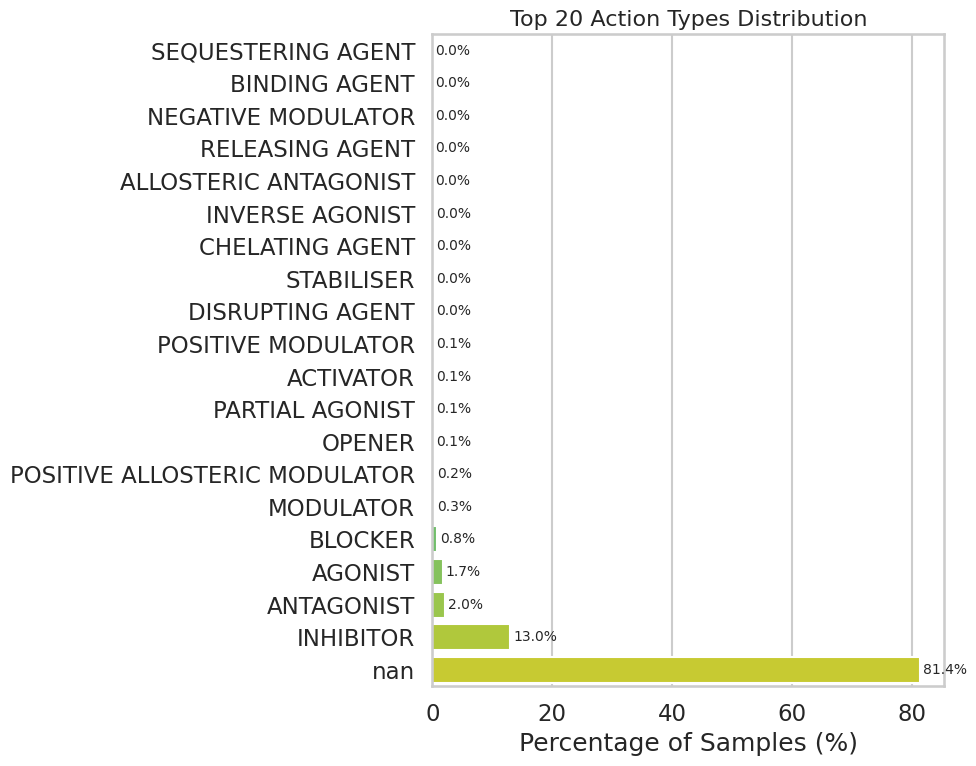

/tmp/ipykernel_2422488/827742590.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")
/tmp/ipykernel_2422488/827742590.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


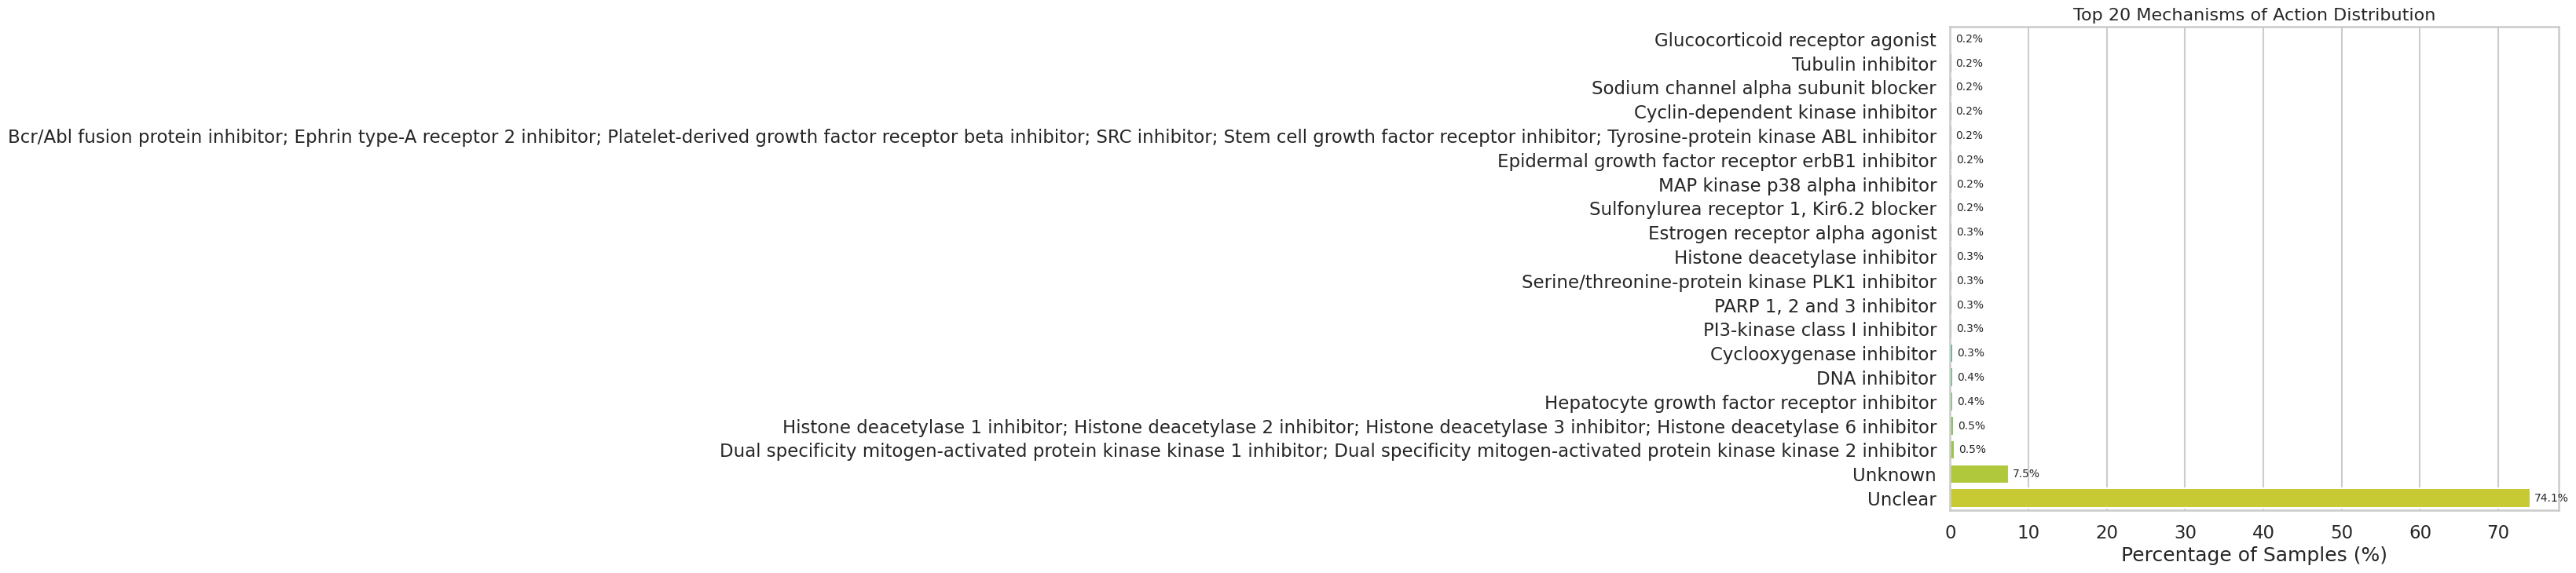

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean Seaborn style
sns.set(style="whitegrid", context="talk")  # larger fonts, clean background

# --- Prepare action_type ---
action_series = (
    adata.obs["action_type"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.split(";")  # split multi-labels
    .explode()
    .str.strip()
)

# --- Prepare mechanism_of_action ---
moa_series = adata.obs["mechanism_of_action"].dropna().astype(str)

# --- Function to plot top N categories ---
def plot_top_categories(series, title, top_n=20, figsize=(10,8)):
    counts = series.value_counts(normalize=True) * 100  # convert to %
    top_counts = counts.head(top_n).sort_values()      # top N sorted ascending for horizontal bar
    
    plt.figure(figsize=figsize)
    sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")
    
    # Annotate bars with percentages
    for i, v in enumerate(top_counts.values):
        plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=10)
    
    plt.xlabel("Percentage of Samples (%)")
    plt.ylabel("")
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# --- Plot top 20 action types ---
plot_top_categories(action_series, "Top 20 Action Types Distribution", top_n=20)

# --- Plot top 20 mechanisms of action ---
plot_top_categories(moa_series, "Top 20 Mechanisms of Action Distribution", top_n=20)

In [20]:
import numpy as np

# Define condition for controls
control_mask = (adata.obs['pert_type'] == 'ctl_vehicle') & \
               (adata.obs['pert_dose'] == 0.1) & \
               (adata.obs['pert_dose_unit'] == '%')

# Replace dose and unit with -666
adata.obs.loc[control_mask, 'pert_dose'] = -666
adata.obs.loc[control_mask, 'pert_dose_unit'] = '-666'

# Check how many were replaced
print("Number of control rows updated:", control_mask.sum())
print(adata.obs.loc[control_mask, ['pert_dose', 'pert_dose_unit']].head())

Number of control rows updated: 30669
        pert_dose pert_dose_unit
333380     -666.0           -666
333382     -666.0           -666
333384     -666.0           -666
333386     -666.0           -666
333388     -666.0           -666


In [21]:
# Unique dose units
unique_dose_units = adata.obs['pert_dose_unit'].unique()
print("Unique pert_dose_unit values:", unique_dose_units)

Unique pert_dose_unit values: ['-666', 'µM']
Categories (3, object): ['%', '-666', 'µM']


In [22]:
# Remove unused categories
if hasattr(adata.obs['pert_dose_unit'], 'cat'):
    adata.obs['pert_dose_unit'] = adata.obs['pert_dose_unit'].cat.remove_unused_categories()

# Check again
print("Unique pert_dose_unit values:", adata.obs['pert_dose_unit'].unique())
print("Categories:", adata.obs['pert_dose_unit'].dtype)

Unique pert_dose_unit values: ['-666', 'µM']
Categories (2, object): ['-666', 'µM']
Categories: category


In [25]:
import anndata
import pandas as pd

# Load dataset
adata = anndata.read_h5ad("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_chembl_moa_clean.h5ad")

# Make DataFrame of action_type column
df = adata.obs[['action_type']].copy()

# Ensure all entries are strings
df['action_type'] = df['action_type'].astype(str)

# Step 1: Keep only single-action rows (no ';') and ignore 'nan'
single_rows = df[~df['action_type'].str.contains(';') & (df['action_type'] != 'nan')]

# Step 2: Count occurrences of each single action type
single_counts = single_rows['action_type'].value_counts()

# Step 3: Calculate percentage relative to all single-action rows
percent_single = (single_counts / single_counts.sum()) * 100

# Sort descending
percent_single = percent_single.sort_values(ascending=False)

print("Percentage of single-action types:")
print(percent_single)

Percentage of single-action types:
action_type
INHIBITOR                        72.366941
ANTAGONIST                        9.380679
AGONIST                           9.046949
BLOCKER                           3.893336
MODULATOR                         1.454457
POSITIVE ALLOSTERIC MODULATOR     1.260818
OPENER                            0.598226
PARTIAL AGONIST                   0.404587
ACTIVATOR                         0.342925
DISRUPTING AGENT                  0.252596
STABILISER                        0.233665
CHELATING AGENT                   0.194721
POSITIVE MODULATOR                0.153613
ALLOSTERIC ANTAGONIST             0.118996
RELEASING AGENT                   0.111965
NEGATIVE MODULATOR                0.068152
INVERSE AGONIST                   0.065448
BINDING AGENT                     0.051926
Name: count, dtype: float64


In [26]:
import anndata
import pandas as pd

# Load your dataset
adata = anndata.read_h5ad("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/Level3_twophase_with_chembl_moa_clean.h5ad")

# Copy action_type column
df = adata.obs[['action_type']].copy()

# Ensure all entries are strings
df['action_type'] = df['action_type'].astype(str)

# Step 1: Calculate single-action percentages
single_rows = df[~df['action_type'].str.contains(';') & (df['action_type'] != 'nan')]
single_counts = single_rows['action_type'].value_counts()
percent_single = (single_counts / single_counts.sum()) * 100

# Step 2: Function to keep the highest single-percentage type in multi-action rows
def keep_highest_single(row):
    if ';' not in row or row == 'nan':
        return row  # keep single-action or NaN
    types = [t.strip() for t in row.split(';')]
    # Pick the type with highest single % (default 0 if missing)
    best_type = max(types, key=lambda t: percent_single.get(t, 0))
    return best_type

# Step 3: Apply function to the column
df['action_type_filtered'] = df['action_type'].apply(keep_highest_single)

# Step 4: Update your adata.obs (optional)
adata.obs['action_type_filtered'] = df['action_type_filtered']

# Check a few examples
print(df.head(10))

  action_type action_type_filtered
0         nan                  nan
1         nan                  nan
2         nan                  nan
3         nan                  nan
4         nan                  nan
5         nan                  nan
6         nan                  nan
7         nan                  nan
8         nan                  nan
9         nan                  nan


In [27]:
# Get unique filtered action types
unique_filtered = adata.obs['action_type_filtered'].unique()
print(unique_filtered)

['nan' 'INHIBITOR' 'ANTAGONIST' 'AGONIST' 'POSITIVE ALLOSTERIC MODULATOR'
 'MODULATOR' 'BLOCKER' 'ACTIVATOR' 'STABILISER' 'CHELATING AGENT'
 'PARTIAL AGONIST' 'INVERSE AGONIST' 'OPENER' 'NEGATIVE MODULATOR'
 'DISRUPTING AGENT' 'POSITIVE MODULATOR' 'ALLOSTERIC ANTAGONIST'
 'RELEASING AGENT' 'BINDING AGENT']


In [29]:
# Randomly sample 10 rows
random_sample = adata.obs[['action_type', 'action_type_filtered']].sample(n=30, random_state=42)
print(random_sample)

                   action_type action_type_filtered
439502                     nan                  nan
899164               INHIBITOR            INHIBITOR
1017872                    nan                  nan
319772                     nan                  nan
613465                 AGONIST              AGONIST
624207                     nan                  nan
262705                     nan                  nan
690812                     nan                  nan
819894                     nan                  nan
361468                     nan                  nan
196298                 AGONIST              AGONIST
806933                     nan                  nan
112368   ANTAGONIST; INHIBITOR            INHIBITOR
890630               INHIBITOR            INHIBITOR
673196                     nan                  nan
909493                     nan                  nan
755956                     nan                  nan
697873                     nan                  nan
789864      

In [31]:
# Show 10 random examples with original and filtered columns
example_moa = adata.obs[['action_type_filtered', 'mechanism_of_action']].sample(10, random_state=42)

print(example_moa)

        action_type_filtered  \
439502                   nan   
899164             INHIBITOR   
1017872                  nan   
319772                   nan   
613465               AGONIST   
624207                   nan   
262705                   nan   
690812                   nan   
819894                   nan   
361468                   nan   

                                       mechanism_of_action  
439502                                             Unclear  
899164   Dual specificity mitogen-activated protein kin...  
1017872                                            Unclear  
319772                                             Unknown  
613465                     Glucocorticoid receptor agonist  
624207                                             Unclear  
262705                                             Unclear  
690812                                             Unclear  
819894                                             Unclear  
361468                               

In [32]:
# Function to keep MoA if it contains the action_type substring
def filter_moa_substring(row):
    moa = row['mechanism_of_action']
    action = row['action_type_filtered']
    
    if pd.isna(moa) or action == 'nan' or pd.isna(action):
        return moa  # keep original if NaN
    
    # Split multi-mechanisms if separated by ';'
    moa_list = [m.strip() for m in moa.split(';')]
    
    # Keep mechanisms containing the action_type substring (case-insensitive)
    filtered = [m for m in moa_list if action.upper() in m.upper()]
    
    return '; '.join(filtered) if filtered else pd.NA

# Apply to the dataset
adata.obs['mechanism_of_action_filtered'] = adata.obs.apply(filter_moa_substring, axis=1)

# Check a few examples
print(adata.obs[['action_type_filtered', 'mechanism_of_action', 'mechanism_of_action_filtered']].sample(10, random_state=42))

        action_type_filtered  \
439502                   nan   
899164             INHIBITOR   
1017872                  nan   
319772                   nan   
613465               AGONIST   
624207                   nan   
262705                   nan   
690812                   nan   
819894                   nan   
361468                   nan   

                                       mechanism_of_action  \
439502                                             Unclear   
899164   Dual specificity mitogen-activated protein kin...   
1017872                                            Unclear   
319772                                             Unknown   
613465                     Glucocorticoid receptor agonist   
624207                                             Unclear   
262705                                             Unclear   
690812                                             Unclear   
819894                                             Unclear   
361468                     

In [34]:
# Show the row(s) where pert_iname is topiramate
topiramate_row = adata.obs[adata.obs['pert_iname'].str.lower() == 'topiramate']
print(topiramate_row[['pert_iname','mechanism_of_action_filtered']])

        pert_iname                       mechanism_of_action_filtered
289     topiramate  Carbonic anhydrase II inhibitor; Carbonic anhy...
290     topiramate  Carbonic anhydrase II inhibitor; Carbonic anhy...
291     topiramate  Carbonic anhydrase II inhibitor; Carbonic anhy...
292     topiramate  Carbonic anhydrase II inhibitor; Carbonic anhy...
293     topiramate  Carbonic anhydrase II inhibitor; Carbonic anhy...
...            ...                                                ...
741428  topiramate  Carbonic anhydrase II inhibitor; Carbonic anhy...
741429  topiramate  Carbonic anhydrase II inhibitor; Carbonic anhy...
741430  topiramate  Carbonic anhydrase II inhibitor; Carbonic anhy...
744388  topiramate  Carbonic anhydrase II inhibitor; Carbonic anhy...
744389  topiramate  Carbonic anhydrase II inhibitor; Carbonic anhy...

[174 rows x 2 columns]


In [35]:
# Filter for topiramate
topiramate_row = adata.obs[adata.obs['pert_iname'].str.lower() == 'topiramate']

# Show only the filtered mechanism column
print(topiramate_row['mechanism_of_action_filtered'].to_list())

['Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhy

In [36]:
# Count each filtered action type
counts = adata.obs['action_type_filtered'].value_counts(dropna=False)

# Calculate percentage
percent = (counts / counts.sum()) * 100

# Sort descending
percent = percent.sort_values(ascending=False)

print(percent)

action_type_filtered
nan                              81.767025
INHIBITOR                        13.056717
ANTAGONIST                        1.883808
AGONIST                           1.611115
BLOCKER                           0.735337
MODULATOR                         0.259015
POSITIVE ALLOSTERIC MODULATOR     0.224531
OPENER                            0.106534
PARTIAL AGONIST                   0.072050
ACTIVATOR                         0.061069
DISRUPTING AGENT                  0.044983
STABILISER                        0.041612
CHELATING AGENT                   0.034677
POSITIVE MODULATOR                0.027356
ALLOSTERIC ANTAGONIST             0.021191
RELEASING AGENT                   0.019939
NEGATIVE MODULATOR                0.012137
INVERSE AGONIST                   0.011655
BINDING AGENT                     0.009247
Name: count, dtype: float64


In [40]:
# Exclude the string 'nan'
valid_counts = adata.obs[adata.obs['action_type_filtered'] != 'nan']['action_type_filtered'].value_counts()

# Calculate percentage over only valid rows
percent_valid = (valid_counts / valid_counts.sum()) * 100

# Sort descending
percent_valid = percent_valid.sort_values(ascending=False)

print(percent_valid)

action_type_filtered
INHIBITOR                        71.610456
ANTAGONIST                       10.331875
AGONIST                           8.836271
BLOCKER                           4.033008
MODULATOR                         1.420587
POSITIVE ALLOSTERIC MODULATOR     1.231457
OPENER                            0.584295
PARTIAL AGONIST                   0.395165
ACTIVATOR                         0.334939
DISRUPTING AGENT                  0.246714
STABILISER                        0.228224
CHELATING AGENT                   0.190186
POSITIVE MODULATOR                0.150036
ALLOSTERIC ANTAGONIST             0.116225
RELEASING AGENT                   0.109357
NEGATIVE MODULATOR                0.066565
INVERSE AGONIST                   0.063924
BINDING AGENT                     0.050716
Name: count, dtype: float64


/tmp/ipykernel_2422488/4234766817.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2422488/4234766817.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)


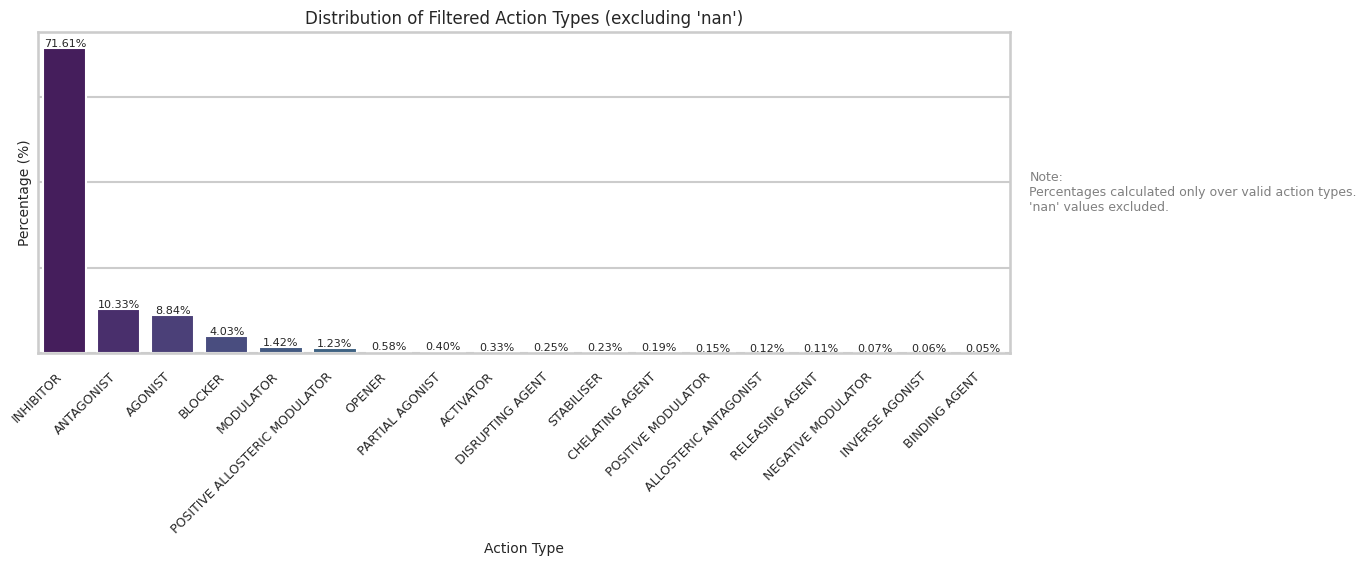

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your percentage Series without 'nan'
percent_valid = pd.Series({
    'INHIBITOR': 71.610456,
    'ANTAGONIST': 10.331875,
    'AGONIST': 8.836271,
    'BLOCKER': 4.033008,
    'MODULATOR': 1.420587,
    'POSITIVE ALLOSTERIC MODULATOR': 1.231457,
    'OPENER': 0.584295,
    'PARTIAL AGONIST': 0.395165,
    'ACTIVATOR': 0.334939,
    'DISRUPTING AGENT': 0.246714,
    'STABILISER': 0.228224,
    'CHELATING AGENT': 0.190186,
    'POSITIVE MODULATOR': 0.150036,
    'ALLOSTERIC ANTAGONIST': 0.116225,
    'RELEASING AGENT': 0.109357,
    'NEGATIVE MODULATOR': 0.066565,
    'INVERSE AGONIST': 0.063924,
    'BINDING AGENT': 0.050716
})

# Sort descending
percent_valid = percent_valid.sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(14,6))

# Bar plot
sns.barplot(
    x=percent_valid.index,
    y=percent_valid.values,
    palette="viridis",
    ax=ax
)

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

# Hide ONLY Y-axis numbers (keep axis and ticks)
ax.tick_params(axis='y', labelleft=False)

# Axis labels and title
ax.set_xlabel("Action Type", fontsize=10)
ax.set_ylabel("Percentage (%)", fontsize=10)
ax.set_title("Distribution of Filtered Action Types (excluding 'nan')", fontsize=12)

# Add percentage labels on bars
for i, v in enumerate(percent_valid.values):
    ax.text(i, v + 0.2, f"{v:.2f}%", ha='center', fontsize=8)

# Add note on the right
ax.text(
    1.02,
    0.5,
    "Note:\nPercentages calculated only over valid action types.\n'nan' values excluded.",
    transform=ax.transAxes,
    fontsize=9,
    color='gray',
    va='center',
    ha='left'
)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig("action_type_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig("action_type_distribution.pdf", dpi=300, bbox_inches="tight")

# Show plot
plt.show()

In [53]:
import pandas as pd

# Suppose your dataframe is df
unique_mechanisms = df['mechanism_of_action_filtered'].value_counts()
print(unique_mechanisms)

KeyError: 'mechanism_of_action_filtered'

In [54]:
# Check the column names first
print(adata.obs.columns)


Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id',
       'mechanism_of_action', 'action_type', 'action_type_filtered',
       'mechanism_of_action_filtered'],
      dtype='object')


In [55]:
# Count unique mechanisms in adata.obs
unique_mechanisms = adata.obs['mechanism_of_action_filtered'].value_counts()
print(unique_mechanisms)

mechanism_of_action_filtered
Unclear                                                                                                                                       768854
Unknown                                                                                                                                        77771
Dual specificity mitogen-activated protein kinase kinase 1 inhibitor; Dual specificity mitogen-activated protein kinase kinase 2 inhibitor      5441
Histone deacetylase 1 inhibitor; Histone deacetylase 2 inhibitor; Histone deacetylase 3 inhibitor; Histone deacetylase 6 inhibitor              4768
Hepatocyte growth factor receptor inhibitor                                                                                                     4023
                                                                                                                                               ...  
70S ribosome inhibitor                                                       

In [56]:
import re

def generalize_moa(row):
    moa = row['mechanism_of_action_filtered']
    
    # Leave Unclear/Unknown untouched
    if moa in ['Unclear', 'Unknown'] or pd.isna(moa):
        return moa
    
    # Split multiple mechanisms
    moa_list = [m.strip() for m in moa.split(';')]
    
    generalized = []
    for m in moa_list:
        # Remove numbers, Roman numerals, letters that indicate subtypes
        m_gen = re.sub(r'\b([IVX0-9A-Z]+)\b', '', m).strip()
        # Remove extra spaces
        m_gen = re.sub(r'\s+', ' ', m_gen)
        generalized.append(m_gen)
    
    # Keep only unique base mechanisms
    return '; '.join(sorted(set(generalized)))

# Apply to your dataset
adata.obs['mechanism_of_action_generalized'] = adata.obs.apply(generalize_moa, axis=1)

In [58]:
# Count unique mechanisms in adata.obs
unique_mechanisms = adata.obs['mechanism_of_action_generalized'].value_counts()
print(unique_mechanisms)

mechanism_of_action_generalized
Unclear                                                                        768854
Unknown                                                                         77771
Histone deacetylase inhibitor                                                    8385
Serine/threonine-protein kinase inhibitor                                        6176
Dual specificity mitogen-activated protein kinase kinase inhibitor               5441
                                                                                ...  
ribosome inhibitor                                                                 10
Plasminogen inhibitor                                                              10
Adrenergic receptor alpha agonist                                                  10
Intermediate conductance calcium-activated potassium channel protein opener        10
Serine-protein kinase inhibitor                                                     6
Name: count, Length: 4

In [64]:
import pandas as pd

# Filter valid entries
valid_moa = adata.obs.loc[
    (~adata.obs['mechanism_of_action_generalized'].isin(['Unknown', 'Unclear', 'nan'])) &
    (adata.obs['mechanism_of_action_generalized'].notna()),
    ['mechanism_of_action_generalized', 'mechanism_of_action_filtered']
]

# Count top 20 generalized mechanisms
top20_counts = valid_moa['mechanism_of_action_generalized'].value_counts().head(20)

# Merge with the original filtered MoA for reference
top20_moa = valid_moa[valid_moa['mechanism_of_action_generalized'].isin(top20_counts.index)]

# Aggregate all original filtered MoAs per generalized mechanism
top20_summary = top20_moa.groupby('mechanism_of_action_generalized')['mechanism_of_action_filtered'] \
                          .apply(lambda x: '; '.join(sorted(set(x)))) \
                          .reset_index()

# Add count column
top20_summary['count'] = top20_summary['mechanism_of_action_generalized'].map(top20_counts)

# Sort by count descending
top20_summary = top20_summary.sort_values('count', ascending=False)

# Show top 20 table
print(top20_summary)

                      mechanism_of_action_generalized  \
11                      Histone deacetylase inhibitor   
14          Serine/threonine-protein kinase inhibitor   
6   Dual specificity mitogen-activated protein kin...   
3                   Cyclin-dependent kinase inhibitor   
9         Hepatocyte growth factor receptor inhibitor   
18                                          inhibitor   
17                  Tyrosine-protein kinase inhibitor   
4                            Cyclooxygenase inhibitor   
1                             -kinase class inhibitor   
0                                     , and inhibitor   
8                     Estrogen receptor alpha agonist   
13  Serine/threonine-protein kinase Aurora- inhibitor   
16              Sulfonylurea receptor , Kir6. blocker   
15               Sodium channel alpha subunit blocker   
12                        Phosphodiesterase inhibitor   
19                         kinase p38 alpha inhibitor   
7    Epidermal growth factor re

In [65]:
import re

def clean_moa_generalized(moa):
    if pd.isna(moa):
        return moa
    # Lowercase, strip spaces
    moa = moa.strip()
    # Remove stray punctuation at start/end
    moa = re.sub(r'^[,;\-\s]+|[,;\-\s]+$', '', moa)
    # Replace multiple spaces with single space
    moa = re.sub(r'\s+', ' ', moa)
    # Remove strings like ", and inhibitor", " -kinase class inhibitor" if they are incomplete
    # Optional: you can tweak this depending on your dataset
    return moa

adata.obs['mechanism_of_action_generalized'] = adata.obs['mechanism_of_action_generalized'].apply(clean_moa_generalized)

In [66]:
valid_moa = adata.obs.loc[
    (~adata.obs['mechanism_of_action_generalized'].isin(['Unknown', 'Unclear', 'nan'])) &
    (adata.obs['mechanism_of_action_generalized'].notna()),
    ['mechanism_of_action_generalized', 'mechanism_of_action_filtered']
]

In [67]:
# Count top 20
top20_counts = valid_moa['mechanism_of_action_generalized'].value_counts().head(20)

# Keep only top 20
top20_moa = valid_moa[valid_moa['mechanism_of_action_generalized'].isin(top20_counts.index)]

# Aggregate original filtered MoAs
top20_summary = top20_moa.groupby('mechanism_of_action_generalized')['mechanism_of_action_filtered'] \
                          .apply(lambda x: '; '.join(sorted(set(x)))) \
                          .reset_index()

# Add count
top20_summary['count'] = top20_summary['mechanism_of_action_generalized'].map(top20_counts)

# Sort by count descending
top20_summary = top20_summary.sort_values('count', ascending=False)

# Display
print(top20_summary)

                      mechanism_of_action_generalized  \
9                       Histone deacetylase inhibitor   
12          Serine/threonine-protein kinase inhibitor   
4   Dual specificity mitogen-activated protein kin...   
1                   Cyclin-dependent kinase inhibitor   
7         Hepatocyte growth factor receptor inhibitor   
17                                          inhibitor   
15                  Tyrosine-protein kinase inhibitor   
2                            Cyclooxygenase inhibitor   
18                             kinase class inhibitor   
16                                      and inhibitor   
6                     Estrogen receptor alpha agonist   
11  Serine/threonine-protein kinase Aurora- inhibitor   
14              Sulfonylurea receptor , Kir6. blocker   
10                        Phosphodiesterase inhibitor   
13               Sodium channel alpha subunit blocker   
19                         kinase p38 alpha inhibitor   
5    Epidermal growth factor re

In [68]:
adata.obs.columns

Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id',
       'mechanism_of_action', 'action_type', 'action_type_filtered',
       'mechanism_of_action_filtered', 'mechanism_of_action_generalized'],
      dtype='object')

In [69]:
# Delete the column
adata.obs.drop(columns=['mechanism_of_action_generalized'], inplace=True)

# Check columns to confirm
print(adata.obs.columns)

Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id',
       'mechanism_of_action', 'action_type', 'action_type_filtered',
       'mechanism_of_action_filtered'],
      dtype='object')


In [70]:
# Count how many times each unique mechanism appears
unique_mechanisms = adata.obs['mechanism_of_action_filtered'].value_counts()
print(unique_mechanisms.head(50))  # show top 50 most common

mechanism_of_action_filtered
Unclear                                                                                                                                                                                                                           768854
Unknown                                                                                                                                                                                                                            77771
Dual specificity mitogen-activated protein kinase kinase 1 inhibitor; Dual specificity mitogen-activated protein kinase kinase 2 inhibitor                                                                                          5441
Histone deacetylase 1 inhibitor; Histone deacetylase 2 inhibitor; Histone deacetylase 3 inhibitor; Histone deacetylase 6 inhibitor                                                                                                  4768
Hepatocyte growth factor receptor inhib

In [72]:
# Filter rows with multiple mechanisms
multi_moa_rows = adata.obs[adata.obs['mechanism_of_action_filtered'].str.contains(';', na=False)]

# Get unique entries
unique_multi_moa = multi_moa_rows['mechanism_of_action_filtered'].unique()

# Convert to list (optional)
unique_multi_moa_list = list(unique_multi_moa)

# Show shape / number of unique entries
print(f"Number of unique multi-mechanism entries: {len(unique_multi_moa_list)}")

# Preview first 20
print(unique_multi_moa_list[:20])

Number of unique multi-mechanism entries: 142
['Cytochrome P450 11A1 inhibitor; Cytochrome P450 19A1 inhibitor', 'Dopamine D2 receptor antagonist; Dopamine D3 receptor antagonist; Serotonin 2a (5-HT2a) receptor antagonist', 'PI3-kinase p110-alpha subunit inhibitor; Serine/threonine-protein kinase mTOR inhibitor', '70S ribosome inhibitor; Fatty acid synthase inhibitor', 'Carbonic anhydrase II inhibitor; Carbonic anhydrase IV inhibitor', 'Peroxisome proliferator-activated receptor alpha agonist; Peroxisome proliferator-activated receptor gamma agonist', 'Phosphodiesterase 10A inhibitor; Phosphodiesterase 3A inhibitor; Phosphodiesterase 4 inhibitor; Phosphodiesterase 5A inhibitor', 'Discoidin domain-containing receptor 2 inhibitor; Ephrin type-A receptor 2 inhibitor; Fibroblast growth factor receptor 1 inhibitor; Fibroblast growth factor receptor 2 inhibitor; MAP kinase p38 beta inhibitor; Nerve growth factor receptor Trk-A inhibitor; Platelet-derived growth factor receptor inhibitor; Ser

In [73]:
# Filter rows with multiple mechanisms
multi_moa_rows = adata.obs[adata.obs['mechanism_of_action_filtered'].str.contains(';', na=False)]

# Get unique entries
unique_multi_moa = multi_moa_rows['mechanism_of_action_filtered'].unique()

# Count
num_unique_multi_moa = len(unique_multi_moa)
print(f"Number of unique multi-mechanism entries: {num_unique_multi_moa}")

Number of unique multi-mechanism entries: 142


In [ ]:
import pandas as pd

# Step 1: Filter valid mechanisms
valid_moa = adata.obs.loc[
    (~adata.obs['mechanism_of_action_filtered'].isin(['Unknown', 'Unclear', 'nan'])) &
    (adata.obs['mechanism_of_action_filtered'].notna()),
    'mechanism_of_action_filtered'
]

# Step 2: Split multi-mechanism rows into individual mechanisms
all_mechanisms = valid_moa.str.split(';').explode().str.strip()

# Step 3: Count occurrences of each mechanism
mechanism_counts = all_mechanisms.value_counts()

# Step 4: Calculate percentage
mechanism_percent = 100 * mechanism_counts / mechanism_counts.sum()

# Step 5: Combine into a DataFrame
mechanism_df = pd.DataFrame({
    'mechanism_of_action': mechanism_counts.index,
    'count': mechanism_counts.values,
    'percentage': mechanism_percent.values
})

# Step 6: Reset index
mechanism_df = mechanism_df.reset_index(drop=True)

# Preview first 20
print(mechanism_df.head(20))



                                  mechanism_of_action  count  percentage
0          Stem cell growth factor receptor inhibitor   8284    2.645226
1         Hepatocyte growth factor receptor inhibitor   6453    2.060555
2                                       DNA inhibitor   6447    2.058639
3               Tyrosine-protein kinase ABL inhibitor   5780    1.845655
4   Dual specificity mitogen-activated protein kin...   5441    1.737406
5   Dual specificity mitogen-activated protein kin...   5441    1.737406
6     Tyrosine-protein kinase receptor FLT3 inhibitor   5276    1.684719
7                     Histone deacetylase 6 inhibitor   5244    1.674501
8   Vascular endothelial growth factor receptor in...   5207    1.662686
9                     Histone deacetylase 3 inhibitor   5185    1.655661
10                    Histone deacetylase 2 inhibitor   5185    1.655661
11                    Histone deacetylase 1 inhibitor   5185    1.655661
12   Epidermal growth factor receptor erbB1 inhibit

In [79]:
import pandas as pd

# Step 1: Take all mechanisms (no filtering)
all_moa_raw = adata.obs['mechanism_of_action_filtered'].dropna()  # keep NaNs out for counting

# Step 2: Split multi-mechanism rows into individual mechanisms
all_mechanisms = all_moa_raw.str.split(';').explode().str.strip()

# Step 3: Count occurrences of each mechanism
mechanism_counts = all_mechanisms.value_counts()

# Step 4: Calculate percentage
mechanism_percent = 100 * mechanism_counts / mechanism_counts.sum()

# Step 5: Combine into a DataFrame
mechanism_df = pd.DataFrame({
    'mechanism_of_action': mechanism_counts.index,
    'count': mechanism_counts.values,
    'percentage': mechanism_percent.values
}).reset_index(drop=True)

# Preview first 20
print(mechanism_df.head(20))



                                  mechanism_of_action   count  percentage
0                                             Unclear  768854   66.292347
1                                             Unknown   77771    6.705593
2          Stem cell growth factor receptor inhibitor    8284    0.714265
3         Hepatocyte growth factor receptor inhibitor    6453    0.556392
4                                       DNA inhibitor    6447    0.555875
5               Tyrosine-protein kinase ABL inhibitor    5780    0.498365
6   Dual specificity mitogen-activated protein kin...    5441    0.469135
7   Dual specificity mitogen-activated protein kin...    5441    0.469135
8     Tyrosine-protein kinase receptor FLT3 inhibitor    5276    0.454909
9                     Histone deacetylase 6 inhibitor    5244    0.452150
10  Vascular endothelial growth factor receptor in...    5207    0.448959
11                    Histone deacetylase 1 inhibitor    5185    0.447063
12                    Histone deacetyl

In [80]:
adata_path = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/final_file_for_split.h5ad"
adata.write_h5ad(adata_path)
print(f"AnnData saved to: {adata_path}")

AnnData saved to: /sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/final_file_for_split.h5ad


In [81]:
import scanpy as sc
import os

# Path to your final cleaned dataset
data_path = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/final_file_for_split.h5ad"

# Check if the file exists first
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at {data_path}")

# Load dataset
adata = sc.read_h5ad(data_path)

# Inspect basic info
print("Dataset loaded successfully!")
print("Total samples:", adata.n_obs)
print("Columns:", adata.obs.columns)
print("Some MoA examples:", adata.obs['mechanism_of_action_filtered'].unique()[:10])

Dataset loaded successfully!
Total samples: 1038163
Columns: Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id',
       'mechanism_of_action', 'action_type', 'action_type_filtered',
       'mechanism_of_action_filtered'],
      dtype='object')
Some MoA examples: ['Unknown', 'Unclear', 'Helicase/primase inhibitor', 'Cytochrome P450 11A1 inhibitor; Cytochrome P4..., 'Cyclooxygenase inhibitor', 'Dopamine D2 receptor antagonist; Dopamine D3 ..., 'Toll-like receptor 7 agonist', 'RNA-directed RNA polymerase inhibitor', 'anion channel positive allosteric modulator', 'PI3-kinase p110-alpha subunit inhibitor; Seri...]
Categories (485, object): ['1-phosphatidylinositol 3-phosphate 5-kinase i..., '3',5'-cyclic phosphodiesterase inhibitor', '3',5'-cyclic phosphodiesterase inhibitor; Equ..., '11-beta-hydroxysteroid dehydrog

In [83]:
# -----------------------------
# Step 2: Create clean stratification key (strings)
# -----------------------------
# Convert MoA column to string
adata.obs['mechanism_of_action_filtered'] = adata.obs['mechanism_of_action_filtered'].astype(str)

# Fill any remaining missing or blank values
adata.obs['mechanism_of_action_filtered'] = adata.obs['mechanism_of_action_filtered'].replace(['nan',''], 'Missing_MoA')

# Convert cell_id and pert_dose to strings and fill missing
adata.obs['cell_id'] = adata.obs['cell_id'].astype(str).replace(['nan',''], 'Unknown_Cell')
adata.obs['pert_dose'] = adata.obs['pert_dose'].astype(str).replace(['nan',''], 'Missing_Dose')

# Create composite stratification key: MoA + cell line + dose
adata.obs['strat_key'] = (
    adata.obs['mechanism_of_action_filtered'] + "__" +
    adata.obs['cell_id'] + "__" +
    adata.obs['pert_dose']
)

# Inspect first few keys
print("Example stratification keys:")
print(adata.obs['strat_key'].head(10))

Example stratification keys:
0    Unknown__A375__-666.0
1    Unknown__A375__-666.0
2    Unknown__A375__-666.0
3    Unknown__A375__-666.0
4      Unclear__A375__10.0
5      Unclear__A375__3.33
6      Unclear__A375__1.11
7      Unclear__A375__0.37
8      Unclear__A375__0.12
9      Unclear__A375__0.04
Name: strat_key, dtype: object


In [84]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

# -----------------------------
# Step 3: Drug-blind stratified 5-fold split
# -----------------------------

# Get unique drugs and their strat key (pick first occurrence per drug)
drug_df = adata.obs[['pert_id', 'strat_key']].drop_duplicates(subset='pert_id')

# Prepare array to store fold assignments
n_splits = 5
folds = np.zeros(len(drug_df), dtype=int)

# Stratified split on strat_key
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
for fold_number, (_, val_idx) in enumerate(skf.split(drug_df, drug_df['strat_key'])):
    folds[val_idx] = fold_number

drug_df['fold'] = folds

# Map fold back to full dataset (drug-blind)
adata.obs = adata.obs.merge(
    drug_df[['pert_id', 'fold']], 
    on='pert_id', 
    how='left'
)

# Check distribution
print(adata.obs[['pert_id','fold','strat_key']].head(10))
print("Fold counts:\n", adata.obs['fold'].value_counts())

/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


         pert_id  fold              strat_key
0           DMSO     0  Unknown__A375__-666.0
1           DMSO     0  Unknown__A375__-666.0
2           DMSO     0  Unknown__A375__-666.0
3           DMSO     0  Unknown__A375__-666.0
4  BRD-K25114078     2    Unclear__A375__10.0
5  BRD-K25114078     2    Unclear__A375__3.33
6  BRD-K25114078     2    Unclear__A375__1.11
7  BRD-K25114078     2    Unclear__A375__0.37
8  BRD-K25114078     2    Unclear__A375__0.12
9  BRD-K25114078     2    Unclear__A375__0.04
Fold counts:
 fold
0    271535
1    200187
4    195637
2    186488
3    184316
Name: count, dtype: int64


In [85]:
# -----------------------------
# Step 4: Save dataset with fold assignments
# -----------------------------

output_path = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/final_file_for_split_with_folds.h5ad"

adata.write(output_path)

print("Dataset saved successfully!")
print("Saved to:", output_path)

Dataset saved successfully!
Saved to: /sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/final_file_for_split_with_folds.h5ad


In [86]:
# -----------------------------
# Step 5: Create train/test sets
# -----------------------------

test_fold = 0

train_adata = adata[adata.obs['fold'] != test_fold].copy()
test_adata  = adata[adata.obs['fold'] == test_fold].copy()

print("Train samples:", train_adata.n_obs)
print("Test samples:", test_adata.n_obs)

Train samples: 766628
Test samples: 271535


In [87]:
train_drugs = set(train_adata.obs['pert_id'])
test_drugs = set(test_adata.obs['pert_id'])

overlap = train_drugs.intersection(test_drugs)

print("Number of shared drugs:", len(overlap))

Number of shared drugs: 0


In [88]:
# -----------------------------
# Step 5: Save train/test datasets
# -----------------------------

train_path = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/train_data.h5ad"
test_path  = "/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/test_data.h5ad"

train_adata.write(train_path)
test_adata.write(test_path)

print("Train dataset saved to:", train_path)
print("Test dataset saved to:", test_path)

Train dataset saved to: /sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/train_data.h5ad
Test dataset saved to: /sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/test_data.h5ad


In [89]:
# MoA distribution
train_moa = train_adata.obs['mechanism_of_action_filtered'].value_counts(normalize=True)
test_moa  = test_adata.obs['mechanism_of_action_filtered'].value_counts(normalize=True)

print("Train MoA distribution:")
print(train_moa.head(10))

print("\nTest MoA distribution:")
print(test_moa.head(10))

Train MoA distribution:
mechanism_of_action_filtered
Unclear                                                                                                                                       0.794851
Histone deacetylase 1 inhibitor; Histone deacetylase 2 inhibitor; Histone deacetylase 3 inhibitor; Histone deacetylase 6 inhibitor            0.006219
Dual specificity mitogen-activated protein kinase kinase 1 inhibitor; Dual specificity mitogen-activated protein kinase kinase 2 inhibitor    0.004996
Unknown                                                                                                                                       0.004728
DNA inhibitor                                                                                                                                 0.004063
Cyclooxygenase inhibitor                                                                                                                      0.003689
Hepatocyte growth factor receptor inhibit

split by rare and shared biology

In [1]:
import scanpy as sc
import pandas as pd

# Load the dataset
adata = sc.read_h5ad("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/second_phase_combine/final_file_for_split.h5ad")

print(f"Dataset loaded: {adata.shape[0]} samples, {adata.shape[1]} columns")
print(f"Columns: {adata.obs.columns.tolist()}")

Dataset loaded: 1038163 samples, 978 columns
Columns: ['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id', 'mechanism_of_action', 'action_type', 'action_type_filtered', 'mechanism_of_action_filtered']


In [3]:
# Fill missing MoA, cell line, or dose with descriptive labels
# MoA: Unknown for control, Unclear for treated without MoA
# Dose: keep as string for stratification
import pandas as pd

# For mechanism_of_action_filtered
if pd.api.types.is_categorical_dtype(adata.obs['mechanism_of_action_filtered']):
    adata.obs['mechanism_of_action_filtered'] = adata.obs['mechanism_of_action_filtered'].cat.add_categories(['Unknown_MoA', 'Unclear_MoA']).fillna('Unknown_MoA')
else:
    adata.obs['mechanism_of_action_filtered'] = adata.obs['mechanism_of_action_filtered'].fillna('Unknown_MoA')

# For cell_id
if pd.api.types.is_categorical_dtype(adata.obs['cell_id']):
    adata.obs['cell_id'] = adata.obs['cell_id'].cat.add_categories('Unknown_Cell').fillna('Unknown_Cell')
else:
    adata.obs['cell_id'] = adata.obs['cell_id'].fillna('Unknown_Cell')

# For pert_dose
adata.obs['pert_dose'] = adata.obs['pert_dose'].astype(str).fillna('Missing_Dose')

/tmp/ipykernel_606426/818052703.py:7: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs['mechanism_of_action_filtered']):
/tmp/ipykernel_606426/818052703.py:13: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs['cell_id']):


In [4]:
# Stratification key = MoA + Cell line + Dose
adata.obs['strat_key'] = (
    adata.obs['mechanism_of_action_filtered'].astype(str) + "__" +
    adata.obs['cell_id'].astype(str) + "__" +
    adata.obs['pert_dose'].astype(str)
)

# Quick check
print("Some example stratification keys:")
print(adata.obs['strat_key'].sample(10, random_state=42).tolist())

Some example stratification keys:
['Unclear__OV7__10.0', 'Dual specificity mitogen-activated protein kinase kinase 1 inhibitor; Dual specificity mitogen-activated protein kinase kinase 2 inhibitor__MDAMB231__1.0', 'Unclear__VCAP__10.0', 'Unknown__PC3__-666.0', 'Glucocorticoid receptor agonist__HT29__10.0', 'Unclear__MCF7__10.0', 'Unclear__HA1E__0.12', 'Unclear__MCF7__10.0', 'Unclear__A549__5.0', 'Unclear__HT29__10.0']


In [5]:
# Count unique drugs per strat_key
context_stats = adata.obs.groupby('strat_key')['pert_id'].nunique()

# Rare biology: strat_keys with only one drug
rare_biology = context_stats[context_stats == 1].index

# Shared biology: strat_keys with more than one drug
shared_biology = context_stats[context_stats > 1].index

# Quick summary
print(f"Total contexts: {len(context_stats)}")
print(f"Rare biology contexts: {len(rare_biology)}")
print(f"Shared biology contexts: {len(shared_biology)}")

# Count of samples
rare_samples = adata.obs[adata.obs['strat_key'].isin(rare_biology)].shape[0]
shared_samples = adata.obs[adata.obs['strat_key'].isin(shared_biology)].shape[0]

print(f"Rare biology samples: {rare_samples}")
print(f"Shared biology samples: {shared_samples}")

Total contexts: 29865
Rare biology contexts: 22132
Shared biology contexts: 7733
Rare biology samples: 151308
Shared biology samples: 886855


In [6]:
# -----------------------------
# Step 4: Stratified 5-Fold Split for Shared Biology
# Rare biology will be added only to training sets
# -----------------------------

from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd

# 1️⃣ Separate rare and shared biology
rare_df = adata.obs[adata.obs['strat_key'].isin(rare_biology)].copy()
shared_df = adata.obs[adata.obs['strat_key'].isin(shared_biology)].copy()

print(f"Rare biology samples (train only): {rare_df.shape[0]}")
print(f"Shared biology samples (to split): {shared_df.shape[0]}")

# 2️⃣ Initialize StratifiedGroupKFold
n_splits = 5
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 3️⃣ Assign fold numbers for shared biology
shared_df['fold'] = -1  # initialize

for fold_number, (train_idx, test_idx) in enumerate(
    sgkf.split(X=shared_df, 
               y=shared_df['strat_key'], 
               groups=shared_df['pert_id'])):
    shared_df.iloc[test_idx, shared_df.columns.get_loc('fold')] = fold_number

# 4️⃣ Add rare biology samples to fold 0 (train only)
rare_df['fold'] = 0

# 5️⃣ Combine back into one DataFrame
adata.obs = pd.concat([shared_df, rare_df], axis=0)

# 6️⃣ Check fold distribution
fold_counts = adata.obs.groupby('fold').size()
print("Fold distribution (including rare biology in fold 0):")
print(fold_counts)

# 7️⃣ Verify that every test strat_key exists in train
for f in range(n_splits):
    train_keys = set(adata.obs[adata.obs['fold'] != f]['strat_key'].unique())
    test_keys = set(adata.obs[adata.obs['fold'] == f]['strat_key'].unique())
    missing_keys = test_keys - train_keys
    if not missing_keys:
        print(f"✅ Fold {f}: All test strat_keys exist in training set.")
    else:
        print(f"⚠ Fold {f}: {len(missing_keys)} strat_keys missing in training set.")

Rare biology samples (train only): 151308
Shared biology samples (to split): 886855


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/sklearn/model_selection/_split.py:1037: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Fold distribution (including rare biology in fold 0):
fold
0    328679
1    177370
2    177374
3    177369
4    177371
dtype: int64
⚠ Fold 0: 22132 strat_keys missing in training set.
✅ Fold 1: All test strat_keys exist in training set.
✅ Fold 2: All test strat_keys exist in training set.
✅ Fold 3: All test strat_keys exist in training set.
✅ Fold 4: All test strat_keys exist in training set.


second_try_for_splitting


In [1]:
import scanpy as sc

adata = sc.read_h5ad("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/second_phase_combine/final_file_for_split.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 1038163 × 978
    obs: 'dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id', 'mechanism_of_action', 'action_type', 'action_type_filtered', 'mechanism_of_action_filtered'


In [2]:
print(adata.obs.columns)

Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id',
       'mechanism_of_action', 'action_type', 'action_type_filtered',
       'mechanism_of_action_filtered'],
      dtype='object')


In [3]:
adata.obs.head()

,dataset_name,sig_id,pert_id,pert_iname,pert_type,cell_id,pert_idose,pert_itime,condition,canonical_smiles,valid_smiles,pert_dose,pert_dose_unit,inchi_key,chembl_id,mechanism_of_action,action_type,action_type_filtered,mechanism_of_action_filtered
0,GSE70138,REP.A001_A375_24H:A03,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.0,-666,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,CHEMBL504,Unknown,nan,nan,Unknown
1,GSE70138,REP.A001_A375_24H:A04,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.0,-666,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,CHEMBL504,Unknown,nan,nan,Unknown
2,GSE70138,REP.A001_A375_24H:A05,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.0,-666,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,CHEMBL504,Unknown,nan,nan,Unknown
3,GSE70138,REP.A001_A375_24H:A06,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,DMSO,CS(=O)C,True,-666.0,-666,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,CHEMBL504,Unknown,nan,nan,Unknown
4,GSE70138,REP.A001_A375_24H:A07,BRD-K25114078,aminoguanidine,trt_cp,A375,10.0 um,24 h,aminoguanidine,NNC(N)=N,True,10.0,µM,HAMNKKUPIHEESI-UHFFFAOYSA-N,CHEMBL225304,Unclear,nan,nan,Unclear


In [4]:
print("Number of samples:", adata.n_obs)
print("Number of genes:", adata.n_vars)

Number of samples: 1038163
Number of genes: 978


In [5]:
adata.obs["pert_id"].nunique()

18660

In [6]:
adata.obs["pert_id"].value_counts().head()

pert_id
DMSO             73261
BRD-K60230970     6289
BRD-K50691590     5994
BRD-K81418486     4768
BRD-A19500257     3874
Name: count, dtype: int64

In [13]:
adata.obs["mechanism_of_action_filtered"].value_counts(dropna=False).head(20)

mechanism_of_action_filtered
Unclear                                                                                                                                                                                                                           768854
Unknown                                                                                                                                                                                                                            77771
Dual specificity mitogen-activated protein kinase kinase 1 inhibitor; Dual specificity mitogen-activated protein kinase kinase 2 inhibitor                                                                                          5441
Histone deacetylase 1 inhibitor; Histone deacetylase 2 inhibitor; Histone deacetylase 3 inhibitor; Histone deacetylase 6 inhibitor                                                                                                  4768
Hepatocyte growth factor receptor inhib

In [14]:
adata.obs["mechanism_of_action_filtered"].isna().sum()

np.int64(0)

In [9]:
adata.obs["strat_key"] = (
    adata.obs["mechanism_of_action_filtered"].astype(str) + "_" +
    adata.obs["cell_id"].astype(str) + "_" +
    adata.obs["pert_dose"].astype(str)
)

In [10]:
adata.obs["strat_key"].head()

0    Unknown_A375_-666.0
1    Unknown_A375_-666.0
2    Unknown_A375_-666.0
3    Unknown_A375_-666.0
4      Unclear_A375_10.0
Name: strat_key, dtype: object

In [11]:
strat_counts = adata.obs["strat_key"].value_counts()

print(strat_counts.describe())
rare_biology = strat_counts[strat_counts == 1]
print("Number of rare biology groups:", len(rare_biology))

count    29865.000000
mean        34.761862
std        769.612732
min          1.000000
25%          3.000000
50%          3.000000
75%          6.000000
max      62887.000000
Name: count, dtype: float64
Number of rare biology groups: 206


In [12]:
adata.obs[adata.obs["pert_type"] == "ctl_vehicle"]["strat_key"].unique()[:10]

array(['Unknown_A375_-666.0', 'Unknown_HA1E_-666.0',
       'Unknown_HELA_-666.0', 'Unknown_HT29_-666.0',
       'Unknown_MCF7_-666.0', 'Unknown_PC3_-666.0', 'Unknown_YAPC_-666.0',
       'Unknown_ASC_-666.0', 'Unknown_HUES3_-666.0',
       'Unknown_MNEU.E_-666.0'], dtype=object)

In [15]:
strat_counts = adata.obs["strat_key"].value_counts()

rare_keys = strat_counts[strat_counts == 1].index
shared_keys = strat_counts[strat_counts > 1].index

adata.obs["rare_biology"] = adata.obs["strat_key"].isin(rare_keys)

print("Rare samples:", adata.obs["rare_biology"].sum())
print("Shared samples:", (~adata.obs["rare_biology"]).sum())

Rare samples: 206
Shared samples: 1037957


In [16]:
adata.obs["is_control"] = adata.obs["pert_type"] == "ctl_vehicle"

print("Control samples:", adata.obs["is_control"].sum())

Control samples: 73261


In [17]:
adata.obs["train_only"] = adata.obs["rare_biology"] | adata.obs["is_control"]

print("Train-only samples:", adata.obs["train_only"].sum())

Train-only samples: 73467


In [18]:
cv_data = adata[~adata.obs["train_only"]].copy()

print("CV samples:", cv_data.n_obs)

CV samples: 964696


In [19]:
cv_data.obs["pert_id"].nunique()

18659

In [20]:
drug_table = (
    cv_data.obs[["pert_id", "strat_key"]]
    .drop_duplicates()
)

In [21]:
print("Drug table size:", drug_table.shape)

Drug table size: (216254, 2)


In [22]:
drug_table.groupby("pert_id").size().describe()

/tmp/ipykernel_2531771/917273097.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  drug_table.groupby("pert_id").size().describe()


count    18659.000000
mean        11.589796
std         20.494828
min          1.000000
25%          3.000000
50%          5.000000
75%         10.000000
max        227.000000
dtype: float64

In [23]:
drug_strat = (
    cv_data.obs
    .groupby("pert_id")["strat_key"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)

/tmp/ipykernel_2531771/3584605947.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("pert_id")["strat_key"]


In [24]:
print(drug_strat.shape)
drug_strat.head()

(18659, 2)


,pert_id,strat_key
0,BRD-A00100033,Unclear_MCF7_10.0
1,BRD-A00147595,Peroxisome proliferator-activated receptor gam...
2,BRD-A00150179,Unclear_NEU_10.0
3,BRD-A00218260,Unclear_A375_10.0
4,BRD-A00267231,Unclear_VCAP_10.0


In [25]:
drug_strat["strat_key"].value_counts().describe()

count     772.000000
mean       24.169689
std       301.818158
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max      7475.000000
Name: count, dtype: float64

/tmp/ipykernel_485078/344778112.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  control_means = df_full[control_mask].groupby('cell_id')[gene_cols].mean()


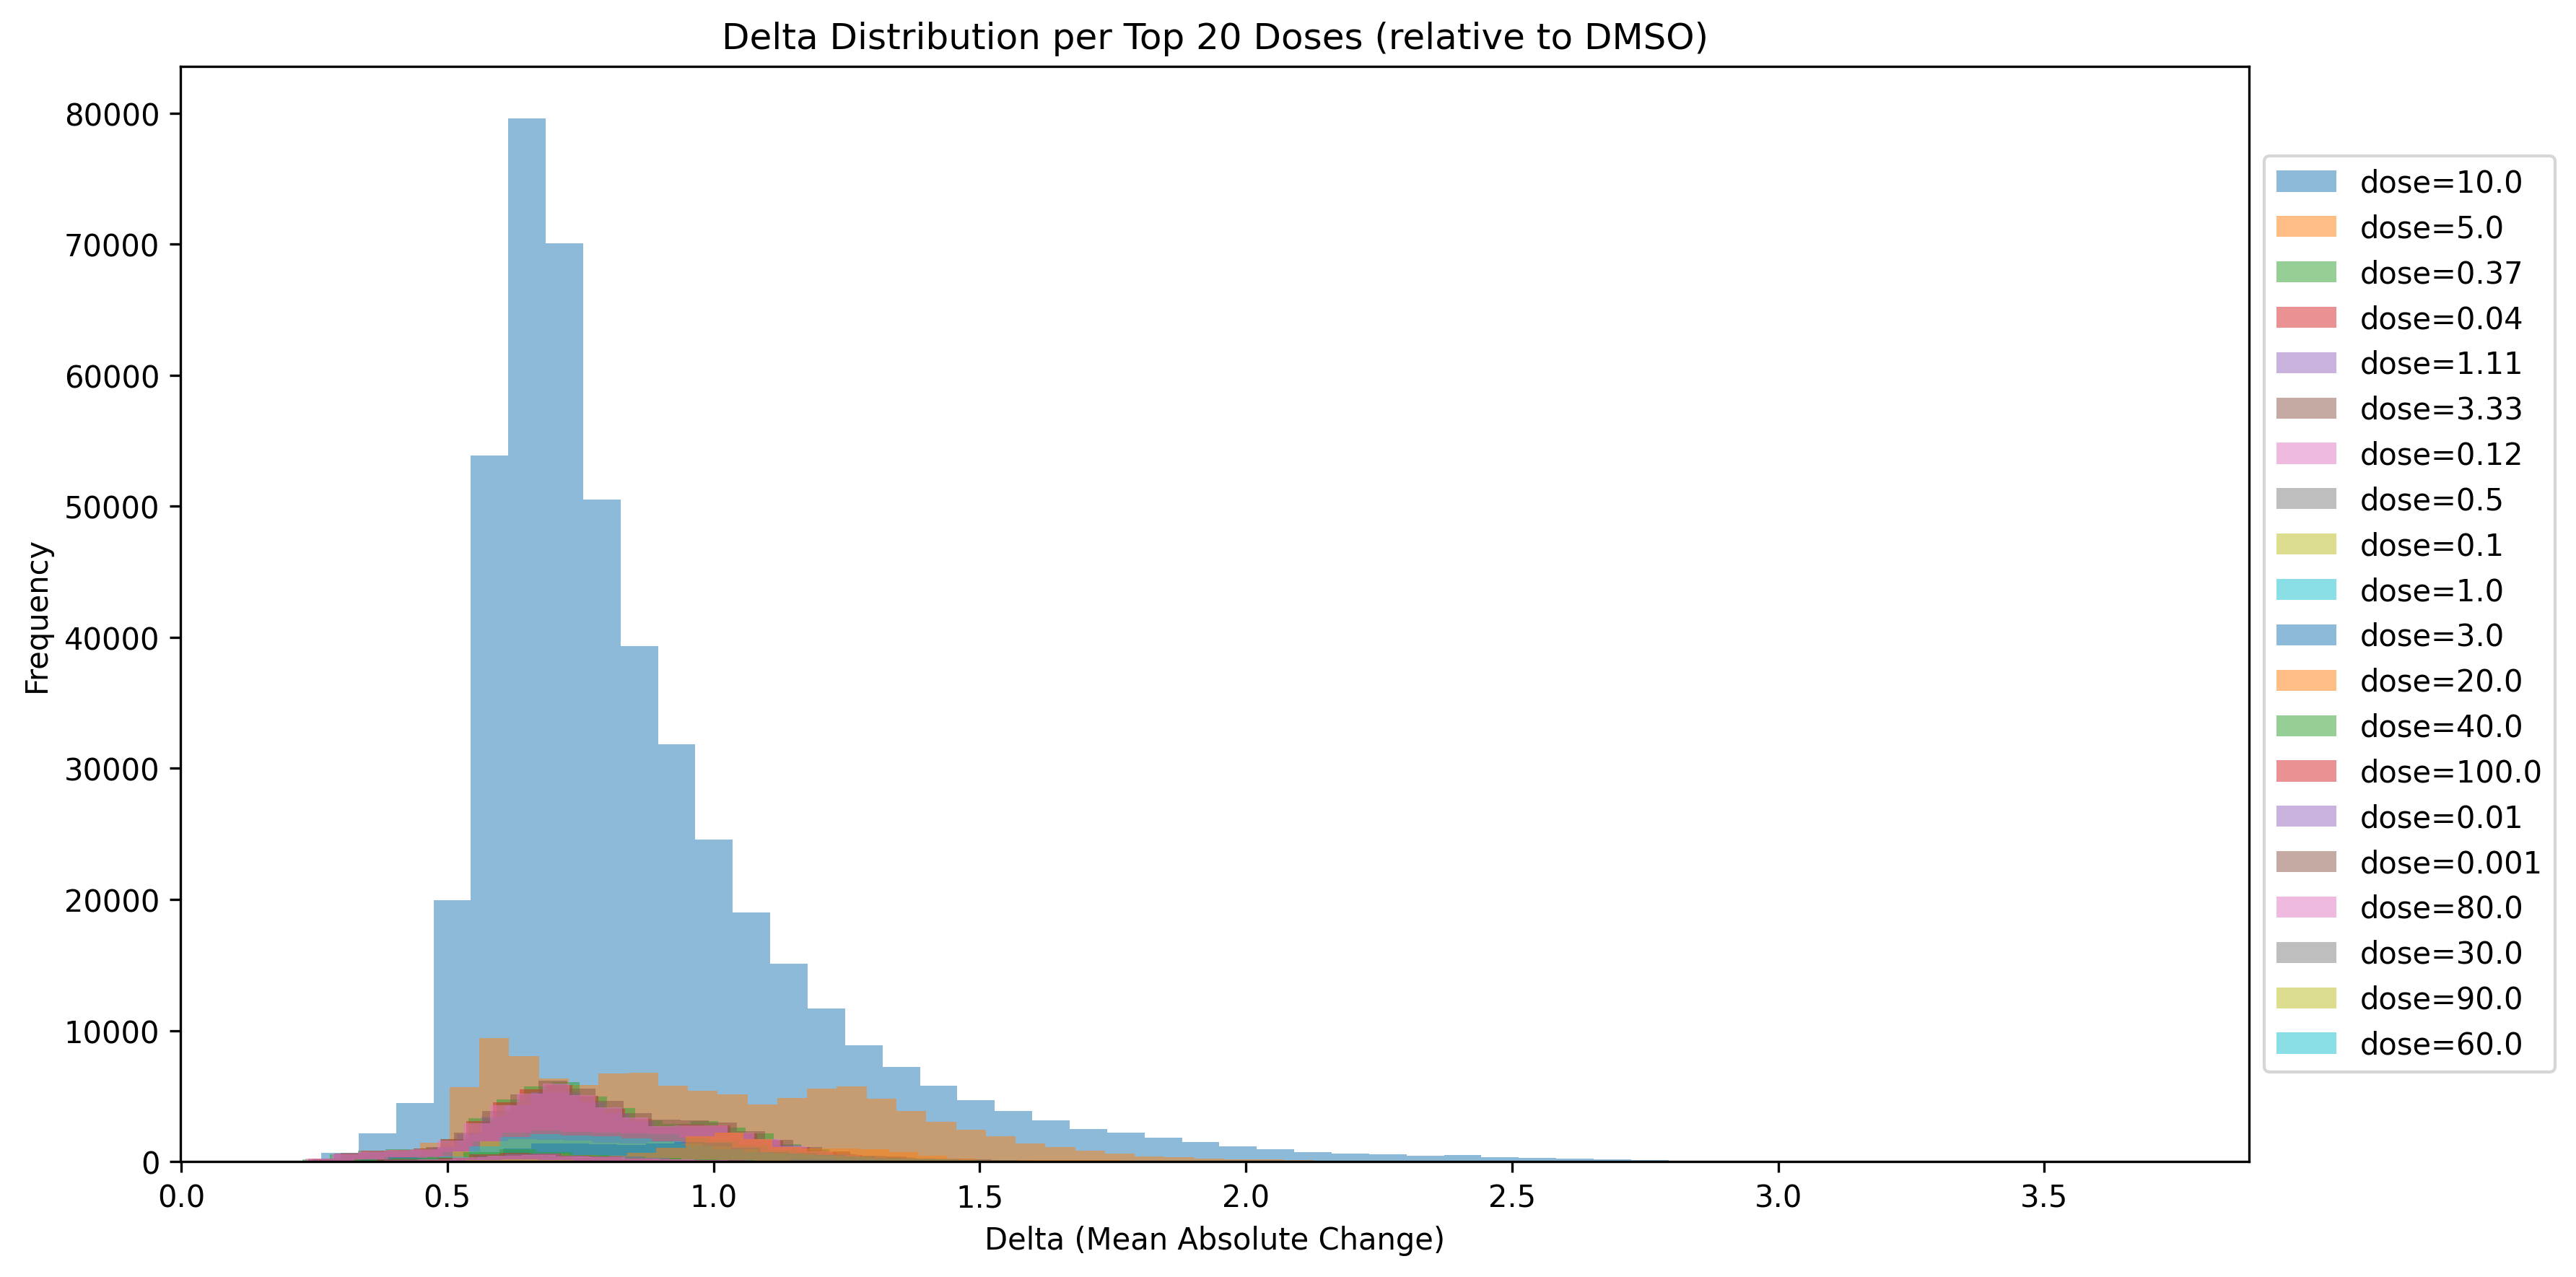

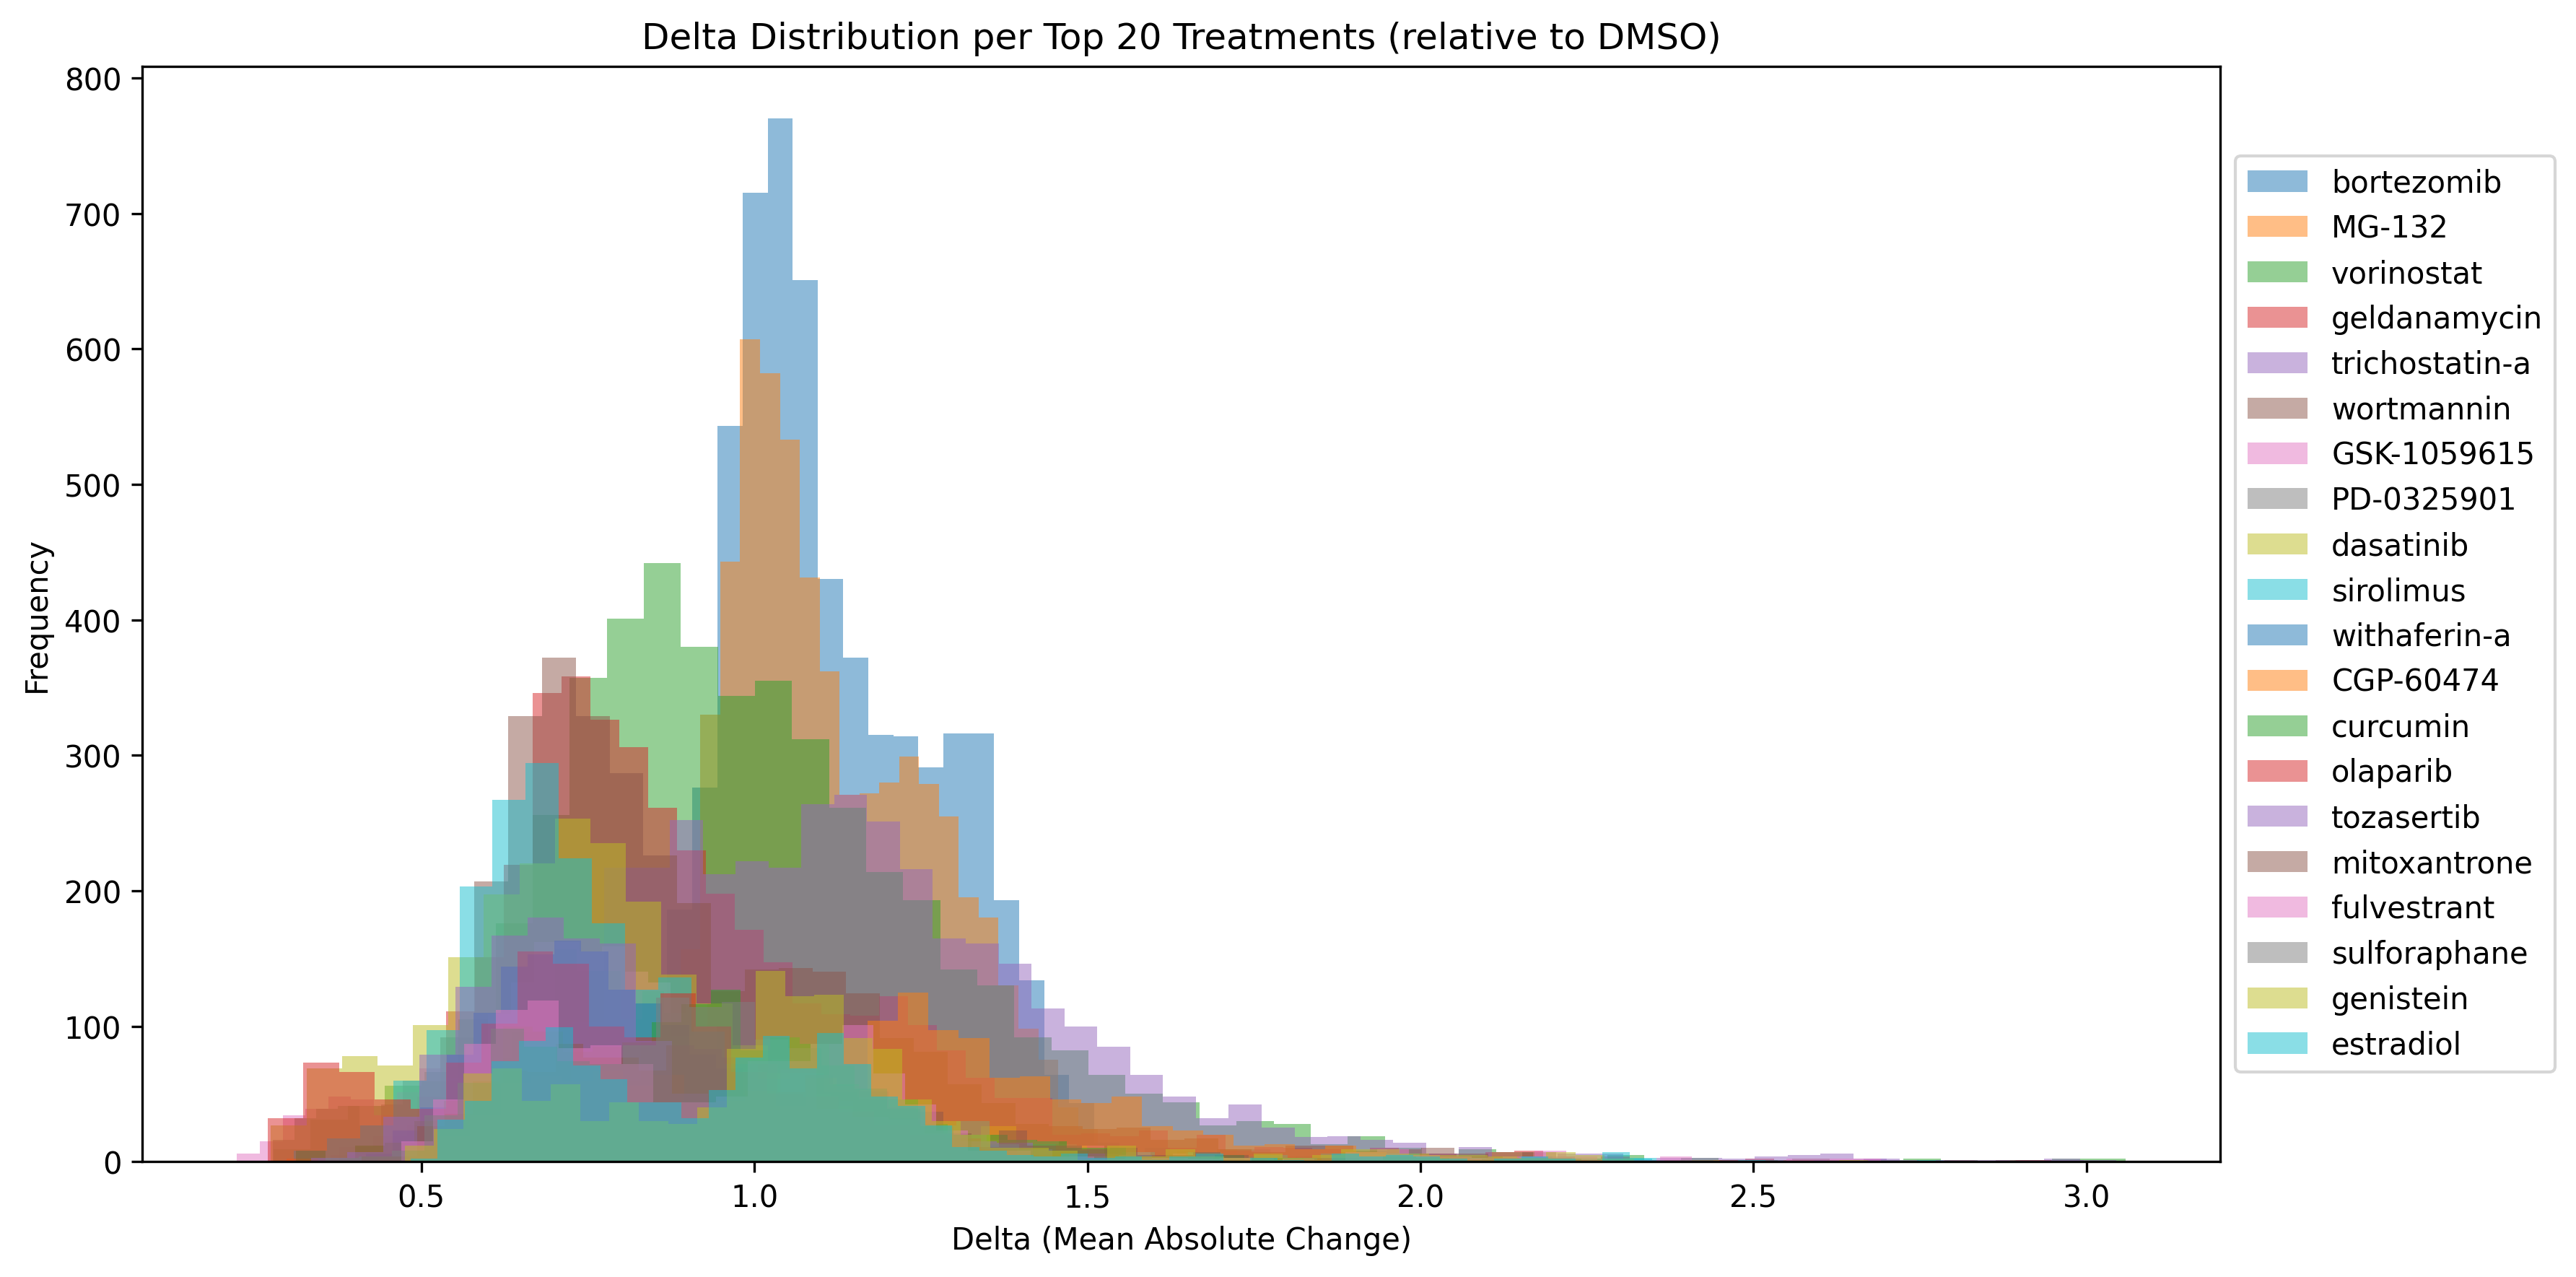

In [9]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset
# -----------------------------
adata = sc.read_h5ad("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/second_phase_combine/final_file_for_split_updated.h5ad")
df = adata.obs.copy()
df.loc[df['pert_dose'] < 0, 'pert_dose'] = 0

# -----------------------------
# Expression matrix
# -----------------------------
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
expr_df = pd.DataFrame(X)
df_full = pd.concat([df.reset_index(drop=True), expr_df], axis=1)
gene_cols = expr_df.columns

# -----------------------------
# Compute control means per cell (DMSO)
# -----------------------------
control_mask = df_full['pert_id'] == 'DMSO'
control_means = df_full[control_mask].groupby('cell_id')[gene_cols].mean()
control_dict = control_means.to_dict(orient='index')

# -----------------------------
# Compute delta per sample
# -----------------------------
control_matrix = np.array([
    list(control_dict[cell].values()) if cell in control_dict else np.zeros(len(gene_cols))
    for cell in df_full['cell_id']
])
expr_values = df_full[gene_cols].values.astype(float)
deltas = expr_values - control_matrix
df_full['delta'] = np.mean(np.abs(deltas), axis=1)
df_full.loc[df_full['pert_id'] == 'DMSO', 'delta'] = 0

# -----------------------------
# Filter only treatment samples
# -----------------------------
df_treatment = df_full[df_full['pert_type'] == 'trt_cp'].copy()

# -----------------------------
# Plot 1: Histogram by top 20 doses
# -----------------------------
plt.figure(figsize=(12,6), dpi=300)  # High resolution
top_doses = df_treatment['pert_dose'].value_counts().head(20).index
for dose in top_doses:
    subset = df_treatment[df_treatment['pert_dose'] == dose]
    plt.hist(subset['delta'], bins=50, alpha=0.5, label=f"dose={dose}")

plt.title("Delta Distribution per Top 20 Doses (relative to DMSO)")
plt.xlabel("Delta (Mean Absolute Change)")
plt.ylabel("Frequency")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: Histogram by top 20 treatments
# -----------------------------
plt.figure(figsize=(12,6), dpi=300)  # High resolution
top_drugs = df_treatment['pert_iname'].value_counts().head(20).index
for drug in top_drugs:
    subset = df_treatment[df_treatment['pert_iname'] == drug]
    plt.hist(subset['delta'], bins=50, alpha=0.5, label=drug)

plt.title("Delta Distribution per Top 20 Treatments (relative to DMSO)")
plt.xlabel("Delta (Mean Absolute Change)")
plt.ylabel("Frequency")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


final_split

In [1]:
# Step 1 — Load Dataset and Define Biological Context

import scanpy as sc
import pandas as pd

# Load dataset
adata = sc.read_h5ad("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/second_phase_combine/final_file_for_split_updated.h5ad")

# Work on obs dataframe
df = adata.obs.copy()
# Fix pert_dose for controls
# Replace -666 or any negative control values with 0
df.loc[df['pert_id'] == 'DMSO', 'pert_dose'] = 0

# Optional: Also ensure no negative doses for other compounds if needed
df.loc[df['pert_dose'] < 0, 'pert_dose'] = 0  # or handle as appropriate

# Define context_key
df["context_key"] = (
    df["cell_id"].astype(str) + "_" +
    df["mechanism_of_action_filtered"].astype(str) + "_" +
    df["pert_dose"].astype(str)
)

In [3]:
# Remove controls before context counting
non_controls = df[df["pert_id"] != "DMSO"]

# Count unique drugs per context
context_drug_counts = non_controls.groupby("context_key")["pert_id"].nunique()

# Orphan contexts
orphan_contexts = context_drug_counts[context_drug_counts == 1].index
orphans = non_controls[non_controls["context_key"].isin(orphan_contexts)]

# Shared contexts
shared_contexts = context_drug_counts[context_drug_counts >= 2].index
shared = non_controls[non_controls["context_key"].isin(shared_contexts)]

# Controls separately
controls = df[df["pert_id"] == "DMSO"]

In [4]:
# Step 2 — Check the groups

print("Total rows:", len(df))
print()

print("Controls (DMSO):", len(controls))
print("Unique control contexts:", controls["context_key"].nunique())
print()

print("Orphan rows:", len(orphans))
print("Orphan contexts:", len(orphan_contexts))
print()

print("Shared rows:", len(shared))
print("Shared contexts:", len(shared_contexts))
print()

# Sanity checks
print("Overlap orphan/shared:", set(orphan_contexts).intersection(set(shared_contexts)))
print("Controls inside shared:", controls["context_key"].isin(shared_contexts).sum())
print("Controls inside orphan:", controls["context_key"].isin(orphan_contexts).sum())

Total rows: 1038163

Controls (DMSO): 73261
Unique control contexts: 82

Orphan rows: 91971
Orphan contexts: 21991

Shared rows: 872931
Shared contexts: 7729

Overlap orphan/shared: set()
Controls inside shared: 0
Controls inside orphan: 0


In [5]:
controls["context_key"].drop_duplicates().sort_values()

0              A375_Unknown_0.0
234961         A549_Unknown_0.0
405321         A673_Unknown_0.0
406099          AGS_Unknown_0.0
249571        ASC.C_Unknown_0.0
                   ...         
1008769        U266_Unknown_0.0
509796         U937_Unknown_0.0
386085         VCAP_Unknown_0.0
522189     WSUDLCL2_Unknown_0.0
6696           YAPC_Unknown_0.0
Name: context_key, Length: 82, dtype: object

In [6]:
print("Total rows:", len(df))
print()

print("Controls:", len(controls))
print()

print("Orphan rows:", len(orphans))
print("Orphan contexts:", len(orphan_contexts))
print()

print("Shared rows:", len(shared))
print("Shared contexts:", len(shared_contexts))

Total rows: 1038163

Controls: 73261

Orphan rows: 91971
Orphan contexts: 21991

Shared rows: 872931
Shared contexts: 7729


In [7]:
# Step 3 — 5-fold split on shared contexts

from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

splits = []

for train_idx, test_idx in sgkf.split(
        shared,
        y=shared["context_key"],
        groups=shared["pert_id"]):

    shared_train = shared.iloc[train_idx]
    shared_test = shared.iloc[test_idx]

    splits.append((shared_train, shared_test))

/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/sklearn/model_selection/_split.py:1037: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


In [8]:
for i, (train, test) in enumerate(splits):

    train_drugs = set(train["pert_id"])
    test_drugs = set(test["pert_id"])

    overlap = train_drugs.intersection(test_drugs)

    print(f"Fold {i}")
    print("train rows:", len(train))
    print("test rows:", len(test))
    print("drug overlap:", len(overlap))
    print()

Fold 0
train rows: 698347
test rows: 174584
drug overlap: 0

Fold 1
train rows: 698344
test rows: 174587
drug overlap: 0

Fold 2
train rows: 698344
test rows: 174587
drug overlap: 0

Fold 3
train rows: 698346
test rows: 174585
drug overlap: 0

Fold 4
train rows: 698343
test rows: 174588
drug overlap: 0



In [9]:
# Step 4 — Combine shared folds with orphans + controls

fold_datasets = []

for shared_train, shared_test in splits:

    # Final train = shared_train + orphans + controls
    final_train = pd.concat([shared_train, orphans, controls])

    # Final test = shared_test only
    final_test = shared_test.copy()

    fold_datasets.append((final_train, final_test))

In [15]:
train_df, test_df = fold_datasets[0]

print("Fold 0 — final sizes")
print("TRAIN rows:", len(train_df))
print("TEST rows:", len(test_df))

# Verify only shared contexts in test
print("Unique contexts in test not in train:", set(test_df["context_key"]) - set(train_df["context_key"]))

# Verify no DMSO in test
print("DMSO in test:", (test_df["pert_id"] == "DMSO").sum())

Fold 0 — final sizes
TRAIN rows: 863579
TEST rows: 174584
Unique contexts in test not in train: set()
DMSO in test: 0


In [16]:
train_df, test_df = fold_datasets[1]

print("Fold 1 — final sizes")
print("TRAIN rows:", len(train_df))
print("TEST rows:", len(test_df))

# Verify only shared contexts in test
print("Unique contexts in test not in train:", set(test_df["context_key"]) - set(train_df["context_key"]))

# Verify no DMSO in test
print("DMSO in test:", (test_df["pert_id"] == "DMSO").sum())

Fold 1 — final sizes
TRAIN rows: 863576
TEST rows: 174587
Unique contexts in test not in train: set()
DMSO in test: 0


In [17]:
train_df, test_df = fold_datasets[2]

print("Fold 2 — final sizes")
print("TRAIN rows:", len(train_df))
print("TEST rows:", len(test_df))

# Verify only shared contexts in test
print("Unique contexts in test not in train:", set(test_df["context_key"]) - set(train_df["context_key"]))

# Verify no DMSO in test
print("DMSO in test:", (test_df["pert_id"] == "DMSO").sum())

Fold 2 — final sizes
TRAIN rows: 863576
TEST rows: 174587
Unique contexts in test not in train: set()
DMSO in test: 0


In [18]:
train_df, test_df = fold_datasets[3]

print("Fold 3 — final sizes")
print("TRAIN rows:", len(train_df))
print("TEST rows:", len(test_df))

# Verify only shared contexts in test
print("Unique contexts in test not in train:", set(test_df["context_key"]) - set(train_df["context_key"]))

# Verify no DMSO in test
print("DMSO in test:", (test_df["pert_id"] == "DMSO").sum())

Fold 3 — final sizes
TRAIN rows: 863578
TEST rows: 174585
Unique contexts in test not in train: set()
DMSO in test: 0


In [19]:
train_df, test_df = fold_datasets[4]

print("Fold 4 — final sizes")
print("TRAIN rows:", len(train_df))
print("TEST rows:", len(test_df))

# Verify only shared contexts in test
print("Unique contexts in test not in train:", set(test_df["context_key"]) - set(train_df["context_key"]))

# Verify no DMSO in test
print("DMSO in test:", (test_df["pert_id"] == "DMSO").sum())

Fold 4 — final sizes
TRAIN rows: 863575
TEST rows: 174588
Unique contexts in test not in train: set()
DMSO in test: 0


In [10]:
# Step 5 — Construct Final Train/Test Sets (strict drug-blind)
fold_datasets = []

for shared_train, shared_test in splits:

    # Exclude orphan rows whose drug is in the current test fold
    orphan_train = orphans[~orphans["pert_id"].isin(shared_test["pert_id"])]

    # Combine for final training set
    final_train = pd.concat([shared_train, orphan_train, controls])

    # Final test set = shared_test only
    final_test = shared_test.copy()

    fold_datasets.append((final_train, final_test))

In [11]:
# Count unique shared contexts in TEST for each fold
for i, (train_df, test_df) in enumerate(fold_datasets):
    shared_contexts_in_test = test_df["context_key"].nunique()
    print(f"Fold {i} — shared contexts in TEST:", shared_contexts_in_test)

Fold 0 — shared contexts in TEST: 5571
Fold 1 — shared contexts in TEST: 5355
Fold 2 — shared contexts in TEST: 4323
Fold 3 — shared contexts in TEST: 4385
Fold 4 — shared contexts in TEST: 4807


In [12]:
# Comprehensive context report for all folds
report = []

for i, (train_df, test_df) in enumerate(fold_datasets):
    
    # Unique contexts
    train_contexts = set(train_df["context_key"])
    test_contexts = set(test_df["context_key"])
    
    # Shared contexts
    shared_in_train = train_df[~train_df["context_key"].isin(orphans["context_key"]) & 
                                ~train_df["context_key"].isin(controls["context_key"])]["context_key"].nunique()
    shared_in_test = test_df["context_key"].nunique()
    
    # Orphan contexts in train and test
    orphan_in_train = train_df[train_df["context_key"].isin(orphans["context_key"])]["context_key"].nunique()
    orphan_in_test = test_df[test_df["context_key"].isin(orphans["context_key"])]["context_key"].nunique()
    
    # Control contexts in train and test
    controls_in_train = train_df[train_df["context_key"].isin(controls["context_key"])]["context_key"].nunique()
    controls_in_test = test_df[test_df["context_key"].isin(controls["context_key"])]["context_key"].nunique()
    
    report.append({
        "Fold": i,
        "TRAIN rows": len(train_df),
        "TEST rows": len(test_df),
        "Shared contexts in TRAIN": shared_in_train,
        "Shared contexts in TEST": shared_in_test,
        "Orphan contexts in TRAIN": orphan_in_train,
        "Orphan contexts in TEST": orphan_in_test,
        "Control contexts in TRAIN": controls_in_train,
        "Control contexts in TEST": controls_in_test
    })

# Convert to DataFrame for easy viewing
report_df = pd.DataFrame(report)
report_df

,Fold,TRAIN rows,TEST rows,Shared contexts in TRAIN,Shared contexts in TEST,Orphan contexts in TRAIN,Orphan contexts in TEST,Control contexts in TRAIN,Control contexts in TEST
0,0,859137,174584,7729,5571,20858,0,82,0
1,1,855600,174587,7729,5355,19976,0,82,0
2,2,858866,174587,7729,4323,20728,0,82,0
3,3,860348,174585,7729,4385,21032,0,82,0
4,4,860314,174588,7729,4807,21291,0,82,0


In [13]:
# Prepare context counts per fold
fold_context_counts = []

for i, (train_df, test_df) in enumerate(fold_datasets):
    train_context_count = train_df["context_key"].nunique()
    test_context_count  = test_df["context_key"].nunique()
    
    fold_context_counts.append({
        "Fold": i,
        "TRAIN context count": train_context_count,
        "TEST context count": test_context_count
    })

# Convert to DataFrame for easy viewing
import pandas as pd
context_counts_df = pd.DataFrame(fold_context_counts)
context_counts_df

,Fold,TRAIN context count,TEST context count
0,0,28669,5571
1,1,27787,5355
2,2,28539,4323
3,3,28843,4385
4,4,29102,4807


In [27]:
df.shape

(1038163, 20)

In [28]:
df.columns

Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id',
       'mechanism_of_action', 'action_type', 'action_type_filtered',
       'mechanism_of_action_filtered', 'context_key'],
      dtype='object')

In [30]:
adata.X

array([[ 9.3698  ,  4.418   ,  8.467   , ...,  8.0524  ,  8.2463  ,
         6.734   ],
       [ 6.868   ,  5.3619  ,  9.3663  , ...,  8.5473  ,  7.0152  ,
         6.763   ],
       [ 6.7837  ,  4.1719  ,  9.0224  , ...,  7.7894  ,  7.1739  ,
         6.7942  ],
       ...,
       [ 6.665575,  3.86815 ,  8.647975, ..., 10.52885 , 10.222   ,
         8.0548  ],
       [ 6.5495  ,  3.89505 ,  6.722375, ..., 10.7697  ,  9.76085 ,
         7.98275 ],
       [ 6.8681  ,  4.00525 ,  7.7192  , ..., 10.6273  ,  9.3875  ,
         9.209351]], shape=(1038163, 978), dtype=float32)

In [14]:
#Step 1 — Convert Your Split DataFrames Back to AnnData
fold_adatas = []

for train_df, test_df in fold_datasets:

    train_idx = adata.obs.index.isin(train_df.index)
    test_idx = adata.obs.index.isin(test_df.index)

    adata_train = adata[train_idx].copy()
    adata_test = adata[test_idx].copy()

    fold_adatas.append((adata_train, adata_test))

In [13]:
print(adata.obs.columns)

Index(['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type',
       'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles',
       'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id',
       'mechanism_of_action', 'action_type', 'action_type_filtered',
       'mechanism_of_action_filtered'],
      dtype='object')


In [15]:
#Step 2 — Run ComBat for Each Fold
import scanpy as sc

batch_key = "pert_itime"

corrected_folds = []

for i, (adata_train, adata_test) in enumerate(fold_adatas):

    print(f"Running ComBat for fold {i}")

    # Combine train and test for consistent correction
    combined = adata_train.concatenate(
        adata_test,
        batch_key="split",
        batch_categories=["train", "test"]
    )

    # Apply ComBat
    sc.pp.combat(
        combined,
        key=batch_key
    )

    # Split back
    train_corrected = combined[combined.obs["split"] == "train"].copy()
    test_corrected = combined[combined.obs["split"] == "test"].copy()

    corrected_folds.append((train_corrected, test_corrected))

Running ComBat for fold 0


/tmp/ipykernel_2623847/2974991303.py:13: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata_train.concatenate(


Running ComBat for fold 1


/tmp/ipykernel_2623847/2974991303.py:13: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata_train.concatenate(


Running ComBat for fold 2


/tmp/ipykernel_2623847/2974991303.py:13: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata_train.concatenate(


Running ComBat for fold 3


/tmp/ipykernel_2623847/2974991303.py:13: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata_train.concatenate(


Running ComBat for fold 4


/tmp/ipykernel_2623847/2974991303.py:13: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata_train.concatenate(


In [16]:
for i, (train, test) in enumerate(corrected_folds):

    train.write(f"fold_{i}_train_combat.h5ad")
    test.write(f"fold_{i}_test_combat.h5ad")

In [17]:
# Batch Effect Correction Using ComBat on Combined Dataset and Time (Cross-Validation Folds)
import scanpy as sc

corrected_folds = []

for i, (adata_train, adata_test) in enumerate(fold_adatas):

    print(f"Running ComBat for fold {i}")

    # Combine train + test
    combined = adata_train.concatenate(
        adata_test,
        batch_key="split",
        batch_categories=["train", "test"]
    )

    # -----------------------------
    # Create combined batch
    # -----------------------------
    combined.obs["combined_batch"] = (
        combined.obs["dataset_name"].astype(str) + "_" +
        combined.obs["pert_itime"].astype(str)
    )

    # Convert to category (important!)
    combined.obs["combined_batch"] = combined.obs["combined_batch"].astype('category')

    # -----------------------------
    # Apply ComBat
    # -----------------------------
    sc.pp.combat(
        combined,
        key="combined_batch"
    )

    # -----------------------------
    # Split back
    # -----------------------------
    train_corrected = combined[combined.obs["split"] == "train"].copy()
    test_corrected = combined[combined.obs["split"] == "test"].copy()

    corrected_folds.append((train_corrected, test_corrected))

Running ComBat for fold 0


/tmp/ipykernel_2623847/447478526.py:11: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata_train.concatenate(


Running ComBat for fold 1


/tmp/ipykernel_2623847/447478526.py:11: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata_train.concatenate(


Running ComBat for fold 2


/tmp/ipykernel_2623847/447478526.py:11: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata_train.concatenate(


Running ComBat for fold 3


/tmp/ipykernel_2623847/447478526.py:11: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata_train.concatenate(


Running ComBat for fold 4


/tmp/ipykernel_2623847/447478526.py:11: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata_train.concatenate(


In [18]:
for i, (train, test) in enumerate(corrected_folds):

    train.write(f"fold_{i}_train_combat_both.h5ad")
    test.write(f"fold_{i}_test_combat_both.h5ad")

In [1]:
import scanpy as sc

# Load your .h5ad dataset
adata = sc.read("/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/second_phase_combine/final_file_for_split_updated.h5ad")

# Display the basic information about the dataset
print(adata)

# Show the shape of the dataset (number of cells and genes)
print(f"Shape of the dataset: {adata.shape}")

# Check the names of available attributes in the data (e.g., raw data, metadata)
print("Available data attributes:")
print(adata.obs)  # Cell metadata
print(adata.var)  # Gene metadata
print(adata.X)    # Expression matrix

# Optionally, show the first few rows of cell metadata
print("First few rows of cell metadata:")
print(adata.obs.head())

AnnData object with n_obs × n_vars = 1038163 × 978
    obs: 'dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id', 'mechanism_of_action', 'action_type', 'action_type_filtered', 'mechanism_of_action_filtered'
Shape of the dataset: (1038163, 978)
Available data attributes:
        dataset_name                                       sig_id  \
0           GSE70138                        REP.A001_A375_24H:A03   
1           GSE70138                        REP.A001_A375_24H:A04   
2           GSE70138                        REP.A001_A375_24H:A05   
3           GSE70138                        REP.A001_A375_24H:A06   
4           GSE70138                        REP.A001_A375_24H:A07   
...              ...                                          ...   
1038158     GSE92742  PCLB003_PC3_24H:BRD-A75409952-001-01-6:3.33   
1038159     GSE92742  